In [1]:
# Notebook path bootstrap for moved files

import os
import sys

def find_project_root(start_dir):
    cur = os.path.abspath(start_dir)
    while True:
        if os.path.isdir(os.path.join(cur, 'figs-submit')):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            raise FileNotFoundError('Could not find project root containing figs-submit.')
        cur = parent

PROJECT_ROOT = find_project_root(os.getcwd())
os.chdir(PROJECT_ROOT)

FIGS_SUBMIT_DIR = os.path.join(PROJECT_ROOT, 'figs-submit')
UTILS_DIR = os.path.join(FIGS_SUBMIT_DIR, 'utils')

if FIGS_SUBMIT_DIR not in sys.path:
    sys.path.insert(0, FIGS_SUBMIT_DIR)

if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

print('PROJECT_ROOT =', PROJECT_ROOT)

# -*- coding: utf-8 -*-

"""
Auto-converted from resonance_2.ipynb.
Each code cell is preserved as a block for direct server-side execution and maintenance.
"""


PROJECT_ROOT = /home/yangqizhi/Projects/Rhythm


'\nAuto-converted from resonance_2.ipynb.\nEach code cell is preserved as a block for direct server-side execution and maintenance.\n'

In [2]:
# ========================================================================
# Part 1: 1) Data loading
# ========================================================================
import numpy as np
import json
import os
import sys
import pickle
import re

_THIS_FILE = globals().get("__file__")
if _THIS_FILE:
    _THIS_DIR = os.path.dirname(os.path.abspath(_THIS_FILE))
else:
    _THIS_DIR = os.getcwd()
_LOCAL_UTILS = os.path.join(_THIS_DIR, "utils")
if _LOCAL_UTILS not in sys.path:
    sys.path.insert(0, _LOCAL_UTILS)
 
# =========================
# 0) Model selection
# =========================

_model_ = "1000, yy"

_MODEL_DATA_ROOT = os.path.join(
    "models",
    "stim_6",
    "change_0_3-m_30_100_3",
)

_MODEL_CONFIGS = {
    "1000, yy": "models/resonance",
}

def _safe_model_tag(model_name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", model_name).strip("_")

def _resolve_model_activity_folder(model_name):
    try:
        model_root = _MODEL_CONFIGS[model_name]
        if model_name[:3] == "all":
            activity_folder = os.path.join(model_root, "activity_all_pairs")
        elif model_name[:4] == "1000":
            activity_folder = os.path.join(model_root, "activity_1000")
    except KeyError as exc:
        available_models = "\n  - ".join(sorted(_MODEL_CONFIGS))
        raise ValueError(
            f"Unknown model: {model_name!r}. Available models:\n  - {available_models}"
        ) from exc
    return activity_folder

_MODEL_TAG = _safe_model_tag(_model_)

POS_COLORS = ['#440154', '#414487', '#2a788e', '#22a884', '#7ad151', '#fde725']

def _pos_color(index, offset=0):
    color_index = int(index) + int(offset)
    color_index = max(0, min(color_index, len(POS_COLORS) - 1))
    return POS_COLORS[color_index]

def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.2f}"

def _normalized_regulariy_axis(n_bins):
    if n_bins <= 1:
        return np.array([0.0], dtype=float)
    return np.linspace(0.0, 1.0, n_bins, dtype=float)

def _enforce_line_axes_box_aspect(fig, width_mm=76.1, height_mm=61.5):
    """
    Enforce a fixed physical axis size (not figsize) on Cartesian axes that
    contain visible line artists.
    Target axis box size: width_mm x height_mm.
    """
    width_mm = float(width_mm)
    height_mm = float(height_mm)
    if width_mm <= 0 or height_mm <= 0:
        return

    target_w_in = width_mm / 25.4
    target_h_in = height_mm / 25.4

    line_axes = []
    for ax in fig.axes:
        if getattr(ax, "name", "") == "polar":
            continue
        if not hasattr(ax, "lines") or len(ax.lines) == 0:
            continue
        if not any(line.get_visible() for line in ax.lines):
            continue
        line_axes.append(ax)

    if len(line_axes) == 0:
        return

    # Make layout deterministic before overriding axes boxes.
    try:
        fig.canvas.draw()
    except Exception:
        pass

    boxes = [ax.get_position().frozen() for ax in line_axes]
    fig_w_in, fig_h_in = fig.get_size_inches()

    req_w_in = [target_w_in / max(b.width, 1e-6) for b in boxes]
    req_h_in = [target_h_in / max(b.height, 1e-6) for b in boxes]

    new_fig_w_in = max(fig_w_in, max(req_w_in))
    new_fig_h_in = max(fig_h_in, max(req_h_in))

    if (new_fig_w_in > fig_w_in) or (new_fig_h_in > fig_h_in):
        fig.set_size_inches(new_fig_w_in, new_fig_h_in, forward=True)

    # Disable automatic layout engine; we will place axis boxes manually.
    try:
        fig.set_layout_engine(None)
    except Exception:
        try:
            fig.set_constrained_layout(False)
        except Exception:
            pass

    fig_w_in, fig_h_in = fig.get_size_inches()
    w_frac = target_w_in / max(fig_w_in, 1e-9)
    h_frac = target_h_in / max(fig_h_in, 1e-9)

    for ax, b in zip(line_axes, boxes):
        cx = b.x0 + 0.5 * b.width
        cy = b.y0 + 0.5 * b.height

        x0 = cx - 0.5 * w_frac
        y0 = cy - 0.5 * h_frac

        # Keep axis fully inside figure canvas.
        x0 = min(max(0.0, x0), max(0.0, 1.0 - w_frac))
        y0 = min(max(0.0, y0), max(0.0, 1.0 - h_frac))

        ax.set_position([x0, y0, w_frac, h_frac])

# =========================
# 1) Data loading
# =========================
def get_keys_and_values_from_dict(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"JSON file not found: {file_path}")
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError("JSON root is not a dict.")
    return data

def load_original_data(model_name=_model_):
    data_parent_folder = _resolve_model_activity_folder(model_name)
    if model_name[:3] == "all":
        npz_paths = [
            os.path.join(data_parent_folder, 'activity_rhy_ch0_all_pairs.npz'),
            os.path.join(data_parent_folder, 'activity_rhy_ch3_all_pairs.npz'),
            os.path.join(data_parent_folder, 'activity_arrhy_ch0_all_pairs.npz'),
            os.path.join(data_parent_folder, 'activity_arrhy_ch3_all_pairs.npz'),
        ]
    elif model_name[:4] == "1000":
        npz_paths = [
            os.path.join(data_parent_folder, 'activity_rhy_ch0_all_seed42_trials1000.npz'),
            os.path.join(data_parent_folder, 'activity_rhy_ch3_all_seed42_trials1000.npz'),
            os.path.join(data_parent_folder, 'activity_arrhy_ch0_all_seed42_trials1000.npz'),
            os.path.join(data_parent_folder, 'activity_arrhy_ch3_all_seed42_trials1000.npz'),
        ]

    print(f"loading model: {model_name}")
    print(f"activity folder: {data_parent_folder}")

    from activity_loader import load_activity_data_everything, load_metadata_and_parameters

    activity, efficacy, (syn_x, syn_u, base_u), input_activity, y_activity, targets, sample_seq, test_seq, sample_onset_raw, test_onset_raw = load_activity_data_everything(npz_paths)

    data = activity
    print(f'after trans, per-condition data shapes: {[x.shape for x in data]}')

    if model_name[:3] == "all":
        metadata_json_path = os.path.join(data_parent_folder, 'metadata_all_pairs.json')
    elif model_name[:4] == "1000":
        metadata_json_path = os.path.join(data_parent_folder, 'metadata_all_seed42_n1000.json')

    task = [np.load(p, allow_pickle=True) for p in npz_paths]

    sample_onset = [np.asarray(so, dtype=int) + 50 for so in sample_onset_raw]
    phase_orig = {'Fixation': (0, 50), 'Sample': (50, 260), 'Delay': (260, 360), 'Test': (360, 570), 'Response': (570, 580)}

    return data, sample_onset, phase_orig, task

def load_acc_from_task(task):
    task_acc = [i['is_correct'] for i in task]
    acc4 = [np.asarray(a).astype(int).squeeze() for a in task_acc]
    if len(acc4) != 4:
        raise ValueError(f"Unexpected condition count in acc: {len(acc4)}, expected 4")
    return acc4

data4, onsets4, phase_orig, task = load_original_data(_model_)
acc4 = load_acc_from_task(task)

# Condition index convention: 0=rhy_ch0, 1=rhy_ch3, 2=arrhy_ch0, 3=arrhy_ch3
layers = {
    "change0": dict(rhy_i=0, arr_i=2),
    "change3": dict(rhy_i=1, arr_i=3),
}

print("model:", _model_)
print("data4 per-cond:", [x.shape for x in data4])
print("onsets4 per-cond:", [x.shape for x in onsets4])
print("acc4 per-cond:", [x.shape for x in acc4])
print("phase_orig:", phase_orig)


loading model: 1000, yy
activity folder: models/resonance/activity_1000


data loaded.
after trans, per-condition data shapes: [(1000, 100, 580), (1000, 100, 580), (1000, 100, 580), (1000, 100, 580)]
model: 1000, yy
data4 per-cond: [(1000, 100, 580), (1000, 100, 580), (1000, 100, 580), (1000, 100, 580)]
onsets4 per-cond: [(1000, 6), (1000, 6), (1000, 6), (1000, 6)]
acc4 per-cond: [(1000,), (1000,), (1000,), (1000,)]
phase_orig: {'Fixation': (0, 50), 'Sample': (50, 260), 'Delay': (260, 360), 'Test': (360, 570), 'Response': (570, 580)}


In [3]:
# ========================================================================
# Part 2: Figure 1 | Scheme A
# ========================================================================
# =========================================================
# Figure 1 | Scheme A
# Panel C only shows retained bands (e.g., 1f0 primary, 2f0 secondary)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy import signal, stats
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from sklearn.decomposition import PCA

# =========================================================
# 0) Plot style
# =========================================================
def set_nature_neuro_style():
    # plt.rcParams.update({
    #     "font.family": "sans-serif",
    #     "font.sans-serif": ["Arial", "DejaVu Sans"],
    #     "font.size": 10,
    #     "axes.linewidth": 0.8,
    #     "axes.labelsize": 11,
    #     "axes.titlesize": 12,
    #     "xtick.labelsize": 9,
    #     "ytick.labelsize": 9,
    #     "xtick.major.width": 0.8,
    #     "ytick.major.width": 0.8,
    #     "xtick.major.size": 3.5,
    #     "ytick.major.size": 3.5,
    #     "legend.frameon": False,
    #     "pdf.fonttype": 42,
    #     "ps.fonttype": 42,
    # })
    import matplotlib.pyplot as plt
    from figure.illustrator import initialize_matplotlib
    initialize_matplotlib()

# =========================================================
# 1) Basic utilities
# =========================================================
def get_phase_window(phase_orig, phase_name):
    """
    Return [start, end) indices for a given task phase.
    """
    if phase_name not in phase_orig:
        raise KeyError(f"{phase_name} not found in phase_orig. Available: {list(phase_orig.keys())}")
    s0, s1 = phase_orig[phase_name]
    return int(s0), int(s1)

def combine_trials_for_layer(data4, onsets4, cond_indices):
    """
    Merge two conditions belonging to the same layer.

    Parameters
    ----------
    data4 : list[np.ndarray]
        Length 4. Each item shape: (n_trial_i, n_hidden, n_time).
        Different conditions can have different n_trial_i.
    onsets4 : list[np.ndarray]
        Length 4. Each item shape: (n_trial_i, n_event).
        Different conditions can have different n_trial_i.
    cond_indices : list[int]

    Returns
    -------
    data_sel : np.ndarray
        Shape (n_trial_total, n_hidden, n_time)
    onsets_sel : np.ndarray
        Shape (n_trial_total, 6)
    cond_id : np.ndarray
        Shape (n_trial_total,)
    """
    data_sel = np.concatenate([data4[i] for i in cond_indices], axis=0)
    onsets_sel = np.concatenate([onsets4[i] for i in cond_indices], axis=0)
    cond_id = np.concatenate([np.full(data4[i].shape[0], i, dtype=int) for i in cond_indices], axis=0)
    return data_sel, onsets_sel, cond_id

def compute_trial_regularities(onsets_sel, atol=1e-12):
    """
    Compute IOI, mean IOI, CV_IOI, and R_raw = 1 - CV_IOI.
    """
    ioi = np.diff(onsets_sel, axis=1).astype(float)
    mean_ioi = ioi.mean(axis=1)
    std_ioi = ioi.std(axis=1, ddof=0)
    cv_ioi = std_ioi / np.maximum(mean_ioi, 1e-12)

    r_raw = 1.0 - cv_ioi
    r_raw[np.isclose(r_raw, 1.0, atol=atol)] = 1.0
    r_raw = np.clip(r_raw, 0.0, 1.0)

    return {
        "ioi": ioi,
        "mean_ioi": mean_ioi,
        "cv_ioi": cv_ioi,
        "r_raw": r_raw,
    }

def normalize_regularities(r_raw, perfect_value=1.0, atol=1e-12):
    """
    Normalize R:
    - non-perfect trials -> [0, 1)
    - perfect trials -> 1
    """
    r_raw = np.asarray(r_raw, dtype=float)
    is_perfect = np.isclose(r_raw, perfect_value, atol=atol)

    r_norm = np.zeros_like(r_raw, dtype=float)
    if np.any(~is_perfect):
        vals = r_raw[~is_perfect]
        vmin = vals.min()
        vmax = vals.max()
        if np.isclose(vmax, vmin):
            r_norm[~is_perfect] = 0.0
        else:
            r_norm[~is_perfect] = (vals - vmin) / (vmax - vmin)
            r_norm[~is_perfect] = np.clip(r_norm[~is_perfect], 0.0, 0.999999)
    r_norm[is_perfect] = 1.0
    return r_norm

def build_r_bins_quantile_nonperfect(r_norm, n_bins_nonperfect=7, perfect_value=1.0, atol=1e-12):
    """
    Build 8 bins:
    - 7 equal-count bins for R<1
    - 1 bin for R=1
    """
    r_norm = np.asarray(r_norm).astype(float)
    is_perfect = np.isclose(r_norm, perfect_value, atol=atol)
    r_nonperfect = r_norm[~is_perfect]

    if len(r_nonperfect) == 0:
        raise ValueError("All trials are R=1; cannot build non-perfect bins.")

    qs = np.linspace(0, 1, n_bins_nonperfect + 1)
    edges = np.quantile(r_nonperfect, qs)

    edges[0] = min(edges[0], r_nonperfect.min()) - 1e-12
    edges[-1] = max(edges[-1], r_nonperfect.max()) + 1e-12
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-12

    bin_index = np.full_like(r_norm, -1, dtype=int)
    bin_index[~is_perfect] = np.digitize(r_nonperfect, edges[1:-1], right=False)
    bin_index[is_perfect] = n_bins_nonperfect

    bin_medians = np.zeros(n_bins_nonperfect + 1, dtype=float)
    for b in range(n_bins_nonperfect):
        vals = r_norm[bin_index == b]
        bin_medians[b] = np.median(vals) if len(vals) > 0 else np.nan
    bin_medians[-1] = 1.0

    return bin_index, edges, bin_medians

def compute_reference_frequencies(mean_ioi_steps, fs, ref_multipliers=(0.5, 1.0, 2.0, 3.0)):
    """
    Compute f0 and reference frequencies.
    """
    f0_hz = fs / np.median(mean_ioi_steps)
    multipliers = np.asarray(ref_multipliers, dtype=float)
    ref_freqs_hz = multipliers * f0_hz
    ref_labels = [f"{m:g}f0" for m in multipliers]
    return {
        "f0_hz": float(f0_hz),
        "multipliers": multipliers,
        "ref_freqs_hz": ref_freqs_hz,
        "ref_labels": ref_labels,
    }

def build_relative_frequency_grid(f0_hz, m_min=0.35, m_max=3.8, n_freq=96):
    """
    Build relative frequency axis f/f0 and map it to absolute Hz.
    """
    freq_mults = np.linspace(m_min, m_max, n_freq)
    freqs_hz = freq_mults * f0_hz
    return {"freq_mults": freq_mults, "freqs_hz": freqs_hz}

# =========================================================
# 2) Stable PCA + composite signal
# =========================================================
def fit_pca_scores_auto_stable(
    data_sel,
    evr_threshold=0.90,
    max_fit_samples=50000,
    random_state=0,
    transform_chunk_size=100000,
    raw_clip_percentiles=(0.1, 99.9),
    z_clip=10.0,
    std_floor=1e-3
):
    """
    Robust PCA:
    1) nan_to_num
    2) raw clipping by percentiles
    3) z-score with std floor
    4) z clipping
    5) full SVD
    6) chunk transform
    """
    rng = np.random.default_rng(random_state)

    n_trial, n_hidden, n_time = data_sel.shape
    X = np.transpose(data_sel, (0, 2, 1)).reshape(-1, n_hidden).astype(np.float64, copy=False)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    n_samples = X.shape[0]
    if n_samples > max_fit_samples:
        fit_idx = rng.choice(n_samples, size=max_fit_samples, replace=False)
    else:
        fit_idx = np.arange(n_samples)

    X_fit_raw = X[fit_idx]

    q_low = np.percentile(X_fit_raw, raw_clip_percentiles[0], axis=0)
    q_high = np.percentile(X_fit_raw, raw_clip_percentiles[1], axis=0)
    X_fit_raw = np.clip(X_fit_raw, q_low, q_high)

    mean_ = X_fit_raw.mean(axis=0)
    std_ = X_fit_raw.std(axis=0, ddof=0)
    std_safe = np.maximum(std_, std_floor)

    X_fit = (X_fit_raw - mean_) / std_safe
    X_fit = np.clip(X_fit, -z_clip, z_clip)
    X_fit = np.nan_to_num(X_fit, nan=0.0, posinf=z_clip, neginf=-z_clip)

    n_fit_components = min(n_hidden, X_fit.shape[0], 256)
    pca_full = PCA(n_components=n_fit_components, svd_solver="full", random_state=random_state)
    pca_full.fit(X_fit)

    evr_all = np.nan_to_num(pca_full.explained_variance_ratio_, nan=0.0, posinf=0.0, neginf=0.0)
    cum_evr_all = np.cumsum(evr_all)
    n_pcs = int(np.searchsorted(cum_evr_all, evr_threshold) + 1)
    n_pcs = min(n_pcs, len(evr_all))

    components = np.nan_to_num(pca_full.components_[:n_pcs], nan=0.0, posinf=0.0, neginf=0.0)
    evr_selected = evr_all[:n_pcs]
    evr_selected = evr_selected / np.maximum(evr_selected.sum(), 1e-12)

    scores_flat = np.empty((n_samples, n_pcs), dtype=np.float64)
    for start in range(0, n_samples, transform_chunk_size):
        end = min(start + transform_chunk_size, n_samples)
        raw_chunk = np.clip(X[start:end], q_low, q_high)
        X_chunk = (raw_chunk - mean_) / std_safe
        X_chunk = np.clip(X_chunk, -z_clip, z_clip)
        X_chunk = np.nan_to_num(X_chunk, nan=0.0, posinf=z_clip, neginf=-z_clip)
        scores_flat[start:end] = np.dot(X_chunk, components.T)

    scores_flat = np.nan_to_num(scores_flat, nan=0.0, posinf=0.0, neginf=0.0)
    scores = scores_flat.reshape(n_trial, n_time, n_pcs).transpose(0, 2, 1)

    if not np.all(np.isfinite(scores)):
        raise FloatingPointError("Non-finite values detected in PCA scores.")

    return {
        "scores": scores,
        "evr_all": evr_all,
        "evr_selected": evr_selected,
        "cum_evr_all": cum_evr_all,
        "n_pcs": n_pcs,
        "mean_": mean_,
        "std_": std_,
        "q_low": q_low,
        "q_high": q_high,
    }

def compute_composite_neural_signal(pc_scores, pc_weights):
    """
    EVR-weighted composite signal.
    """
    w = np.asarray(pc_weights, dtype=np.float64)
    w = w / np.maximum(w.sum(), 1e-12)
    neural_comp = np.tensordot(w, pc_scores, axes=(0, 1))
    return np.nan_to_num(neural_comp, nan=0.0, posinf=0.0, neginf=0.0)

# =========================================================
# 3) Morlet spectrum
# =========================================================
def compute_morlet_power_batch(signals, fs, freqs_hz, n_cycles=None):
    """
    Morlet power for batch signals.
    """
    n_trial, n_time = signals.shape
    n_freq = len(freqs_hz)

    if n_cycles is None:
        n_cycles = np.linspace(2.0, 5.0, n_freq)
    else:
        n_cycles = np.asarray(n_cycles)
        if len(n_cycles) != n_freq:
            raise ValueError("n_cycles length must match freqs_hz.")

    power = np.zeros((n_trial, n_freq, n_time), dtype=np.float64)

    for fi, (f, cyc) in enumerate(zip(freqs_hz, n_cycles)):
        sigma_t = cyc / (2 * np.pi * f)
        half_width_sec = 4.0 * sigma_t
        half_width_samp = int(np.ceil(half_width_sec * fs))
        t = np.arange(-half_width_samp, half_width_samp + 1) / fs

        wavelet = np.exp(2j * np.pi * f * t) * np.exp(-(t ** 2) / (2 * sigma_t ** 2))
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))

        conv = signal.fftconvolve(signals, wavelet[None, :], mode="same")
        power[:, fi, :] = np.abs(conv) ** 2

    return np.nan_to_num(power, nan=0.0, posinf=0.0, neginf=0.0)

def compute_sample_mean_spectrum(power_tfr, sample_win):
    """
    Average power spectrum within Sample window.
    """
    s0, s1 = sample_win
    return np.mean(np.maximum(power_tfr[:, :, s0:s1], 1e-12), axis=-1)

# =========================================================
# 4) Detrended response
# =========================================================
def compute_detrended_response(sample_spec, freq_mults, sigma_mult=0.30, eps=1e-12):
    """
    T(f) = log S(f) - G(f)
    where G(f) is broad trend estimated by Gaussian smoothing.
    """
    log_spec = np.log(sample_spec + eps)
    log_spec = np.nan_to_num(log_spec, nan=0.0, posinf=12.0, neginf=-12.0)
    log_spec = np.clip(log_spec, -12.0, 12.0)

    delta_m = np.median(np.diff(freq_mults))
    sigma_pts = max(sigma_mult / max(delta_m, 1e-12), 1.0)

    trend = gaussian_filter1d(log_spec, sigma=sigma_pts, axis=1, mode="nearest")
    trend = np.nan_to_num(trend, nan=0.0, posinf=12.0, neginf=-12.0)

    tagged = log_spec - trend
    tagged = np.nan_to_num(tagged, nan=0.0, posinf=0.0, neginf=0.0)

    return log_spec, trend, tagged

# =========================================================
# 5) Statistics
# =========================================================
def _find_positive_clusters_1d(stat_vals, threshold):
    above = stat_vals > threshold
    clusters = []
    start = None
    for i, flag in enumerate(above):
        if flag and start is None:
            start = i
        elif (not flag) and (start is not None):
            end = i - 1
            mass = stat_vals[start:end + 1].sum()
            clusters.append({"start": start, "end": end, "mass": mass})
            start = None
    if start is not None:
        end = len(stat_vals) - 1
        mass = stat_vals[start:end + 1].sum()
        clusters.append({"start": start, "end": end, "mass": mass})
    return clusters

def one_sample_cluster_permutation(X, n_perm=1000, alpha=0.05, random_state=0):
    """
    Panel A:
    H0: mean(T(f)) <= 0
    """
    rng = np.random.default_rng(random_state)
    X = X[np.all(np.isfinite(X), axis=1)]
    n_trial, n_freq = X.shape

    mean_x = X.mean(axis=0)
    std_x = X.std(axis=0, ddof=1)
    t_obs = mean_x / (std_x / np.sqrt(n_trial) + 1e-12)

    threshold = stats.t.ppf(1 - alpha, df=n_trial - 1)
    obs_clusters = _find_positive_clusters_1d(t_obs, threshold)

    null_max_masses = np.zeros(n_perm)
    for p in range(n_perm):
        signs = rng.choice([-1, 1], size=(n_trial, 1))
        Xp = X * signs
        mean_p = Xp.mean(axis=0)
        std_p = Xp.std(axis=0, ddof=1)
        t_p = mean_p / (std_p / np.sqrt(n_trial) + 1e-12)

        clus = _find_positive_clusters_1d(t_p, threshold)
        null_max_masses[p] = np.max([c["mass"] for c in clus]) if len(clus) else 0.0

    sig_mask = np.zeros(n_freq, dtype=bool)
    clusters = []
    for c in obs_clusters:
        p_cluster = (1 + np.sum(null_max_masses >= c["mass"])) / (n_perm + 1)
        c2 = dict(c)
        c2["p_cluster"] = p_cluster
        clusters.append(c2)
        if p_cluster < alpha:
            sig_mask[c["start"]:c["end"] + 1] = True

    return {"t_obs": t_obs, "sig_mask": sig_mask, "clusters": clusters}

def compute_oneway_anova_stats(Y, groups):
    """
    Frequency-wise one-way ANOVA and omega-squared.
    """
    Y = np.asarray(Y, dtype=np.float64)
    groups = np.asarray(groups)
    uniq = np.unique(groups)

    n_trial, n_freq = Y.shape
    k = len(uniq)

    grand_mean = Y.mean(axis=0)
    ss_between = np.zeros(n_freq)
    ss_within = np.zeros(n_freq)

    for g in uniq:
        idx = np.where(groups == g)[0]
        Yg = Y[idx]
        ng = len(idx)
        mg = Yg.mean(axis=0)
        ss_between += ng * (mg - grand_mean) ** 2
        ss_within += np.sum((Yg - mg) ** 2, axis=0)

    dfb = k - 1
    dfw = n_trial - k
    msb = ss_between / max(dfb, 1)
    msw = ss_within / max(dfw, 1)
    F = msb / (msw + 1e-12)
    sst = ss_between + ss_within
    omega2 = (ss_between - dfb * msw) / (sst + msw + 1e-12)
    omega2 = np.clip(omega2, 0.0, 1.0)
    return F, omega2, dfb, dfw

def anova_cluster_permutation(Y, groups, n_perm=1000, alpha=0.05, random_state=0):
    """
    Panel B:
    permutation ANOVA across normalized R bins
    """
    rng = np.random.default_rng(random_state)
    valid = np.all(np.isfinite(Y), axis=1)
    Y = Y[valid]
    groups = groups[valid]

    F_obs, omega2, dfb, dfw = compute_oneway_anova_stats(Y, groups)
    threshold = stats.f.ppf(1 - alpha, dfn=dfb, dfd=dfw)
    obs_clusters = _find_positive_clusters_1d(F_obs, threshold)

    null_max_masses = np.zeros(n_perm)
    for p in range(n_perm):
        gp = rng.permutation(groups)
        Fp, _, _, _ = compute_oneway_anova_stats(Y, gp)
        clus = _find_positive_clusters_1d(Fp, threshold)
        null_max_masses[p] = np.max([c["mass"] for c in clus]) if len(clus) else 0.0

    sig_mask = np.zeros_like(F_obs, dtype=bool)
    clusters = []
    for c in obs_clusters:
        p_cluster = (1 + np.sum(null_max_masses >= c["mass"])) / (n_perm + 1)
        c2 = dict(c)
        c2["p_cluster"] = p_cluster
        clusters.append(c2)
        if p_cluster < alpha:
            sig_mask[c["start"]:c["end"] + 1] = True

    return {"F_obs": F_obs, "omega2": omega2, "sig_mask": sig_mask, "clusters": clusters}

def compute_bin_directional_rho(values_tf, bin_index, bin_medians):
    """
    Spearman rho between bin medians and bin-wise mean values at each frequency.
    This is used for interpretation, not significance thresholding.
    """
    n_bins = len(bin_medians)
    n_freq = values_tf.shape[1]
    heatmap = np.full((n_bins, n_freq), np.nan)

    for b in range(n_bins):
        idx = np.where(bin_index == b)[0]
        if len(idx) > 0:
            heatmap[b] = np.nanmean(values_tf[idx], axis=0)

    rho = np.full(n_freq, np.nan)
    for fi in range(n_freq):
        y = heatmap[:, fi]
        valid = np.isfinite(y) & np.isfinite(bin_medians)
        if np.sum(valid) >= 3:
            rho[fi] = stats.spearmanr(bin_medians[valid], y[valid]).correlation
    return rho, heatmap

# =========================================================
# 6) Peak-aware band summary
# =========================================================
def detect_local_anchor_peaks(x, y, anchors=(0.5, 1.0, 2.0, 3.0), peak_window=0.18, prominence=None):
    """
    Determine whether a local positive peak exists near each anchor.
    """
    yy = np.asarray(y, dtype=float)
    prom = max(np.nanstd(yy) * 0.10, 1e-6) if prominence is None else prominence
    peaks, _ = find_peaks(yy, prominence=prom)

    peak_mask = np.zeros_like(yy, dtype=bool)
    peak_mask[peaks] = True

    out = {}
    for a in anchors:
        near = np.abs(x - a) <= peak_window
        has_peak = bool(np.any(peak_mask[near] & (yy[near] > 0)))
        out[a] = has_peak
    return out

def summarize_reference_regions(
    x_analysis,
    stable_mask,
    sens_mask,
    tagged_mean,
    rho_dir,
    ref_multipliers=(0.5, 1.0, 2.0, 3.0),
    tol_mult=0.12,
    peak_window=0.18
):
    """
    Decision logic:
    - primary: overlap + local positive peak + rho >= 0
    - exploratory_overlap: overlap + local peak but rho < 0
    - secondary_stable_only: stable response only
    - drop: otherwise
    """
    overlap_mask = stable_mask & sens_mask
    local_peaks = detect_local_anchor_peaks(
        x_analysis, tagged_mean, anchors=ref_multipliers, peak_window=peak_window
    )

    rows = []
    for a in ref_multipliers:
        near = np.abs(x_analysis - a) <= tol_mult
        in_stable = bool(np.any(stable_mask[near]))
        in_sens = bool(np.any(sens_mask[near]))
        in_overlap = bool(np.any(overlap_mask[near]))
        has_peak = local_peaks[a]

        rho_a = np.nan
        if np.any(near):
            rho_a = np.nanmean(rho_dir[near])

        if in_overlap and has_peak and np.isfinite(rho_a) and rho_a >= 0:
            decision = "primary"
        elif in_overlap and has_peak:
            decision = "exploratory_overlap"
        elif in_stable:
            decision = "secondary_stable_only"
        else:
            decision = "drop"

        rows.append({
            "ref_multiplier": a,
            "stable_response": in_stable,
            "structure_sensitive": in_sens,
            "overlap": in_overlap,
            "local_peak": has_peak,
            "trend_rho": rho_a,
            "decision": decision,
        })

    return pd.DataFrame(rows), overlap_mask

def suggest_band_intervals(ref_summary, f0_hz, beta=0.20):
    """
    Convert retained anchors into band intervals.
    """
    rows = []
    for _, row in ref_summary.iterrows():
        if row["decision"] in ("primary", "exploratory_overlap", "secondary_stable_only"):
            fc = row["ref_multiplier"] * f0_hz
            rows.append({
                "band_label": f"{row['ref_multiplier']:g}f0",
                "decision": row["decision"],
                "center_hz": fc,
                "f_low_hz": (1 - beta) * fc,
                "f_high_hz": (1 + beta) * fc,
            })
    return pd.DataFrame(rows)

# =========================================================
# 7) Main analysis
# =========================================================
def analyze_figure1(
    data4,
    onsets4,
    phase_orig,
    cond_indices,
    fs=100.0,
    evr_threshold=0.90,
    max_fit_samples=50000,
    ref_multipliers=(0.5, 1.0, 2.0, 3.0),
    m_compute_min=0.35,
    m_compute_max=3.8,
    n_freq=96,
    m_analysis_min=0.5,
    m_analysis_max=3.6,
    sigma_mult=0.30,
    n_perm=1000,
    alpha=0.05,
    random_state=0,
):
    """
    Run Figure 1 analysis.

    Returns
    -------
    results : dict
        includes everything needed for QC, main figure, and band selection.
    """
    # 1) Merge trials
    data_sel, onsets_sel, cond_id = combine_trials_for_layer(data4, onsets4, cond_indices)

    # 2) R and f0
    reg = compute_trial_regularities(onsets_sel)
    r_raw = reg["r_raw"]
    r_norm = normalize_regularities(r_raw, perfect_value=1.0, atol=1e-12)
    mean_ioi_steps = reg["mean_ioi"]

    ref_info = compute_reference_frequencies(mean_ioi_steps, fs, ref_multipliers=ref_multipliers)
    f0_hz = ref_info["f0_hz"]

    # 3) Frequency grids
    grid = build_relative_frequency_grid(
        f0_hz=f0_hz,
        m_min=m_compute_min,
        m_max=m_compute_max,
        n_freq=n_freq
    )
    freq_mults_full = grid["freq_mults"]
    freqs_hz_full = grid["freqs_hz"]

    analysis_mask = (freq_mults_full >= m_analysis_min) & (freq_mults_full <= m_analysis_max)
    x = freq_mults_full[analysis_mask]
    freqs_hz = freqs_hz_full[analysis_mask]

    # 4) R bins
    r_bin_index, r_edges_nonperfect, bin_medians = build_r_bins_quantile_nonperfect(
        r_norm=r_norm,
        n_bins_nonperfect=7,
        perfect_value=1.0,
        atol=1e-12
    )

    # 5) PCA
    pca_out = fit_pca_scores_auto_stable(
        data_sel=data_sel,
        evr_threshold=evr_threshold,
        max_fit_samples=max_fit_samples,
        random_state=random_state,
        transform_chunk_size=100000,
        raw_clip_percentiles=(0.1, 99.9),
        z_clip=10.0,
        std_floor=1e-3
    )
    pc_scores = pca_out["scores"]
    pc_evr = pca_out["evr_selected"]

    neural_comp = compute_composite_neural_signal(pc_scores, pc_evr)

    # 6) Morlet power
    power_full = compute_morlet_power_batch(neural_comp, fs, freqs_hz_full, n_cycles=None)
    sample_win = get_phase_window(phase_orig, "Sample")
    sample_spec_full = compute_sample_mean_spectrum(power_full, sample_win)

    # 7) Detrended response
    log_spec_full, trend_full, tagged_full = compute_detrended_response(
        sample_spec_full, freq_mults_full, sigma_mult=sigma_mult, eps=1e-12
    )

    sample_spec = sample_spec_full[:, analysis_mask]
    log_spec = log_spec_full[:, analysis_mask]
    trend = trend_full[:, analysis_mask]
    tagged = tagged_full[:, analysis_mask]

    # 8) Panel A
    stable = one_sample_cluster_permutation(tagged, n_perm=n_perm, alpha=alpha, random_state=random_state)
    stable_sig_mask = stable["sig_mask"]

    XA = tagged[np.all(np.isfinite(tagged), axis=1)]
    nA = XA.shape[0]
    tagged_mean = np.nanmean(XA, axis=0)
    tagged_sem = stats.sem(XA, axis=0, nan_policy="omit")
    tcrit = stats.t.ppf(0.975, df=max(nA - 1, 1))
    tagged_ci_low = tagged_mean - tcrit * tagged_sem
    tagged_ci_high = tagged_mean + tcrit * tagged_sem

    # 9) Panel B
    sens = anova_cluster_permutation(tagged, r_bin_index, n_perm=n_perm, alpha=alpha, random_state=random_state)
    anova_F = sens["F_obs"]
    anova_omega2 = sens["omega2"]
    sensitivity_sig_mask = sens["sig_mask"]

    # 10) Directional rho + heatmap
    rho_dir, heatmap = compute_bin_directional_rho(tagged, r_bin_index, bin_medians)
    heatmap_counts = np.array([np.sum(r_bin_index == b) for b in range(len(bin_medians))])

    # 11) Band summary
    ref_summary, overlap_mask = summarize_reference_regions(
        x_analysis=x,
        stable_mask=stable_sig_mask,
        sens_mask=sensitivity_sig_mask,
        tagged_mean=tagged_mean,
        rho_dir=rho_dir,
        ref_multipliers=ref_multipliers,
        tol_mult=0.12,
        peak_window=0.18
    )
    band_suggestion = suggest_band_intervals(ref_summary, f0_hz=f0_hz, beta=0.20)

    results = {
        "sample_win": sample_win,
        "r_raw": r_raw,
        "r_norm": r_norm,
        "r_bin_index": r_bin_index,
        "bin_medians": bin_medians,
        "cond_id": cond_id,

        "f0_hz": f0_hz,
        "freq_mults_full": freq_mults_full,
        "freqs_hz_full": freqs_hz_full,
        "analysis_mask": analysis_mask,
        "freq_mults": x,
        "freqs_hz": freqs_hz,

        "sample_spec": sample_spec,
        "log_spec": log_spec,
        "trend": trend,
        "tagged_response": tagged,

        "tagged_mean": tagged_mean,
        "tagged_ci_low": tagged_ci_low,
        "tagged_ci_high": tagged_ci_high,

        "stable_t": stable["t_obs"],
        "stable_sig_mask": stable_sig_mask,
        "stable_clusters": stable["clusters"],

        "anova_F": anova_F,
        "anova_omega2": anova_omega2,
        "sensitivity_sig_mask": sensitivity_sig_mask,
        "sensitivity_clusters": sens["clusters"],

        "rho_dir": rho_dir,
        "heatmap": heatmap,
        "heatmap_counts": heatmap_counts,

        "overlap_mask": overlap_mask,
        "ref_summary": ref_summary,
        "band_suggestion": band_suggestion,

        "n_pcs": pca_out["n_pcs"],
        "evr_all": pca_out["evr_all"],
        "cum_evr_all": pca_out["cum_evr_all"],
        "pc_evr_selected": pc_evr,

        "power_shape_full": power_full.shape,
    }
    return results

# =========================================================
# 8) Plot helpers
# =========================================================
def _draw_sig_bar(ax, xvals, sig_mask, y, height, color):
    sig_mask = np.asarray(sig_mask).astype(bool)
    if not np.any(sig_mask):
        return

    start = None
    for i, flag in enumerate(sig_mask):
        if flag and start is None:
            start = i
        elif (not flag) and (start is not None):
            end = i - 1
            ax.add_patch(plt.Rectangle(
                (xvals[start], y),
                xvals[end] - xvals[start] + (xvals[1] - xvals[0]),
                height,
                facecolor=color,
                edgecolor="none",
                alpha=0.95
            ))
            start = None

    if start is not None:
        end = len(xvals) - 1
        ax.add_patch(plt.Rectangle(
            (xvals[start], y),
            xvals[end] - xvals[start] + (xvals[1] - xvals[0]),
            height,
            facecolor=color,
            edgecolor="none",
            alpha=0.95
        ))

# =========================================================
# 9) QC plot
# =========================================================
def plot_figure1_qc_spectra(results, layer_name="layer", figsize=(8.2, 4.2), save_pdf_path=None):
    """
    QC figure:
    - mean log spectrum vs trend
    - mean detrended response
    """
    set_nature_neuro_style()

    x = results["freq_mults"]
    log_spec = results["log_spec"]
    trend = results["trend"]
    tagged = results["tagged_response"]
    f0_hz = results["f0_hz"]

    mean_log_spec = np.nanmean(log_spec, axis=0)
    mean_trend = np.nanmean(trend, axis=0)
    mean_tagged = np.nanmean(tagged, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax1, ax2 = axes

    ax1.plot(x, mean_log_spec, lw=2.0, label="Mean log spectrum")
    ax1.plot(x, mean_trend, lw=2.0, ls="--", label="Broadband trend")
    for m in [0.5, 1.0, 2.0, 3.0]:
        if x.min() <= m <= x.max():
            ax1.axvline(m, color="0.75", lw=0.8, ls=":")
            ax1.text(m, ax1.get_ylim()[1], f"{m:g}f0", ha="center", va="bottom",
                     fontsize=8, color="0.35")
    ax1.set_xlim(x.min(), x.max())
    ax1.set_xlabel(r"Relative frequency ($f/f_0$)")
    ax1.set_ylabel("Log power")
    ax1.set_title("QC1 | Mean log spectrum vs trend", loc="left", fontweight="bold")
    ax1.legend(frameon=False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    ax2.plot(x, mean_tagged, lw=2.0)
    ax2.axhline(0, color="0.75", lw=0.8, ls="--")
    for m in [0.5, 1.0, 2.0, 3.0]:
        if x.min() <= m <= x.max():
            ax2.axvline(m, color="0.75", lw=0.8, ls=":")
            ax2.text(m, ax2.get_ylim()[1], f"{m:g}f0", ha="center", va="bottom",
                     fontsize=8, color="0.35")
    ax2.set_xlim(x.min(), x.max())
    ax2.set_xlabel(r"Relative frequency ($f/f_0$)")
    ax2.set_ylabel("Detrended log-power response (a.u.)")
    ax2.set_title("QC2 | Mean detrended response", loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    fig.suptitle(f"QC | Figure 1 spectra ({layer_name}, f0={f0_hz:.3f} Hz)",
                 y=1.03, fontsize=12, fontweight="bold")

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 10) Scheme A main plot
# =========================================================
def _select_panel_c_bands(results, panel_c_decisions=("primary", "secondary_stable_only"), max_bands=2):
    """
    Select retained bands to be shown in Panel C.
    Default:
    - primary
    - secondary_stable_only
    """
    band_df = results["band_suggestion"].copy()
    if band_df.empty:
        raise ValueError("band_suggestion is empty. No retained bands available for Panel C.")

    band_df = band_df[band_df["decision"].isin(panel_c_decisions)].copy()

    if band_df.empty:
        raise ValueError(
            f"No retained bands match panel_c_decisions={panel_c_decisions}. "
            f"Available decisions: {results['band_suggestion']['decision'].tolist()}"
        )

    priority_map = {
        "primary": 0,
        "exploratory_overlap": 1,
        "secondary_stable_only": 2,
    }
    band_df["priority"] = band_df["decision"].map(priority_map).fillna(99)
    band_df = band_df.sort_values(["priority", "center_hz"]).reset_index(drop=True)

    if len(band_df) > max_bands:
        band_df = band_df.iloc[:max_bands].copy()

    return band_df

def _extract_band_segment(results, band_row):
    """
    Extract x-range and heatmap segment for one retained band.
    """
    x = results["freq_mults"]
    heatmap = results["heatmap"]
    f0_hz = results["f0_hz"]

    m_low = band_row["f_low_hz"] / f0_hz
    m_high = band_row["f_high_hz"] / f0_hz

    mask = (x >= m_low) & (x <= m_high)
    if not np.any(mask):
        center = band_row["center_hz"] / f0_hz
        idx = np.argmin(np.abs(x - center))
        lo = max(idx - 2, 0)
        hi = min(idx + 3, len(x))
        mask = np.zeros_like(x, dtype=bool)
        mask[lo:hi] = True

    return {
        "x": x[mask],
        "heat": heatmap[:, mask],
        "mask": mask,
        "m_low": m_low,
        "m_high": m_high,
    }

def plot_figure1_schemeA(
    results,
    layer_name="layer",
    figsize=(12.0, 8.4),
    panel_c_decisions=("primary", "secondary_stable_only"),
    max_panel_c_bands=2,
    save_pdf_path=None
):
    """
    Scheme A:
    - Panel A: stable-response frequencies
    - Panel B: regularity-sensitive frequencies
    - Panel C: only retained bands (e.g., 1f0 primary, 2f0 secondary)

    Parameters
    ----------
    results : dict
        Output of analyze_figure1
    layer_name : str
    figsize : tuple
    panel_c_decisions : tuple[str]
        Which retained bands should be shown in Panel C
    max_panel_c_bands : int
        Max number of retained bands to show in Panel C
    save_pdf_path : str or None

    Returns
    -------
    fig : Figure
    axes : dict
    """
    set_nature_neuro_style()

    x = results["freq_mults"]
    tagged_mean = results["tagged_mean"]
    tagged_ci_low = results["tagged_ci_low"]
    tagged_ci_high = results["tagged_ci_high"]

    stable_mask = results["stable_sig_mask"]
    sens_mask = results["sensitivity_sig_mask"]
    overlap_mask = results["overlap_mask"]

    anova_omega2 = results["anova_omega2"]
    f0_hz = results["f0_hz"]

    heatmap_counts = results["heatmap_counts"]
    bin_medians = results["bin_medians"]

    ref_multipliers = results["ref_summary"]["ref_multiplier"].values

    panel_c_bands = _select_panel_c_bands(
        results,
        panel_c_decisions=panel_c_decisions,
        max_bands=max_panel_c_bands
    )

    band_segments = [_extract_band_segment(results, row) for _, row in panel_c_bands.iterrows()]

    # Shared color scale for Panel C bands
    all_vals = np.concatenate([seg["heat"].ravel() for seg in band_segments])
    vmax = np.nanpercentile(np.abs(all_vals), 98)
    vmax = max(vmax, 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Layout
    if len(band_segments) == 1:
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(
            2, 2,
            height_ratios=[1.0, 1.20],
            width_ratios=[1.0, 1.0],
            hspace=0.42, wspace=0.30
        )
        axA = fig.add_subplot(gs[0, 0])
        axB = fig.add_subplot(gs[0, 1])
        axC1 = fig.add_subplot(gs[1, :])
        c_axes = [axC1]
    else:
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(
            2, 2,
            height_ratios=[1.0, 1.20],
            width_ratios=[1.0, 1.0],
            hspace=0.42, wspace=0.32
        )
        axA = fig.add_subplot(gs[0, 0])
        axB = fig.add_subplot(gs[0, 1])
        axC1 = fig.add_subplot(gs[1, 0])
        axC2 = fig.add_subplot(gs[1, 1])
        c_axes = [axC1, axC2]

    # ---------------- Panel A ----------------
    axA.plot(x, tagged_mean, color="#1F4E79", lw=2.2)
    axA.fill_between(x, tagged_ci_low, tagged_ci_high, color="#1F4E79", alpha=0.18, lw=0)
    axA.axhline(0, color="0.75", lw=0.8, ls="--")

    y0, y1 = axA.get_ylim()
    bar_h = 0.05 * (y1 - y0) if y1 > y0 else 0.02
    _draw_sig_bar(axA, x, stable_mask, y=y0 + 0.02 * (y1 - y0), height=bar_h, color="#1F4E79")
    _draw_sig_bar(axA, x, overlap_mask, y=y0 + 0.10 * (y1 - y0), height=bar_h, color="#7A3E9D")

    for m in ref_multipliers:
        if x.min() <= m <= x.max():
            axA.axvline(m, color="0.75", lw=0.8, ls=":")
            axA.text(m, axA.get_ylim()[1], f"{m:g}f0", ha="center", va="bottom", fontsize=8, color="0.35")

    axA.set_xlim(x.min(), x.max())
    axA.set_xlabel(r"Relative frequency ($f/f_0$)")
    axA.set_ylabel("Detrended log-power response (a.u.)")
    axA.set_title("Fig3A  Frequencies showing stable responses during Sample",
                  loc="left", fontweight="bold")

    # ---------------- Panel B ----------------
    axB.plot(x, anova_omega2, color="#8B1E3F", lw=2.2)
    axB.axhline(0, color="0.75", lw=0.8, ls="--")

    y0, y1 = axB.get_ylim()
    bar_h = 0.05 * (y1 - y0) if y1 > y0 else 0.02
    _draw_sig_bar(axB, x, sens_mask, y=y0 + 0.02 * (y1 - y0), height=bar_h, color="#8B1E3F")
    _draw_sig_bar(axB, x, overlap_mask, y=y0 + 0.10 * (y1 - y0), height=bar_h, color="#7A3E9D")

    for m in ref_multipliers:
        if x.min() <= m <= x.max():
            axB.axvline(m, color="0.75", lw=0.8, ls=":")
            axB.text(m, axB.get_ylim()[1], f"{m:g}f0", ha="center", va="bottom", fontsize=8, color="0.35")

    axB.set_xlim(x.min(), x.max())
    axB.set_xlabel(r"Relative frequency ($f/f_0$)")
    axB.set_ylabel(r"Regularity effect size ($\omega^2$)")
    axB.set_title("Fig3B  Frequencies sensitive to temporal regularity",
                  loc="left", fontweight="bold")

    # ---------------- Panel C ----------------
    ims = []
    for i, (axC, seg, (_, band_row)) in enumerate(zip(c_axes, band_segments, panel_c_bands.iterrows()), start=1):
        im = axC.imshow(
            seg["heat"],
            aspect="auto",
            interpolation="nearest",
            cmap="RdBu_r",
            norm=norm,
            origin="lower",
            extent=[seg["x"].min(), seg["x"].max(), 0, seg["heat"].shape[0]]
        )
        ims.append(im)

        anchor_mult = band_row["center_hz"] / f0_hz
        if seg["x"].min() <= anchor_mult <= seg["x"].max():
            axC.axvline(anchor_mult, color="k", lw=0.8, ls=":", alpha=0.75)

        yticks = np.arange(len(bin_medians)) + 0.5
        yticklabels = [f"{med:.2f}\n(n={heatmap_counts[j]})" for j, med in enumerate(bin_medians)]
        axC.set_yticks(yticks)
        axC.set_yticklabels(yticklabels)

        axC.set_xlabel(r"Relative frequency ($f/f_0$)")
        axC.set_ylabel("Median normalized R")
        axC.set_xlim(seg["x"].min(), seg["x"].max())

        title_prefix = "C" if len(band_segments) == 1 else f"C{i}"
        axC.set_title(
            f"{title_prefix}  {band_row['band_label']} band "
            f"({band_row['f_low_hz']:.1f}–{band_row['f_high_hz']:.1f} Hz; {band_row['decision']})",
            loc="left",
            fontweight="bold"
        )

    cbar = fig.colorbar(ims[-1], ax=c_axes, fraction=0.025, pad=0.02)
    cbar.set_label("Mean detrended response (a.u.)", rotation=90)

    for ax in [axA, axB] + c_axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"Figure 1 | Stable frequency responses and temporal-structure sensitivity "
        f"during Sample ({layer_name}, f0={f0_hz:.3f} Hz)",
        y=0.985, fontsize=13, fontweight="bold"
    )

    axes = {"A": axA, "B": axB}
    if len(c_axes) == 1:
        axes["C"] = c_axes[0]
    else:
        axes["C1"] = c_axes[0]
        axes["C2"] = c_axes[1]

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes


Fig3AB


[cache] saved: cache/resonance/1000_yy/fig1_change0.pkl
Sample window: (50, 260)
f0_hz: 2.5
Selected n_pcs: 14
Morlet power full shape: (2000, 96, 580)

Reference summary:
   ref_multiplier  stable_response  structure_sensitive  overlap  local_peak  \
0             0.5            False                 True    False       False   
1             1.0             True                 True     True        True   
2             2.0             True                 True     True       False   
3             3.0            False                 True    False       False   

   trend_rho               decision  
0  -1.000000                   drop  
1   1.000000                primary  
2  -0.972222  secondary_stable_only  
3   0.397959                   drop  

Suggested bands for Figure 2:
  band_label               decision  center_hz  f_low_hz  f_high_hz
0        1f0                primary        2.5       2.0        3.0
1        2f0  secondary_stable_only        5.0       4.0        6.0


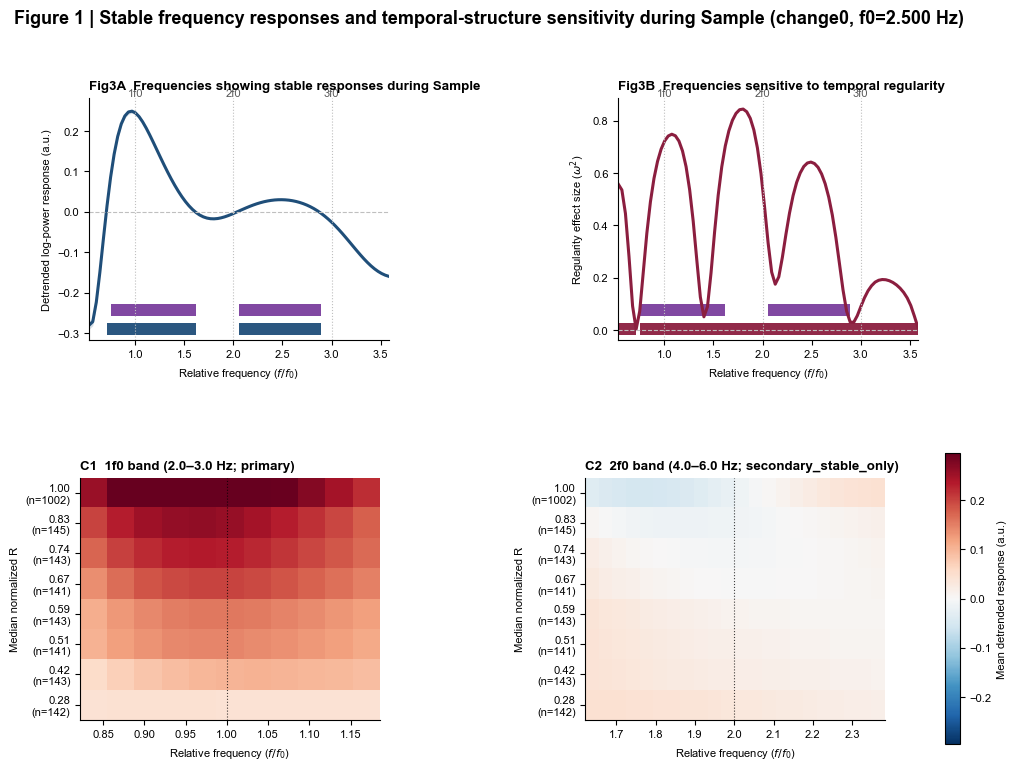

In [4]:
# ========================================================================
# Part 3: QC
# ========================================================================
CACHE_OUT_DIR = os.path.join("cache", "resonance", _MODEL_TAG)
FIG_OUT_DIR = os.path.join("figs", "resonance", _MODEL_TAG)
os.makedirs(CACHE_OUT_DIR, exist_ok=True)
os.makedirs(FIG_OUT_DIR, exist_ok=True)

def save_intermediate_pickle(obj, filename):
    out_path = os.path.join(CACHE_OUT_DIR, filename)
    with open(out_path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[cache] saved: {out_path}")

fig1_change0 = analyze_figure1(
    data4=data4,
    onsets4=onsets4,
    phase_orig=phase_orig,
    cond_indices=[layers["change0"]["rhy_i"], layers["change0"]["arr_i"]],
    fs=100.0,
    evr_threshold=0.90,
    max_fit_samples=50000,
    ref_multipliers=(0.5, 1.0, 2.0, 3.0),
    m_compute_min=0.35,
    m_compute_max=3.8,
    n_freq=96,
    m_analysis_min=0.5,
    m_analysis_max=3.6,
    sigma_mult=0.30,
    n_perm=1000,
    alpha=0.05,
    random_state=42,
)
save_intermediate_pickle(fig1_change0, "fig1_change0.pkl")

print("Sample window:", fig1_change0["sample_win"])
print("f0_hz:", fig1_change0["f0_hz"])
print("Selected n_pcs:", fig1_change0["n_pcs"])
print("Morlet power full shape:", fig1_change0["power_shape_full"])
print("\nReference summary:")
print(fig1_change0["ref_summary"])
print("\nSuggested bands for Figure 2:")
print(fig1_change0["band_suggestion"])

# Scheme A main figure
fig, axes = plot_figure1_schemeA(
    fig1_change0,
    layer_name="change0",
    panel_c_decisions=("primary", "secondary_stable_only"),   # Main text can display 1f0 + 2f0
    max_panel_c_bands=2,
    save_pdf_path=os.path.join(FIG_OUT_DIR, "Fig3ABC.pdf")
)


Fig3CD



[Phase-binning diagnostics]

Candidate bin width = 2 deg
  Onset 1 | occupied=  1, count[min/med/max]=1654/1654.0/1654
  Onset 2 | occupied= 70, count[min/med/max]=1/8.0/328
  Onset 3 | occupied=111, count[min/med/max]=1/5.0/121
  Onset 4 | occupied=111, count[min/med/max]=1/6.0/123
  Onset 5 | occupied=122, count[min/med/max]=1/6.0/122
  Onset 6 | occupied=102, count[min/med/max]=1/10.0/94

Candidate bin width = 5 deg
  Onset 1 | occupied=  1, count[min/med/max]=1654/1654.0/1654
  Onset 2 | occupied= 35, count[min/med/max]=2/17.0/371
  Onset 3 | occupied= 51, count[min/med/max]=1/9.0/199
  Onset 4 | occupied= 50, count[min/med/max]=1/12.0/209
  Onset 5 | occupied= 52, count[min/med/max]=1/12.5/221


  Onset 6 | occupied= 44, count[min/med/max]=1/22.0/201

Candidate bin width = 10 deg
  Onset 1 | occupied=  1, count[min/med/max]=1654/1654.0/1654
  Onset 2 | occupied= 18, count[min/med/max]=7/37.5/566
  Onset 3 | occupied= 27, count[min/med/max]=1/15.0/364
  Onset 4 | occupied= 27, count[min/med/max]=1/15.0/410
  Onset 5 | occupied= 27, count[min/med/max]=4/21.0/351
  Onset 6 | occupied= 22, count[min/med/max]=2/48.5/343

Candidate bin width = 15 deg
  Onset 1 | occupied=  1, count[min/med/max]=1654/1654.0/1654
  Onset 2 | occupied= 12, count[min/med/max]=17/57.0/413
  Onset 3 | occupied= 19, count[min/med/max]=1/21.0/492
  Onset 4 | occupied= 19, count[min/med/max]=1/21.0/505
  Onset 5 | occupied= 19, count[min/med/max]=4/31.0/545
  Onset 6 | occupied= 15, count[min/med/max]=2/59.0/381


[cache] saved: cache/resonance/1000_yy/step45_change0.pkl


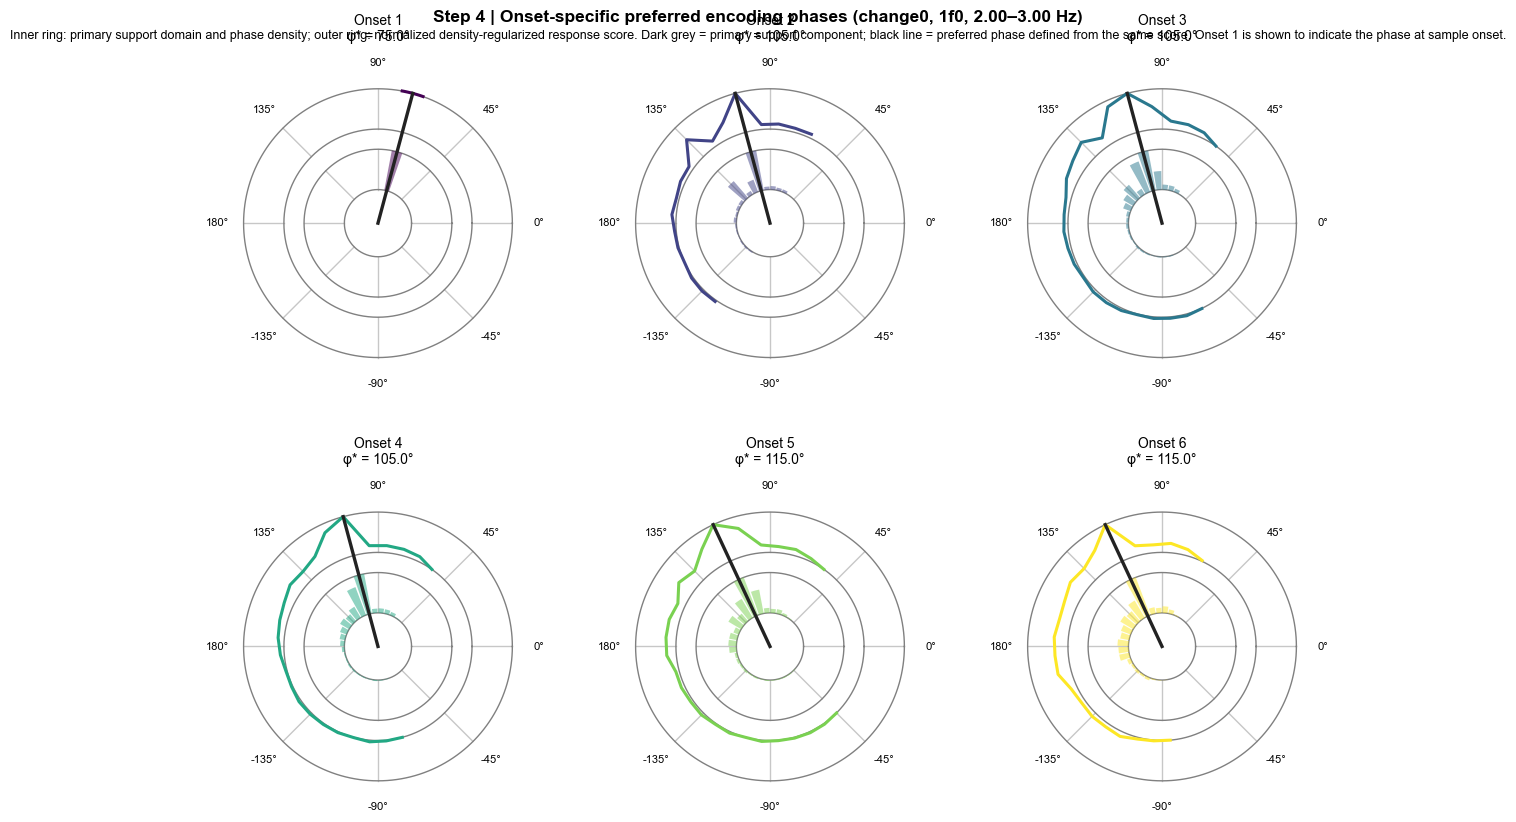

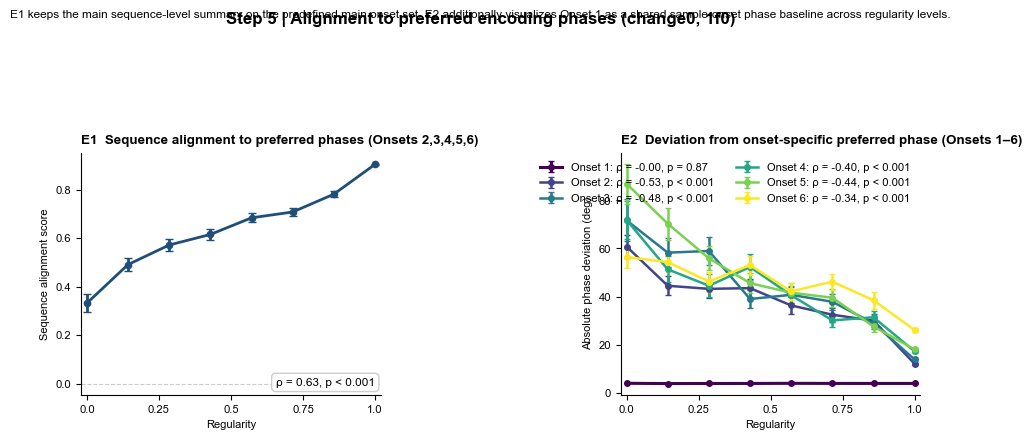

In [5]:
# ========================================================================
# Part 4: 0) Basic helpers
# ========================================================================
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats

# =========================================================
# 0) Basic helpers
# =========================================================
def _maybe_set_nature_neuro_style():
    fn = globals().get("set_nature_neuro_style", None)
    if callable(fn):
        fn()
    else:
        plt.rcParams.update({
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 1.0,
            "xtick.major.width": 1.0,
            "ytick.major.width": 1.0,
        })

def _bh_fdr(pvals):
    """NaN-safe Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return out

    pv = pvals[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    qvals_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev

    qvals = np.empty(n, dtype=float)
    qvals[order] = np.clip(qvals_ranked, 0.0, 1.0)
    out[valid] = qvals
    return out

def _wrap_phase_deg(x_deg):
    x_deg = np.asarray(x_deg, dtype=float)
    return ((x_deg + 180.0) % 360.0) - 180.0

def _circ_diff_rad(a, b):
    return np.angle(np.exp(1j * (a - b)))

def _safe_row_nanmean(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape[0], np.nan, dtype=float)
    valid_counts = np.sum(np.isfinite(x), axis=1)
    has_valid = valid_counts > 0
    if np.any(has_valid):
        out[has_valid] = np.nanmean(x[has_valid], axis=1)
    return out

def _get_metric_label(metric_mode):
    label_map = {
        "mean_abs_hidden": "Mean |hidden activity|",
        "mean_hidden": "Mean hidden activity",
        "l2_norm": "Mean hidden-state L2 norm",
        "mean_exc_abs_hidden": "Mean |excitatory hidden activity|",
    }
    return label_map.get(metric_mode, metric_mode)

def _format_scalar_or_nan(x, int_mode=False):
    if x is None or not np.isfinite(x):
        return "nan"
    if int_mode:
        return str(int(round(float(x))))
    return f"{float(x):.3f}"

def _parse_band_multiplier(band_label):
    if band_label == "f0":
        return 1.0
    if not isinstance(band_label, str) or not band_label.endswith("f0"):
        raise ValueError("band_label should look like 'f0', '1f0', '0.5f0', '2f0', ...")

    prefix = band_label[:-2]
    if prefix == "":
        return 1.0
    try:
        return float(prefix)
    except ValueError as e:
        raise ValueError(f"Cannot parse band_label={band_label!r}") from e

def _resolve_band_from_fig1(fig1_results, band_label="1f0", fallback_beta=0.20):
    """
    Resolve the analysis band from fig1 results if available;
    otherwise fall back to a theoretical anchor.
    """
    if not isinstance(fig1_results, dict):
        raise TypeError("fig1_results must be a dict-like object")

    band_df = fig1_results.get("band_suggestion", None)
    if band_df is not None and len(band_df) > 0:
        required_cols = {"band_label", "center_hz", "f_low_hz", "f_high_hz"}
        if required_cols.issubset(set(band_df.columns)):
            hit = band_df[band_df["band_label"] == band_label]
            if len(hit) > 0:
                row = hit.iloc[0]
                return {
                    "band_label": str(row["band_label"]),
                    "center_hz": float(row["center_hz"]),
                    "f_low_hz": float(row["f_low_hz"]),
                    "f_high_hz": float(row["f_high_hz"]),
                    "decision": row["decision"] if "decision" in row.index else "fig1_band_suggestion",
                    "source": "fig1_band_suggestion",
                }

    if "f0_hz" not in fig1_results:
        raise KeyError(
            "fig1_results must contain either a valid 'band_suggestion' table "
            "or a scalar key 'f0_hz'"
        )

    f0_hz = float(fig1_results["f0_hz"])
    mult = _parse_band_multiplier(band_label)
    center_hz = mult * f0_hz

    return {
        "band_label": band_label,
        "center_hz": center_hz,
        "f_low_hz": (1 - fallback_beta) * center_hz,
        "f_high_hz": (1 + fallback_beta) * center_hz,
        "decision": "theoretical_fallback",
        "source": "theoretical_anchor",
    }

# =========================================================
# 1) Causal phase / amplitude estimator
# =========================================================
def _causal_complex_phase_amp(
    signals,
    fs,
    f_low_hz,
    f_high_hz,
    n_sigma=4.0,
    max_support_sec=0.45,
    pad_mode="edge",
):
    """
    Causal complex phase/amplitude estimator with capped support and pre-padding.
    """
    signals = np.asarray(signals, dtype=float)
    if signals.ndim != 2:
        raise ValueError("signals must have shape (n_trial, n_time)")

    f_c = 0.5 * (f_low_hz + f_high_hz)
    bw = max(float(f_high_hz - f_low_hz), 1e-3)

    sigma_f = bw / 2.355
    sigma_t = 1.0 / (2.0 * np.pi * sigma_f)

    raw_kernel_len = max(3, int(np.ceil(n_sigma * sigma_t * fs)))
    max_support_steps = max(3, int(np.round(max_support_sec * fs)))
    kernel_len = min(raw_kernel_len, max_support_steps)

    lags = np.arange(kernel_len, dtype=float) / fs
    kernel = np.exp(-(lags ** 2) / (2.0 * sigma_t ** 2)) * np.exp(-2j * np.pi * f_c * lags)
    kernel = kernel / np.sqrt(np.sum(np.abs(kernel) ** 2))

    pad_len = kernel_len
    if pad_mode == "edge":
        pad = np.repeat(signals[:, :1], pad_len, axis=1)
    elif pad_mode == "zero":
        pad = np.zeros((signals.shape[0], pad_len), dtype=float)
    else:
        raise ValueError(f"Unknown pad_mode: {pad_mode}")

    padded = np.concatenate([pad, signals], axis=1)
    z_pad = signal.lfilter(kernel, [1.0], padded, axis=-1)
    z = z_pad[:, pad_len: pad_len + signals.shape[1]]

    phase = np.angle(z)
    amp = np.abs(z)

    return {
        "complex": z,
        "phase": phase,
        "amp": amp,
        "kernel_len": kernel_len,
        "raw_kernel_len": raw_kernel_len,
        "center_hz": f_c,
        "sigma_t": sigma_t,
        "max_support_sec": max_support_sec,
    }

def _extract_onset_values(arr, onsets_sel, offset_steps=0):
    """
    Extract trial-by-onset values from a (trial, time) array.
    """
    arr = np.asarray(arr)
    n_trial, n_time = arr.shape
    n_event = onsets_sel.shape[1]
    out = np.full((n_trial, n_event), np.nan, dtype=float)

    for tr in range(n_trial):
        for j in range(n_event):
            t = int(onsets_sel[tr, j]) + int(offset_steps)
            if 0 <= t < n_time:
                out[tr, j] = arr[tr, t]
    return out

def _build_amp_gate_mask(onset_amp, amp_quantile=0.25, min_valid=20):
    """
    Per-onset amplitude gate.
    """
    onset_amp = np.asarray(onset_amp, dtype=float)
    n_trial, n_event = onset_amp.shape
    gate = np.zeros((n_trial, n_event), dtype=bool)

    for j in range(n_event):
        valid = np.isfinite(onset_amp[:, j])
        if np.sum(valid) < min_valid:
            gate[:, j] = valid
            continue
        thr = np.nanquantile(onset_amp[valid, j], amp_quantile)
        gate[:, j] = valid & (onset_amp[:, j] >= thr)
    return gate

# =========================================================
# 2) Response metric
# =========================================================
def _compute_stimulus_window_metric(
    data_sel,
    onsets_sel,
    metric_window_steps=10,
    metric_offset_steps=0,
    metric_mode="mean_abs_hidden",
    exc_slice=None,
):
    """
    Compute trial-by-onset local encoding metric from a post-onset response window.
    """
    n_trial, n_hidden, n_time = data_sel.shape
    n_event = onsets_sel.shape[1]
    metric = np.full((n_trial, n_event), np.nan, dtype=float)

    for tr in range(n_trial):
        for j in range(n_event):
            onset = int(onsets_sel[tr, j]) + int(metric_offset_steps)
            s = max(0, onset)
            e = min(n_time, onset + metric_window_steps)
            if e <= s:
                continue

            seg = data_sel[tr, :, s:e]

            if metric_mode == "mean_abs_hidden":
                val = np.mean(np.abs(seg))
            elif metric_mode == "mean_hidden":
                val = np.mean(seg)
            elif metric_mode == "l2_norm":
                val = np.mean(np.sqrt(np.sum(seg ** 2, axis=0)))
            elif metric_mode == "mean_exc_abs_hidden":
                if exc_slice is None:
                    raise ValueError("exc_slice must be provided for mean_exc_abs_hidden")
                val = np.mean(np.abs(seg[exc_slice]))
            else:
                raise ValueError(f"Unknown metric_mode: {metric_mode}")

            metric[tr, j] = val

    return metric

# =========================================================
# 3) Circular binning helpers
# =========================================================
def _build_phase_bins_deg(phase_bin_width_deg=10.0):
    if phase_bin_width_deg <= 0:
        raise ValueError("phase_bin_width_deg must be > 0")

    n_bins = int(np.round(360.0 / phase_bin_width_deg))
    if not np.isclose(n_bins * phase_bin_width_deg, 360.0):
        raise ValueError("360 must be divisible by phase_bin_width_deg")

    edges_deg = np.linspace(-180.0, 180.0, n_bins + 1)
    centers_deg = edges_deg[:-1] + phase_bin_width_deg / 2.0
    centers_deg = ((centers_deg + 180.0) % 360.0) - 180.0
    return edges_deg, centers_deg

def _contiguous_runs_circular(mask):
    mask = np.asarray(mask, dtype=bool)
    n = len(mask)
    if n == 0 or not np.any(mask):
        return []

    idx = np.where(mask)[0]
    runs = []
    s = idx[0]
    p = idx[0]
    for k in idx[1:]:
        if k == p + 1:
            p = k
        else:
            runs.append((s, p))
            s = k
            p = k
    runs.append((s, p))

    if len(runs) >= 2 and runs[0][0] == 0 and runs[-1][1] == n - 1:
        merged = (runs[-1][0], runs[0][1])
        runs = [merged] + runs[1:-1]

    return runs

def _expand_run_indices(start, end, n):
    if start <= end:
        return list(range(start, end + 1))
    return list(range(start, n)) + list(range(0, end + 1))

def _mask_from_runs(n, runs):
    out = np.zeros(n, dtype=bool)
    for s, e in runs:
        if s <= e:
            out[s:e + 1] = True
        else:
            out[s:] = True
            out[:e + 1] = True
    return out

def _select_primary_component(mask, weights=None):
    """
    Select dominant contiguous component on a circular mask.
    Rule: largest total weight; tie-break by width.
    """
    mask = np.asarray(mask, dtype=bool)
    n = len(mask)
    runs = _contiguous_runs_circular(mask)
    if len(runs) == 0:
        return np.zeros(n, dtype=bool), []

    if weights is None:
        weights = np.ones(n, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    scores = []
    for run in runs:
        comp_mask = _mask_from_runs(n, [run])
        mass = float(np.sum(weights[comp_mask]))
        width = int(np.sum(comp_mask))
        scores.append((mass, width))

    best_idx = max(range(len(scores)), key=lambda i: scores[i])
    return _mask_from_runs(n, [runs[best_idx]]), runs

def _circular_weighted_smooth(values, weights, valid_mask, radius=1):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    out = np.full_like(values, np.nan, dtype=float)
    if radius <= 0:
        out[valid_mask] = values[valid_mask]
        return out

    kernel = np.arange(1, radius + 2, dtype=float)
    kernel = np.concatenate([kernel, kernel[-2::-1]])

    num = np.zeros_like(values, dtype=float)
    den = np.zeros_like(values, dtype=float)

    offsets = np.arange(-radius, radius + 1)
    for off, kw in zip(offsets, kernel):
        v = np.roll(values, off)
        w = np.roll(weights, off)
        m = np.roll(valid_mask, off).astype(float)
        num += kw * v * w * m
        den += kw * w * m

    good = den > 0
    out[good] = num[good] / den[good]
    return out

def _phase_intervals_from_mask(centers_deg, mask, bin_width_deg):
    centers_deg = np.asarray(centers_deg, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    n = len(mask)
    if n == 0 or not np.any(mask):
        return []

    idx = np.where(mask)[0]
    runs = []
    s = idx[0]
    p = idx[0]
    for k in idx[1:]:
        if k == p + 1:
            p = k
        else:
            runs.append((s, p))
            s = k
            p = k
    runs.append((s, p))

    if len(runs) >= 2 and runs[0][0] == 0 and runs[-1][1] == n - 1:
        merged = (runs[-1][0], runs[0][1])
        runs = [merged] + runs[1:-1]

    intervals = []
    half = bin_width_deg / 2.0
    for s, e in runs:
        start_deg = _wrap_phase_deg(centers_deg[s] - half)
        end_deg = _wrap_phase_deg(centers_deg[e] + half)
        intervals.append((start_deg, end_deg))
    return intervals

def _format_intervals(intervals):
    return [(round(float(a), 1), round(float(b), 1)) for a, b in intervals]

# =========================================================
# 4) Phase-bin statistics
# =========================================================
def _compute_phase_bin_stats(
    phases_rad,
    values,
    valid_mask=None,
    phase_bin_width_deg=10.0,
    support_component_min_count=2,
    smooth_radius_bins=1,
    density_gamma=0.7,
):
    """
    Unified definition:

    - support_mask:
        bins with at least one valid sample
    - support_component_mask:
        primary contiguous phase-distribution component
    - score_resp:
        smoothed response weighted by phase density within the primary support component
    - preferred phase:
        maximum of score_resp within the same support component

    This ensures that:
    - the plotted response curve
    - and the preferred phase definition
    are based on the same quantity.
    """
    phases_rad = np.asarray(phases_rad, dtype=float)
    values = np.asarray(values, dtype=float)

    if phases_rad.shape != values.shape:
        raise ValueError(
            f"phases_rad and values must have the same shape, got "
            f"{phases_rad.shape} vs {values.shape}"
        )

    if valid_mask is None:
        valid = np.isfinite(phases_rad) & np.isfinite(values)
    else:
        valid_mask = np.asarray(valid_mask, dtype=bool)
        if valid_mask.shape != phases_rad.shape:
            raise ValueError("valid_mask must have the same shape as phases_rad")
        valid = valid_mask & np.isfinite(phases_rad) & np.isfinite(values)

    phases_rad = phases_rad[valid]
    values = values[valid]

    edges_deg, centers_deg = _build_phase_bins_deg(phase_bin_width_deg=phase_bin_width_deg)
    n_bins = len(centers_deg)

    if len(phases_rad) == 0:
        return {
            "edges_deg": edges_deg,
            "centers_deg": centers_deg,
            "centers_rad": np.deg2rad(centers_deg),
            "mean_resp": np.full(n_bins, np.nan),
            "smooth_resp": np.full(n_bins, np.nan),
            "score_resp": np.full(n_bins, np.nan),
            "sem_resp": np.full(n_bins, np.nan),
            "counts": np.zeros(n_bins, dtype=int),
            "support": np.zeros(n_bins, dtype=float),
            "support_mask": np.zeros(n_bins, dtype=bool),
            "support_component_mask": np.zeros(n_bins, dtype=bool),
            "pref_phase_deg": np.nan,
            "pref_phase_rad": np.nan,
            "pref_bin_index": -1,
        }

    phases_deg = _wrap_phase_deg(np.rad2deg(phases_rad))
    bin_idx = np.digitize(phases_deg, edges_deg[1:-1], right=False)

    mean_resp = np.full(n_bins, np.nan, dtype=float)
    sem_resp = np.full(n_bins, np.nan, dtype=float)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        idx = np.where(bin_idx == b)[0]
        counts[b] = len(idx)
        if len(idx) > 0:
            vals = values[idx]
            mean_resp[b] = np.mean(vals)
            sem_resp[b] = stats.sem(vals, nan_policy="omit") if len(vals) > 1 else 0.0

    support_mask = counts > 0

    support = counts.astype(float)
    if np.max(support) > 0:
        support = support / np.max(support)

    smooth_resp = _circular_weighted_smooth(
        values=np.nan_to_num(mean_resp, nan=0.0),
        weights=counts.astype(float),
        valid_mask=support_mask,
        radius=smooth_radius_bins,
    )

    support_candidate = counts >= support_component_min_count
    if not np.any(support_candidate):
        support_candidate = support_mask.copy()

    support_component_mask, _ = _select_primary_component(
        mask=support_candidate,
        weights=counts.astype(float),
    )

    score_resp = np.full(n_bins, np.nan, dtype=float)
    valid_score = support_component_mask & np.isfinite(smooth_resp)
    if np.any(valid_score):
        score_resp[valid_score] = smooth_resp[valid_score] * (
            np.clip(support[valid_score], 0.0, 1.0) ** density_gamma
        )

    idx_score = np.where(np.isfinite(score_resp))[0]
    if len(idx_score) == 0:
        pref_bin_index = -1
        pref_phase_deg = np.nan
        pref_phase_rad = np.nan
    else:
        max_val = np.nanmax(score_resp[idx_score])
        tied = idx_score[np.isclose(score_resp[idx_score], max_val)]
        if len(tied) == 1:
            pref_bin_index = int(tied[0])
        else:
            pref_bin_index = int(tied[np.argmax(counts[tied])])

        pref_phase_deg = float(centers_deg[pref_bin_index])
        pref_phase_rad = float(np.deg2rad(pref_phase_deg))

    return {
        "edges_deg": edges_deg,
        "centers_deg": centers_deg,
        "centers_rad": np.deg2rad(centers_deg),
        "mean_resp": mean_resp,
        "smooth_resp": smooth_resp,
        "score_resp": score_resp,
        "sem_resp": sem_resp,
        "counts": counts,
        "support": support,
        "support_mask": support_mask,
        "support_component_mask": support_component_mask,
        "pref_phase_deg": pref_phase_deg,
        "pref_phase_rad": pref_phase_rad,
        "pref_bin_index": pref_bin_index,
    }

def diagnose_candidate_phase_binning(
    phase_onset,
    valid_mask=None,
    candidate_bin_widths=(2, 5, 10, 15),
    onset_names=None,
):
    n_event = phase_onset.shape[1]
    if onset_names is None:
        onset_names = [f"Onset {i+1}" for i in range(n_event)]

    print("\n[Phase-binning diagnostics]")
    for bw in candidate_bin_widths:
        print(f"\nCandidate bin width = {bw} deg")
        for j in range(n_event):
            dummy_values = np.ones_like(phase_onset[:, j], dtype=float)
            vmask_j = None if valid_mask is None else valid_mask[:, j]
            out = _compute_phase_bin_stats(
                phases_rad=phase_onset[:, j],
                values=dummy_values,
                valid_mask=vmask_j,
                phase_bin_width_deg=bw,
                support_component_min_count=2,
                smooth_radius_bins=1,
                density_gamma=0.7,
            )
            counts = out["counts"]
            occ = counts[counts > 0]
            if len(occ) == 0:
                print(f"  {onset_names[j]}: no occupied bins")
                continue
            print(
                f"  {onset_names[j]} | occupied={len(occ):3d}, "
                f"count[min/med/max]={occ.min():.0f}/{np.median(occ):.1f}/{occ.max():.0f}"
            )

# =========================================================
# 5) Debug helpers
# =========================================================
def _self_check_step45(res, atol=1e-12):
    n_event = res["onset_bin_centers_deg"].shape[0]

    for j in range(n_event):
        support_mask = res["onset_support_mask"][j]
        support_component_mask = res["onset_support_component_mask"][j]
        plot_mask = res["onset_plot_mask"][j]

        score_resp = res["onset_bin_score"][j]
        resp_norm_plot = res["onset_bin_resp_norm_plot"][j]
        pref_bin = int(res["onset_pref_bin_index"][j])

        if np.any(support_component_mask & (~support_mask)):
            raise AssertionError(f"Onset {j+1}: support_component_mask extends outside support_mask")

        bad = (~plot_mask) & np.isfinite(resp_norm_plot)
        if np.any(bad):
            raise AssertionError(f"Onset {j+1}: plotted response exists outside plot_mask")

        idx = np.where(np.isfinite(score_resp))[0]
        if len(idx) > 0:
            if pref_bin < 0 or pref_bin not in idx:
                raise AssertionError(f"Onset {j+1}: preferred bin is not in plotted score domain")

            max_val = np.nanmax(score_resp[idx])
            if not np.isclose(score_resp[pref_bin], max_val, atol=atol, rtol=1e-10):
                raise AssertionError(
                    f"Onset {j+1}: preferred bin is not the maximum score_resp bin"
                )

def print_step45_debug_summary(step45_results):
    print("\n[Step45 debug summary]")
    print(f"phase_bin_width_deg       = {step45_results['phase_bin_width_deg']}")
    print(f"support_component_min_cnt = {step45_results['support_component_min_count']}")
    print(f"smooth_radius_bins        = {step45_results['smooth_radius_bins']}")
    print(f"density_gamma             = {step45_results['density_gamma']}")
    print(f"amp_quantile              = {step45_results['amp_quantile']}")
    print(f"causal_kernel_len         = {step45_results['causal_kernel_len']}")
    print(f"causal_raw_kernel_len     = {step45_results['causal_raw_kernel_len']}")

    n_event = step45_results["onset_bin_centers_deg"].shape[0]
    bw = step45_results["phase_bin_width_deg"]

    for j in range(n_event):
        centers_deg = step45_results["onset_bin_centers_deg"][j]
        counts = step45_results["onset_bin_counts"][j]
        support_mask = step45_results["onset_support_mask"][j]
        support_component_mask = step45_results["onset_support_component_mask"][j]
        mean_resp = step45_results["onset_bin_response"][j]
        smooth_resp = step45_results["onset_bin_response_smooth"][j]
        score_resp = step45_results["onset_bin_score"][j]

        pref_bin = int(step45_results["onset_pref_bin_index"][j])
        pref_deg = step45_results["onset_pref_phase_deg"][j]

        occ = counts[support_mask]

        support_intervals = _format_intervals(
            _phase_intervals_from_mask(centers_deg, support_mask, bw)
        )
        support_comp_intervals = _format_intervals(
            _phase_intervals_from_mask(centers_deg, support_component_mask, bw)
        )

        print(f"\nOnset {j+1}")
        print(f"  occupied bins            = {support_mask.sum()}")
        print(f"  selected support bins    = {support_component_mask.sum()}")

        if len(occ) > 0:
            print(f"  counts[min/med/max]      = {occ.min():.0f}/{np.median(occ):.1f}/{occ.max():.0f}")
        else:
            print("  counts[min/med/max]      = nan/nan/nan")

        print(f"  support intervals        = {support_intervals}")
        print(f"  selected support comp    = {support_comp_intervals}")

        print(f"  pref_bin_index           = {pref_bin}")
        print(f"  pref_phase_deg           = {_format_scalar_or_nan(pref_deg)}")

        if pref_bin >= 0 and 0 <= pref_bin < len(centers_deg):
            print(f"  pref_center_deg          = {centers_deg[pref_bin]:.3f}")
            print(f"  pref_mean_resp_raw       = {_format_scalar_or_nan(mean_resp[pref_bin])}")
            print(f"  pref_mean_resp_smooth    = {_format_scalar_or_nan(smooth_resp[pref_bin])}")
            print(f"  pref_score_resp          = {_format_scalar_or_nan(score_resp[pref_bin])}")

# =========================================================
# 6) Main analysis
# =========================================================
def analyze_step45(
    data4,
    onsets4,
    phase_orig=None,
    cond_indices=None,
    fig1_results=None,
    fs=100.0,
    band_label="1f0",
    fallback_beta=0.20,
    evr_threshold=0.90,
    max_fit_samples=50000,
    random_state=0,
    metric_mode="mean_abs_hidden",
    metric_window_steps=10,
    metric_offset_steps=0,
    exc_slice=None,
    phase_bin_width_deg=10.0,
    support_component_min_count=2,
    smooth_radius_bins=1,
    density_gamma=0.7,
    amp_quantile=0.25,
    exclude_onset1_from_step5=True,
    candidate_bin_widths=(2, 5, 10, 15),
    print_binning_diagnostics=False,
    print_debug_summary=True,
    run_self_check=True,
):
    if cond_indices is None:
        raise ValueError("cond_indices must be provided")
    if fig1_results is None:
        raise ValueError("fig1_results must be provided")

    # 1) merge trials and regularity
    data_sel, onsets_sel, cond_id = combine_trials_for_layer(data4, onsets4, cond_indices)

    reg = compute_trial_regularities(onsets_sel)
    r_raw = reg["r_raw"]
    r_norm = normalize_regularities(r_raw, perfect_value=1.0, atol=1e-12)
    r_bin_index, r_edges_nonperfect, bin_medians_norm = build_r_bins_quantile_nonperfect(
        r_norm=r_norm,
        n_bins_nonperfect=7,
        perfect_value=1.0,
        atol=1e-12
    )

    n_bins = len(bin_medians_norm)
    bin_medians_raw = np.zeros(n_bins, dtype=float)
    for b in range(n_bins):
        vals = r_raw[r_bin_index == b]
        bin_medians_raw[b] = np.median(vals) if len(vals) > 0 else np.nan

    # 2) band
    band_info = _resolve_band_from_fig1(
        fig1_results=fig1_results,
        band_label=band_label,
        fallback_beta=fallback_beta
    )

    # 3) low-dimensional signal
    pca_out = fit_pca_scores_auto_stable(
        data_sel=data_sel,
        evr_threshold=evr_threshold,
        max_fit_samples=max_fit_samples,
        random_state=random_state,
        transform_chunk_size=100000,
        raw_clip_percentiles=(0.1, 99.9),
        z_clip=10.0,
        std_floor=1e-3
    )
    pc_scores = pca_out["scores"]
    pc_evr = pca_out["evr_selected"]
    neural_comp = compute_composite_neural_signal(pc_scores, pc_evr)

    # 4) causal phase / amplitude estimate
    causal = _causal_complex_phase_amp(
        signals=neural_comp,
        fs=fs,
        f_low_hz=band_info["f_low_hz"],
        f_high_hz=band_info["f_high_hz"],
        n_sigma=4.0,
        max_support_sec=0.45,
        pad_mode="edge",
    )
    phase_ts = causal["phase"]
    amp_ts = causal["amp"]

    # main arrival phase (onset) + robust pre-onset one-step version
    phase_onset = _extract_onset_values(phase_ts, onsets_sel, offset_steps=0)
    amp_onset = _extract_onset_values(amp_ts, onsets_sel, offset_steps=0)
    phase_pre1 = _extract_onset_values(phase_ts, onsets_sel, offset_steps=-1)
    amp_pre1 = _extract_onset_values(amp_ts, onsets_sel, offset_steps=-1)

    amp_gate_mask = _build_amp_gate_mask(
        onset_amp=amp_onset,
        amp_quantile=amp_quantile,
        min_valid=20,
    )

    if print_binning_diagnostics:
        diagnose_candidate_phase_binning(
            phase_onset=phase_onset,
            valid_mask=amp_gate_mask,
            candidate_bin_widths=candidate_bin_widths,
        )

    # 5) post-onset response metric
    metric = _compute_stimulus_window_metric(
        data_sel=data_sel,
        onsets_sel=onsets_sel,
        metric_window_steps=metric_window_steps,
        metric_offset_steps=metric_offset_steps,
        metric_mode=metric_mode,
        exc_slice=exc_slice
    )
    metric_gated = metric.copy()
    metric_gated[~amp_gate_mask] = np.nan

    # 6) Step 4 phase-response mapping
    _, centers_deg_template = _build_phase_bins_deg(phase_bin_width_deg=phase_bin_width_deg)
    n_phase_bins = len(centers_deg_template)
    n_event = phase_onset.shape[1]

    onset_bin_centers_deg = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_response = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_response_smooth = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_score = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_sem = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_support = np.full((n_event, n_phase_bins), np.nan, dtype=float)
    onset_bin_counts = np.full((n_event, n_phase_bins), 0, dtype=int)

    onset_support_mask = np.full((n_event, n_phase_bins), False, dtype=bool)
    onset_support_component_mask = np.full((n_event, n_phase_bins), False, dtype=bool)
    onset_plot_mask = np.full((n_event, n_phase_bins), False, dtype=bool)

    onset_pref_phase_rad = np.full(n_event, np.nan, dtype=float)
    onset_pref_phase_deg = np.full(n_event, np.nan, dtype=float)
    onset_pref_bin_index = np.full(n_event, -1, dtype=int)

    for j in range(n_event):
        out = _compute_phase_bin_stats(
            phases_rad=phase_onset[:, j],
            values=metric_gated[:, j],
            valid_mask=amp_gate_mask[:, j],
            phase_bin_width_deg=phase_bin_width_deg,
            support_component_min_count=support_component_min_count,
            smooth_radius_bins=smooth_radius_bins,
            density_gamma=density_gamma,
        )
        onset_bin_centers_deg[j] = out["centers_deg"]
        onset_bin_response[j] = out["mean_resp"]
        onset_bin_response_smooth[j] = out["smooth_resp"]
        onset_bin_score[j] = out["score_resp"]
        onset_bin_sem[j] = out["sem_resp"]
        onset_bin_support[j] = out["support"]
        onset_bin_counts[j] = out["counts"]
        onset_support_mask[j] = out["support_mask"]
        onset_support_component_mask[j] = out["support_component_mask"]
        onset_plot_mask[j] = out["support_component_mask"]
        onset_pref_phase_rad[j] = out["pref_phase_rad"]
        onset_pref_phase_deg[j] = out["pref_phase_deg"]
        onset_pref_bin_index[j] = out["pref_bin_index"]

    # 7) Plot normalization uses the SAME score that defines preferred phase
    onset_bin_resp_norm_plot = np.full_like(onset_bin_score, np.nan, dtype=float)
    for j in range(n_event):
        mask = onset_plot_mask[j] & np.isfinite(onset_bin_score[j])
        if not np.any(mask):
            continue
        vmin = np.nanmin(onset_bin_score[j, mask])
        vmax = np.nanmax(onset_bin_score[j, mask])
        if np.isclose(vmax, vmin):
            onset_bin_resp_norm_plot[j, mask] = 1.0
        else:
            onset_bin_resp_norm_plot[j, mask] = (
                onset_bin_score[j, mask] - vmin
            ) / (vmax - vmin)

    # 8) Step 5 deviation from preferred phase
    signed_dev_rad = np.full_like(phase_onset, np.nan, dtype=float)
    abs_dev_deg = np.full_like(phase_onset, np.nan, dtype=float)
    onset_alignment = np.full_like(phase_onset, np.nan, dtype=float)

    for j in range(n_event):
        valid = amp_gate_mask[:, j] & np.isfinite(phase_onset[:, j]) & np.isfinite(onset_pref_phase_rad[j])
        if not np.any(valid):
            continue

        signed = np.full(phase_onset.shape[0], np.nan, dtype=float)
        signed[valid] = _circ_diff_rad(phase_onset[valid, j], onset_pref_phase_rad[j])

        signed_dev_rad[:, j] = signed
        abs_dev_deg[:, j] = np.rad2deg(np.abs(signed))
        onset_alignment[:, j] = np.cos(signed)

    # main analysis indices vs visualization indices
    if exclude_onset1_from_step5 and n_event > 1:
        e_onsets_main = np.arange(1, n_event)
    else:
        e_onsets_main = np.arange(n_event)
    e_onsets_plot = np.arange(n_event)

    seq_alignment_mean_all = _safe_row_nanmean(onset_alignment)
    seq_abs_dev_mean_all = _safe_row_nanmean(abs_dev_deg)

    seq_alignment_mean_main = _safe_row_nanmean(onset_alignment[:, e_onsets_main])
    seq_abs_dev_mean_main = _safe_row_nanmean(abs_dev_deg[:, e_onsets_main])

    # 9) bin summaries
    seq_align_bin_mean = np.full(n_bins, np.nan, dtype=float)
    seq_align_bin_sem = np.full(n_bins, np.nan, dtype=float)
    seq_align_bin_n = np.zeros(n_bins, dtype=int)

    dev_bin_mean_all = np.full((n_bins, n_event), np.nan, dtype=float)
    dev_bin_sem_all = np.full((n_bins, n_event), np.nan, dtype=float)
    dev_bin_n_all = np.zeros((n_bins, n_event), dtype=int)

    for b in range(n_bins):
        idx_b = np.where(r_bin_index == b)[0]

        vals_seq = seq_alignment_mean_main[idx_b]
        vals_seq = vals_seq[np.isfinite(vals_seq)]
        seq_align_bin_n[b] = len(vals_seq)
        if len(vals_seq) > 0:
            seq_align_bin_mean[b] = np.mean(vals_seq)
            seq_align_bin_sem[b] = stats.sem(vals_seq, nan_policy="omit") if len(vals_seq) > 1 else 0.0

        for j in range(n_event):
            vals = abs_dev_deg[idx_b, j]
            vals = vals[np.isfinite(vals)]
            dev_bin_n_all[b, j] = len(vals)
            if len(vals) > 0:
                dev_bin_mean_all[b, j] = np.mean(vals)
                dev_bin_sem_all[b, j] = stats.sem(vals, nan_policy="omit") if len(vals) > 1 else 0.0

    # 10) continuous-R stats
    valid_seq = np.isfinite(r_raw) & np.isfinite(seq_alignment_mean_main)
    if np.sum(valid_seq) >= 5:
        rr_seq = stats.spearmanr(r_raw[valid_seq], seq_alignment_mean_main[valid_seq])
        seq_align_rho = rr_seq.correlation
        seq_align_p = rr_seq.pvalue
    else:
        seq_align_rho, seq_align_p = np.nan, np.nan

    onset_dev_rho = np.full(n_event, np.nan)
    onset_dev_p = np.full(n_event, np.nan)

    for j in range(n_event):
        valid = np.isfinite(r_raw) & np.isfinite(abs_dev_deg[:, j])
        if np.sum(valid) >= 5:
            rr = stats.spearmanr(r_raw[valid], abs_dev_deg[valid, j])
            onset_dev_rho[j] = rr.correlation
            onset_dev_p[j] = rr.pvalue

    onset_dev_q = _bh_fdr(onset_dev_p)

    results = {
        "cond_id": cond_id,
        "fs": fs,
        "onsets_sel": onsets_sel,
        "stim_dur_steps": metric_window_steps,

        "r_raw": r_raw,
        "r_norm": r_norm,
        "r_bin_index": r_bin_index,
        "r_edges_nonperfect": r_edges_nonperfect,
        "bin_medians_norm": bin_medians_norm,
        "bin_medians_raw": bin_medians_raw,
        "band_info": band_info,

        "neural_comp": neural_comp,
        "phase_ts": phase_ts,
        "amp_ts": amp_ts,

        "phase_onset": phase_onset,
        "amp_onset": amp_onset,
        "phase_pre1": phase_pre1,
        "amp_pre1": amp_pre1,
        "phase_estimation_mode": "causal_complex",
        "phase_estimation_offset_main": 0,
        "phase_estimation_offset_robust": -1,

        "amp_gate_mask": amp_gate_mask,

        "metric": metric_gated,
        "metric_mode": metric_mode,
        "metric_label": _get_metric_label(metric_mode),
        "metric_window_steps": metric_window_steps,
        "metric_offset_steps": metric_offset_steps,

        "phase_bin_width_deg": phase_bin_width_deg,
        "support_component_min_count": support_component_min_count,
        "smooth_radius_bins": smooth_radius_bins,
        "density_gamma": density_gamma,
        "amp_quantile": amp_quantile,
        "causal_kernel_len": causal["kernel_len"],
        "causal_raw_kernel_len": causal["raw_kernel_len"],

        "onset_bin_centers_deg": onset_bin_centers_deg,
        "onset_bin_response": onset_bin_response,
        "onset_bin_response_smooth": onset_bin_response_smooth,
        "onset_bin_score": onset_bin_score,
        "onset_bin_sem": onset_bin_sem,
        "onset_bin_resp_norm_plot": onset_bin_resp_norm_plot,
        "onset_bin_support": onset_bin_support,
        "onset_bin_counts": onset_bin_counts,
        "onset_support_mask": onset_support_mask,
        "onset_support_component_mask": onset_support_component_mask,
        "onset_plot_mask": onset_plot_mask,
        "onset_pref_phase_rad": onset_pref_phase_rad,
        "onset_pref_phase_deg": onset_pref_phase_deg,
        "onset_pref_bin_index": onset_pref_bin_index,

        "signed_dev_rad": signed_dev_rad,
        "abs_dev_deg": abs_dev_deg,
        "onset_alignment": onset_alignment,
        "seq_alignment_mean_all": seq_alignment_mean_all,
        "seq_abs_dev_mean_all": seq_abs_dev_mean_all,
        "seq_alignment_mean_main": seq_alignment_mean_main,
        "seq_abs_dev_mean_main": seq_abs_dev_mean_main,

        "step5_main_onset_indices": e_onsets_main,
        "step5_plot_onset_indices": e_onsets_plot,
        "exclude_onset1_from_step5": exclude_onset1_from_step5,

        "seq_align_bin_mean": seq_align_bin_mean,
        "seq_align_bin_sem": seq_align_bin_sem,
        "seq_align_bin_n": seq_align_bin_n,

        "dev_bin_mean_all": dev_bin_mean_all,
        "dev_bin_sem_all": dev_bin_sem_all,
        "dev_bin_n_all": dev_bin_n_all,

        "seq_align_rho": seq_align_rho,
        "seq_align_p": seq_align_p,
        "onset_dev_rho": onset_dev_rho,
        "onset_dev_p": onset_dev_p,
        "onset_dev_q": onset_dev_q,

        "n_pcs": pca_out["n_pcs"],
        "pc_evr_selected": pc_evr,
    }

    if run_self_check:
        _self_check_step45(results)

    if print_debug_summary:
        try:
            print_step45_debug_summary(results)
        except Exception as e:
            print(f"[Warning] debug summary failed: {e}")

    return results

# =========================================================
# 7) Visualization for Step 4
# =========================================================
def _plot_polar_curve_with_singletons(
    ax,
    theta,
    r,
    valid_mask,
    color,
    lw=2.2,
    alpha=1.0,
):
    """
    Plot response curve on circular bins.
    - Multi-bin contiguous runs are drawn as connected segments.
    - Single-bin runs are drawn as short arcs (important for Onset 1).
    """
    theta = np.asarray(theta, dtype=float)
    r = np.asarray(r, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    valid_idx = np.where(valid_mask & np.isfinite(r))[0]
    if len(valid_idx) == 0:
        return

    n = len(theta)
    dtheta = 2 * np.pi / max(n, 1)
    runs = _contiguous_runs_circular(valid_mask)

    for start, end in runs:
        idx = _expand_run_indices(start, end, n)
        idx = [k for k in idx if np.isfinite(r[k])]
        if len(idx) == 0:
            continue

        if len(idx) == 1:
            k = idx[0]
            th_arc = np.linspace(theta[k] - 0.46 * dtheta, theta[k] + 0.46 * dtheta, 60)
            rr = np.full_like(th_arc, r[k], dtype=float)
            ax.plot(th_arc, rr, color=color, lw=lw, alpha=alpha, zorder=6)
        else:
            th = theta[idx].copy()
            rr = r[idx].copy()
            for m in range(1, len(th)):
                if th[m] < th[m - 1]:
                    th[m:] += 2 * np.pi
            ax.plot(th, rr, color=color, lw=lw, alpha=alpha, zorder=6)

def plot_step4_preferred_encoding_phases(
    step45_results,
    layer_name="layer",
    figsize=(11.8, 8.5),
    preferred_phase_color="#222222",
    onset_indices=None,
    save_pdf_path=None,
):
    """
    Final Step 4 plot.

    Unified semantics:
    - Inner ring: primary support domain + phase density
    - Outer ring: normalized density-regularized response score
    - Black line: preferred phase defined from the SAME score
    """
    _maybe_set_nature_neuro_style()

    centers_deg = step45_results["onset_bin_centers_deg"]
    resp_norm_plot = step45_results["onset_bin_resp_norm_plot"]
    support_component_mask = step45_results["onset_support_component_mask"]
    support = step45_results["onset_bin_support"]
    pref_deg = step45_results["onset_pref_phase_deg"]
    band_info = step45_results["band_info"]

    n_event_total, n_bins = resp_norm_plot.shape
    if onset_indices is None:
        onset_indices = np.arange(n_event_total)
    onset_indices = np.asarray(onset_indices, dtype=int)

    phase_bin_width_deg = step45_results["phase_bin_width_deg"]
    dtheta = np.deg2rad(phase_bin_width_deg)

    ring_color = "0.50"

    # radial layout
    inner_r0 = 0.00
    inner_domain_r = 0.25
    inner_r1 = 0.55

    outer_r0 = 0.70
    outer_r1 = 1.00

    # divider_r = 0.70

    n_event = len(onset_indices)
    n_cols = min(3, n_event)
    n_rows = int(math.ceil(n_event / n_cols))

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(n_rows, n_cols, hspace=0.50, wspace=0.30)

    polar_axes = []
    for i in range(n_event):
        r = i // n_cols
        c = i % n_cols
        ax = fig.add_subplot(gs[r, c], projection="polar")
        polar_axes.append(ax)

    total_slots = n_rows * n_cols
    for i in range(n_event, total_slots):
        r = i // n_cols
        c = i % n_cols
        ax_empty = fig.add_subplot(gs[r, c])
        ax_empty.axis("off")

    theta_circle = np.linspace(0, 2 * np.pi, 361)

    for i, j in enumerate(onset_indices):
        ax = polar_axes[i]
        onset_color = _pos_color(i)
        theta = np.deg2rad(centers_deg[j])

        supp_mask = support_component_mask[j]
        support_j = np.nan_to_num(support[j], nan=0.0)

        # ---------------------------
        # Inner ring base domain
        # ---------------------------
        ax.bar(
            theta[supp_mask],
            np.full(np.sum(supp_mask), inner_domain_r - inner_r0),
            width=dtheta,
            bottom=inner_r0,
            # color="0.78",
            color="1.00",
            edgecolor="none",
            alpha=1.0,
            align="center",
            zorder=2,
        )

        # ---------------------------
        # Inner ring density strength
        # ---------------------------
        ax.plot(theta_circle, np.full_like(theta_circle, inner_domain_r),
                color=ring_color, lw=1.0, zorder=2)
        
        for theta_spoke in np.deg2rad(np.arange(0, 360, 45)):
            ax.plot([theta_spoke, theta_spoke], [inner_domain_r, inner_r1], color="0.78", lw=1.0, zorder=1)
        
        density_height = (inner_r1 - inner_domain_r) * support_j
        ax.bar(
            theta[supp_mask],
            density_height[supp_mask],
            width=dtheta * 0.84,
            bottom=inner_domain_r,
            color=onset_color,
            edgecolor="none",
            alpha=0.5,
            align="center",
            zorder=3,
        )
        
        ax.plot(theta_circle, np.full_like(theta_circle, inner_r1),
                color=ring_color, lw=1.0, zorder=2)

        # ---------------------------
        # Outer response curve
        # ---------------------------
        ax.plot(theta_circle, np.full_like(theta_circle, outer_r0),
                color=ring_color, lw=1.0, zorder=2)

        for theta_spoke in np.deg2rad(np.arange(0, 360, 45)):
            ax.plot([theta_spoke, theta_spoke], [outer_r0, outer_r1], color="0.78", lw=1.0, zorder=1)
        
        valid = supp_mask & np.isfinite(resp_norm_plot[j])
        r_resp = np.full_like(resp_norm_plot[j], np.nan, dtype=float)
        r_resp[valid] = outer_r0 + (outer_r1 - outer_r0) * resp_norm_plot[j, valid]

        _plot_polar_curve_with_singletons(
            ax=ax,
            theta=theta,
            r=r_resp,
            valid_mask=valid,
            color=onset_color,
            lw=2.2,
            alpha=1.0,
        )

        # preferred phase defined from the same displayed score
        if np.isfinite(pref_deg[j]):
            pref_rad = np.deg2rad(pref_deg[j])
            ax.plot(
                [pref_rad, pref_rad], [0.0, outer_r1],
                color=preferred_phase_color, lw=2.4, zorder=7
            )

        ax.plot(theta_circle, np.full_like(theta_circle, outer_r1),
                color=ring_color, lw=1.0, zorder=2)

        ax.set_theta_zero_location("E")
        ax.set_theta_direction(1)
        ax.set_thetagrids(
            [0, 45, 90, 135, 180, 225, 270, 315],
            labels=["0°", "45°", "90°", "135°", "180°", "-135°", "-90°", "-45°"]
        )
        ax.set_rticks([inner_r1, outer_r1])
        ax.set_yticklabels([])
        ax.set_ylim(0.0, 1.05)

        ax.xaxis.grid(False)
        ax.yaxis.grid(False)
        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        ax.set_title(f"Onset {j+1}\nφ* = {pref_deg[j]:.1f}°", fontsize=10, pad=12)

        # if i == 0:
        #     label_theta = np.deg2rad(6)
        #     ax.text(label_theta, inner_r1 - 0.01, "density = 1",
        #             fontsize=7.4, color="0.35", ha="left", va="bottom")
        #     ax.text(label_theta, outer_r0 + 0.01, "score = 0",
        #             fontsize=7.4, color="0.35", ha="left", va="bottom")
        #     ax.text(label_theta, outer_r1 - 0.01, "score = 1",
        #             fontsize=7.4, color="0.35", ha="left", va="bottom")

    title_main = (
        f"Step 4 | Onset-specific preferred encoding phases "
        f"({layer_name}, {band_info['band_label']}, "
        f"{band_info['f_low_hz']:.2f}–{band_info['f_high_hz']:.2f} Hz)"
    )
    title_sub = (
        "Inner ring: primary support domain and phase density; outer ring: normalized density-regularized response score. "
        "Dark grey = primary support component; black line = preferred phase defined from the same score. "
        "Onset 1 is shown to indicate the phase at sample onset."
    )

    fig.suptitle(title_main, y=0.985, fontsize=12.5, fontweight="bold")
    fig.text(0.5, 0.955, title_sub, ha="center", va="center", fontsize=9.0)
    fig.subplots_adjust(top=0.90, bottom=0.07, left=0.05, right=0.97)

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, {"polar_axes": polar_axes}

# =========================================================
# 8) Visualization for Step 5
# =========================================================
def plot_step5_sequence_alignment(
    step45_results,
    layer_name="layer",
    figsize=(10.8, 5.2),
    show_onset1_in_e2=True,
    onset1_color=POS_COLORS[0],
    save_pdf_path=None,
):
    """
    Step 5 figure.

    Design:
    - E1: main sequence-level summary still uses Onsets 2–6 by default
    - E2: visualizes per-onset deviation and includes Onset 1 as a
          shared phase baseline across R
    """
    _maybe_set_nature_neuro_style()

    x_labels = step45_results["bin_medians_raw"]
    n_bins = len(step45_results["bin_medians_raw"])
    x_pos = _normalized_regulariy_axis(n_bins)
    x_tick_pos = np.linspace(0.0, 1.0, 5)
    x_tick_labels = ["0.00", "0.25", "0.50", "0.75", "1.00"]

    seq_y = step45_results["seq_align_bin_mean"]
    seq_yerr = step45_results["seq_align_bin_sem"]
    seq_rho = step45_results["seq_align_rho"]
    seq_p = step45_results["seq_align_p"]

    dev_y_all = step45_results["dev_bin_mean_all"]
    dev_yerr_all = step45_results["dev_bin_sem_all"]
    onset_dev_rho = step45_results["onset_dev_rho"]
    onset_dev_p = step45_results["onset_dev_p"]
    onset_dev_q = step45_results["onset_dev_q"]

    e_onsets_main = np.asarray(step45_results["step5_main_onset_indices"], dtype=int)
    e_onsets_plot = np.asarray(step45_results["step5_plot_onset_indices"], dtype=int)
    if not show_onset1_in_e2 and len(e_onsets_plot) > 1:
        e_onsets_plot = e_onsets_plot[1:]

    band_info = step45_results["band_info"]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax1, ax2 = axes

    # ---------------------------
    # E1: main sequence summary
    # ---------------------------
    ax1.errorbar(
        x_pos, seq_y, yerr=seq_yerr,
        color="#1F4E79", lw=2.0, marker="o", ms=4.5, capsize=2.8
    )
    ax1.axhline(0, color="0.8", lw=0.8, ls="--")
    ax1.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_xlabel("Regularity")
    ax1.set_ylabel("Sequence alignment score")
    main_onset_label = ",".join([f"{j+1}" for j in e_onsets_main])
    ax1.set_title(f"E1  Sequence alignment to preferred phases (Onsets {main_onset_label})",
                  loc="left", fontweight="bold")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    txt1 = f"ρ = {seq_rho:.2f}, {format_p(seq_p)}"
    ax1.text(
        0.98, 0.03, txt1,
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.95)
    )

    # ---------------------------
    # E2: per-onset deviation
    # ---------------------------
    for j in e_onsets_plot:
        if j == 0 and show_onset1_in_e2:
            color = onset1_color
            lw = 2.2
            zorder = 4
        else:
            color = _pos_color(j)
            lw = 1.8
            zorder = 3

        ax2.errorbar(
            x_pos,
            dev_y_all[:, j],
            yerr=dev_yerr_all[:, j],
            color=color,
            lw=lw,
            marker="o",
            ms=4.0,
            capsize=2.2,
            label=f"Onset {j+1}: ρ = {onset_dev_rho[j]:.2f}, {format_p(onset_dev_p[j])}",
            zorder=zorder,
        )

    ax2.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_xlabel("Regularity")
    ax2.set_ylabel("Absolute phase deviation (deg)")
    if show_onset1_in_e2:
        ax2.set_title("E2  Deviation from onset-specific preferred phase (Onsets 1–6)",
                      loc="left", fontweight="bold")
    else:
        ax2.set_title("E2  Deviation from onset-specific preferred phase (Onsets 2–6)",
                      loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.legend(ncol=2, fontsize=8, frameon=False)

    fig.suptitle(
        f"Step 5 | Alignment to preferred encoding phases ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.2, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        "E1 keeps the main sequence-level summary on the predefined main onset set. "
        "E2 additionally visualizes Onset 1 as a shared sample-onset phase baseline across regularity levels.",
        ha="center", va="bottom", fontsize=8.6
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 9) Example run
# =========================================================
out_dir = FIG_OUT_DIR
os.makedirs(out_dir, exist_ok=True)

step45_change0 = analyze_step45(
    data4=data4,
    onsets4=onsets4,
    phase_orig=phase_orig,   # compatibility only
    cond_indices=[layers["change0"]["rhy_i"], layers["change0"]["arr_i"]],
    fig1_results=fig1_change0,
    fs=100.0,
    band_label="1f0",
    fallback_beta=0.20,
    evr_threshold=0.90,
    max_fit_samples=50000,
    random_state=42,
    metric_mode="mean_abs_hidden",
    metric_window_steps=10,
    metric_offset_steps=0,
    exc_slice=None,
    phase_bin_width_deg=10.0,
    support_component_min_count=2,
    smooth_radius_bins=1,
    density_gamma=0.7,
    amp_quantile=0.25,
    exclude_onset1_from_step5=True,
    candidate_bin_widths=(2, 5, 10, 15),
    print_binning_diagnostics=True,
    print_debug_summary=False,
    run_self_check=True,
)
save_intermediate_pickle(step45_change0, "step45_change0.pkl")

# Step 4 keeps all onsets, including Onset 1
fig_d, axes_d = plot_step4_preferred_encoding_phases(
    step45_change0,
    layer_name="change0",
    onset_indices=np.arange(step45_change0["phase_onset"].shape[1]),
    save_pdf_path=os.path.join(out_dir, "Fig3D.pdf")
)

# Step 5:
# E1 main summary still follows main-onset definition;
# E2 visualizes Onset 1 as the common phase baseline across R
fig_e, axes_e = plot_step5_sequence_alignment(
    step45_change0,
    layer_name="change0",
    show_onset1_in_e2=True,
    save_pdf_path=os.path.join(out_dir, "Fig3E.pdf")
)


In [6]:
# ========================================================================
# Part 5: Step 6 | Stimulus-window phase kick
# ========================================================================
# =========================================================
# Step 6 | Stimulus-window phase kick
# Final integrated version
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================================
# 0) Style helper
# =========================================================
def _step6_set_style():
    fn = globals().get("set_nature_neuro_style", None)
    if callable(fn):
        fn()
    else:
        plt.rcParams.update({
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 1.0,
            "xtick.major.width": 1.0,
            "ytick.major.width": 1.0,
        })

# =========================================================
# 1) Generic helpers
# =========================================================
def _step6_wrap_deg(x):
    """
    EXACTLY the same half-open representation as Step4–5:
        ((x + 180) % 360) - 180
    i.e. [-180, 180)
    """
    x = np.asarray(x, dtype=float)
    return ((x + 180.0) % 360.0) - 180.0

def _step6_wrap_rad(x):
    x = np.asarray(x, dtype=float)
    return np.deg2rad(_step6_wrap_deg(np.rad2deg(x)))

def _step6_nansem(x, axis=0):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    out = sd / np.sqrt(np.maximum(n, 1))
    out = np.asarray(out)
    out[n <= 1] = np.nan
    return out

def _step6_safe_row_nanmean(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape[0], np.nan, dtype=float)
    valid_counts = np.sum(np.isfinite(x), axis=1)
    has_valid = valid_counts > 0
    if np.any(has_valid):
        out[has_valid] = np.nanmean(x[has_valid], axis=1)
    return out

def _step6_bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return out

    pv = pvals[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    qvals_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev

    qvals = np.empty(n, dtype=float)
    qvals[order] = np.clip(qvals_ranked, 0.0, 1.0)
    out[valid] = qvals
    return out

def _step6_build_r_groups_four(r_raw, perfect_value=1.0, atol=1e-12):
    """
    4 groups:
      0 = Low R
      1 = Mid-low R
      2 = Mid-high R
      3 = R=1
    """
    r_raw = np.asarray(r_raw, dtype=float)
    group_index = np.full(len(r_raw), -1, dtype=int)

    perfect = np.isclose(r_raw, perfect_value, atol=atol)
    nonperfect = ~perfect

    vals = r_raw[nonperfect]
    if len(vals) == 0:
        group_index[:] = 3
        return group_index, ["Low R", "Mid-low R", "Mid-high R", "R=1"]

    q1, q2 = np.quantile(vals, [1/3, 2/3])

    idx_non = np.where(nonperfect)[0]
    for ii in idx_non:
        if r_raw[ii] <= q1:
            group_index[ii] = 0
        elif r_raw[ii] <= q2:
            group_index[ii] = 1
        else:
            group_index[ii] = 2

    group_index[perfect] = 3
    return group_index, ["Low R", "Mid-low R", "Mid-high R", "R=1"]

# =========================================================
# 2) Phase sign / amplitude statistics
# =========================================================
def _step6_infer_phase_forward_sign(step45_results):
    """
    Choose sign so that larger signed phase corresponds to forward progression.
    """
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)
    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    phase_u = np.unwrap(phase_ts, axis=-1)

    perfect = np.isclose(r_raw, 1.0, atol=1e-12)
    idx_trials = np.where(perfect)[0]
    if len(idx_trials) == 0:
        idx_trials = np.arange(len(r_raw))

    slopes = []
    for tr in idx_trials:
        s = int(onsets_sel[tr, 0])
        e = int(onsets_sel[tr, -1] + stim_dur_steps)
        e = min(e, phase_u.shape[1] - 1)
        if e <= s:
            continue
        slopes.append(phase_u[tr, e] - phase_u[tr, s])

    if len(slopes) == 0:
        return 1.0

    med = np.nanmedian(slopes)
    return -1.0 if med < 0 else 1.0

def _step6_prepare_amp_reference(step45_results, amp_floor_quantile=0.20, amp_ref_quantile=0.90):
    """
    Estimate amplitude floor and reference scale from sample-stage amplitudes.
    """
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    n_trial, n_time = amp_ts.shape
    sample_vals = []

    for tr in range(n_trial):
        s = int(onsets_sel[tr, 0])
        e = int(onsets_sel[tr, -1] + stim_dur_steps)
        s = max(0, s)
        e = min(n_time, e)
        if e > s:
            vals = amp_ts[tr, s:e]
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                sample_vals.append(vals)

    if len(sample_vals) == 0:
        raise ValueError("Cannot build Step6 amplitude reference: no valid sample-stage amplitudes")

    sample_vals = np.concatenate(sample_vals)
    amp_floor = float(np.nanquantile(sample_vals, amp_floor_quantile))
    amp_ref = float(np.nanquantile(sample_vals, amp_ref_quantile))
    amp_ref = max(amp_ref, amp_floor + 1e-8)
    return amp_floor, amp_ref

# =========================================================
# 3) Robust weighted phase-slope fitting
# =========================================================
def _step6_weighted_linear_fit(x, y, w):
    """
    Weighted linear regression:
      y = slope * x + intercept
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if np.sum(valid) < 2:
        return None

    x = x[valid]
    y = y[valid]
    w = w[valid]

    sw = np.sum(w)
    if sw <= 0:
        return None

    xbar = np.sum(w * x) / sw
    ybar = np.sum(w * y) / sw

    xc = x - xbar
    yc = y - ybar

    denom = np.sum(w * xc * xc)
    if denom <= 0:
        return None

    slope = np.sum(w * xc * yc) / denom
    intercept = ybar - slope * xbar

    yhat = slope * x + intercept
    rss = np.sum(w * (y - yhat) ** 2)
    tss = np.sum(w * (y - ybar) ** 2)
    r2 = np.nan if tss <= 0 else (1.0 - rss / tss)

    return slope, intercept, r2

def _step6_fit_phase_slope_robust(
    phase_u_trial,
    amp_trial,
    start_step,
    end_step,
    amp_floor,
    amp_ref,
    min_valid_points=6,
    huber_c=1.5,
    max_iter=5,
):
    """
    Robust amplitude-weighted fit of unwrapped phase within [start_step, end_step).

    Returns:
      slope_rad_per_step, intercept, n_valid, r2, valid_frac, eff_weight_frac
    """
    start_step = int(start_step)
    end_step = int(end_step)
    if end_step <= start_step:
        return None

    y = np.asarray(phase_u_trial[start_step:end_step], dtype=float)
    a = np.asarray(amp_trial[start_step:end_step], dtype=float)
    L = len(y)

    # sample-center times
    x = np.arange(L, dtype=float) + 0.5

    finite = np.isfinite(y) & np.isfinite(a)
    if np.sum(finite) < min_valid_points:
        return None

    base_w = np.zeros(L, dtype=float)
    if np.any(finite):
        rel = (a[finite] - amp_floor) / (amp_ref - amp_floor + 1e-12)
        rel = np.clip(rel, 0.0, 1.0)
        base_w[finite] = np.sqrt(rel)

    valid_frac = np.mean(base_w > 0)
    if np.sum(base_w > 0) < min_valid_points:
        return None

    weights = base_w.copy()
    fit_last = None

    for _ in range(max_iter):
        fit = _step6_weighted_linear_fit(x, y, weights)
        if fit is None:
            return None

        slope, intercept, r2 = fit
        fit_last = (slope, intercept, r2)

        yhat = slope * x + intercept
        resid = y - yhat

        idx = np.isfinite(resid) & (weights > 0)
        r = resid[idx]
        if len(r) < min_valid_points:
            break

        med = np.median(r)
        mad = np.median(np.abs(r - med))
        scale = 1.4826 * mad
        if not np.isfinite(scale) or scale < 1e-8:
            break

        rr = np.abs(resid - med)
        cutoff = huber_c * scale

        huber_w = np.ones(L, dtype=float)
        mask = idx & (rr > cutoff)
        huber_w[mask] = cutoff / rr[mask]

        new_weights = base_w * huber_w

        if np.allclose(new_weights, weights, atol=1e-6, rtol=1e-4):
            weights = new_weights
            break
        weights = new_weights

    if fit_last is None:
        return None

    slope, intercept, r2 = fit_last
    eff_weight_frac = np.sum(weights) / max(L, 1)

    return slope, intercept, int(np.sum(base_w > 0)), r2, valid_frac, eff_weight_frac

# =========================================================
# 4) PRC plotting helper
# =========================================================
def _step6_plot_segmented_binned_curve(ax, x, y, yerr, valid_mask, color, label=None, lw=2.0, ms=3.8):
    """
    Plot binned PRC curve without connecting across missing bins.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    idx = np.where(valid_mask)[0]
    if len(idx) == 0:
        return

    runs = []
    s = idx[0]
    p = idx[0]
    for k in idx[1:]:
        if k == p + 1:
            p = k
        else:
            runs.append((s, p))
            s = k
            p = k
    runs.append((s, p))

    first = True
    for s, e in runs:
        ii = np.arange(s, e + 1)
        ax.errorbar(
            x[ii],
            y[ii],
            yerr=yerr[ii],
            color=color,
            lw=lw,
            marker="o",
            ms=ms,
            capsize=2.2,
            label=label if first else None,
        )
        first = False

# =========================================================
# 5) Debug summary
# =========================================================
def print_step6_debug_summary(step6_results):
    print("\n[Step6 debug summary]")
    print(f"stim_dur_steps            = {step6_results['stim_dur_steps']}")
    print(f"f0_hz                     = {step6_results['f0_hz']:.3f}")
    print(f"nominal_advance_deg       = {step6_results['nominal_advance_deg']:.3f}")
    print(f"amp_floor_quantile        = {step6_results['amp_floor_quantile']}")
    print(f"amp_ref_quantile          = {step6_results['amp_ref_quantile']}")
    print(f"amp_floor                 = {step6_results['amp_floor']:.6f}")
    print(f"amp_ref                   = {step6_results['amp_ref']:.6f}")
    print(f"min_valid_stim_points     = {step6_results['min_valid_stim_points']}")
    print(f"min_fit_r2                = {step6_results['min_fit_r2']:.3f}")
    print(f"phase_forward_sign        = {step6_results['phase_forward_sign']:+.1f}")

    n_event = step6_results["kick_valid_frac"].shape[1]
    for j in range(n_event):
        vals_v = step6_results["kick_valid_frac"][:, j]
        vals_w = step6_results["kick_eff_weight_frac"][:, j]
        vals_r2 = step6_results["fit_r2"][:, j]
        print(
            f"Onset {j+1} valid frac    = {np.nanmean(vals_v):.3f} ± {np.nanstd(vals_v):.3f} | "
            f"eff weight frac = {np.nanmean(vals_w):.3f} ± {np.nanstd(vals_w):.3f} | "
            f"median fit R² = {np.nanmedian(vals_r2):.3f}"
        )

    prc_onsets = step6_results["prc_onset_indices"]
    print(f"PRC pooled onsets (1-based) = {[int(v)+1 for v in prc_onsets]}")
    print(f"PRC min bin n               = {step6_results['min_prc_bin_n']}")

# =========================================================
# 6) Main Step6 analysis
# =========================================================
def analyze_step6(
    step45_results,
    amp_floor_quantile=0.20,
    amp_ref_quantile=0.90,
    min_valid_stim_points=None,
    min_fit_r2=0.05,
    exclude_onset1_from_step6=True,
    prc_bin_width_deg=20.0,
    min_prc_bin_n=12,
    prc_onset_indices=None,   # default: O1–O6 pooled
    print_debug_summary=True,
):
    """
    Step 6:
    Stimulus-window phase kick.
    """
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)

    fs = float(step45_results["fs"])
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    r_bin_index = np.asarray(step45_results["r_bin_index"], dtype=int)
    bin_medians_raw = np.asarray(step45_results["bin_medians_raw"], dtype=float)
    band_info = step45_results["band_info"]

    # Step4–5 preferred-phase deviation at onset
    pre_dev_signed_rad_raw = np.asarray(step45_results["signed_dev_rad"], dtype=float)
    pre_dev_abs_deg = np.asarray(step45_results["abs_dev_deg"], dtype=float)

    n_trial, n_time = phase_ts.shape
    n_event = onsets_sel.shape[1]
    n_bins = len(bin_medians_raw)

    if min_valid_stim_points is None:
        min_valid_stim_points = max(4, int(np.ceil(stim_dur_steps * 0.60)))

    f0_hz = float(band_info["center_hz"])
    nominal_advance_rad = 2.0 * np.pi * f0_hz * (stim_dur_steps / fs)
    nominal_advance_deg = np.rad2deg(nominal_advance_rad)

    # choose phase sign so that forward progression is positive
    phase_forward_sign = _step6_infer_phase_forward_sign(step45_results)
    phase_u_signed = np.unwrap(phase_ts, axis=-1) * phase_forward_sign

    # align pre-onset signed phase offset to same sign convention
    pre_dev_signed_rad = _step6_wrap_rad(pre_dev_signed_rad_raw * phase_forward_sign)
    pre_dev_signed_deg = _step6_wrap_deg(np.rad2deg(pre_dev_signed_rad))

    # amplitude references
    amp_floor, amp_ref = _step6_prepare_amp_reference(
        step45_results=step45_results,
        amp_floor_quantile=amp_floor_quantile,
        amp_ref_quantile=amp_ref_quantile,
    )

    # outputs
    kick_signed_rad = np.full((n_trial, n_event), np.nan, dtype=float)
    kick_signed_deg = np.full((n_trial, n_event), np.nan, dtype=float)
    obs_advance_deg = np.full((n_trial, n_event), np.nan, dtype=float)
    obs_slope_hz = np.full((n_trial, n_event), np.nan, dtype=float)
    fit_r2 = np.full((n_trial, n_event), np.nan, dtype=float)

    kick_valid_frac = np.full((n_trial, n_event), np.nan, dtype=float)
    kick_eff_weight_frac = np.full((n_trial, n_event), np.nan, dtype=float)

    for tr in range(n_trial):
        for j in range(n_event):
            t_on = int(onsets_sel[tr, j])
            t_off = int(t_on + stim_dur_steps)   # exclusive end of Stim window

            if not (0 <= t_on < n_time and 0 < t_off <= n_time):
                continue

            fit = _step6_fit_phase_slope_robust(
                phase_u_trial=phase_u_signed[tr],
                amp_trial=amp_ts[tr],
                start_step=t_on,
                end_step=t_off,
                amp_floor=amp_floor,
                amp_ref=amp_ref,
                min_valid_points=min_valid_stim_points,
                huber_c=1.5,
                max_iter=5,
            )
            if fit is None:
                continue

            slope_rad_per_step, intercept, n_valid, r2, valid_frac, eff_weight_frac = fit
            fit_r2[tr, j] = r2
            kick_valid_frac[tr, j] = valid_frac
            kick_eff_weight_frac[tr, j] = eff_weight_frac

            if np.isfinite(r2) and r2 < min_fit_r2:
                continue

            delta_obs_rad = slope_rad_per_step * stim_dur_steps
            kick_rad = _step6_wrap_rad(delta_obs_rad - nominal_advance_rad)

            kick_signed_rad[tr, j] = kick_rad
            kick_signed_deg[tr, j] = _step6_wrap_deg(np.rad2deg(kick_rad))
            obs_advance_deg[tr, j] = np.rad2deg(delta_obs_rad)
            obs_slope_hz[tr, j] = (slope_rad_per_step * fs) / (2.0 * np.pi)

    # main onset set vs plot onset set
    if exclude_onset1_from_step6 and n_event > 1:
        e_onsets_main = np.arange(1, n_event)
    else:
        e_onsets_main = np.arange(n_event)

    e_onsets_plot = np.arange(n_event)

    # PRC pooling onset set: default O1–O6 pooled
    if prc_onset_indices is None:
        prc_onset_indices = np.arange(n_event)
    prc_onset_indices = np.asarray(prc_onset_indices, dtype=int)

    # sequence-level summaries
    seq_kick_signed_mean_all = _step6_safe_row_nanmean(kick_signed_deg)
    seq_kick_signed_mean_main = _step6_safe_row_nanmean(kick_signed_deg[:, e_onsets_main])

    # bin summaries
    seq_kick_bin_mean = np.full(n_bins, np.nan, dtype=float)
    seq_kick_bin_sem = np.full(n_bins, np.nan, dtype=float)
    seq_kick_bin_n = np.zeros(n_bins, dtype=int)

    kick_bin_mean_all = np.full((n_bins, n_event), np.nan, dtype=float)
    kick_bin_sem_all = np.full((n_bins, n_event), np.nan, dtype=float)
    kick_bin_n_all = np.zeros((n_bins, n_event), dtype=int)

    for b in range(n_bins):
        idx_b = np.where(r_bin_index == b)[0]

        vals_seq = seq_kick_signed_mean_main[idx_b]
        vals_seq = vals_seq[np.isfinite(vals_seq)]
        seq_kick_bin_n[b] = len(vals_seq)
        if len(vals_seq) > 0:
            seq_kick_bin_mean[b] = np.mean(vals_seq)
            seq_kick_bin_sem[b] = stats.sem(vals_seq, nan_policy="omit") if len(vals_seq) > 1 else 0.0

        for j in range(n_event):
            vals_signed = kick_signed_deg[idx_b, j]
            vals_signed = vals_signed[np.isfinite(vals_signed)]
            kick_bin_n_all[b, j] = len(vals_signed)
            if len(vals_signed) > 0:
                kick_bin_mean_all[b, j] = np.mean(vals_signed)
                kick_bin_sem_all[b, j] = stats.sem(vals_signed, nan_policy="omit") if len(vals_signed) > 1 else 0.0

    # continuous-R statistics
    valid_seq = np.isfinite(r_raw) & np.isfinite(seq_kick_signed_mean_main)
    if np.sum(valid_seq) >= 5:
        rr_seq = stats.spearmanr(r_raw[valid_seq], seq_kick_signed_mean_main[valid_seq])
        seq_kick_rho = rr_seq.correlation
        seq_kick_p = rr_seq.pvalue
    else:
        seq_kick_rho, seq_kick_p = np.nan, np.nan

    onset_kick_rho = np.full(n_event, np.nan)
    onset_kick_p = np.full(n_event, np.nan)

    for j in range(n_event):
        valid = np.isfinite(r_raw) & np.isfinite(kick_signed_deg[:, j])
        if np.sum(valid) >= 5:
            rr = stats.spearmanr(r_raw[valid], kick_signed_deg[valid, j])
            onset_kick_rho[j] = rr.correlation
            onset_kick_p[j] = rr.pvalue

    onset_kick_q = _step6_bh_fdr(onset_kick_p)

    # -----------------------------------------------------
    # PRC-like supplementary analysis
    # x = pre-onset phase offset from preferred phase
    # y = signed phase kick
    # pooled across prc_onset_indices
    # x-position uses empirical mean phase offset within each bin
    # -----------------------------------------------------
    r_group_index, r_group_names = _step6_build_r_groups_four(r_raw)

    prc_phase_bin_edges = np.arange(-180.0, 180.0 + prc_bin_width_deg, prc_bin_width_deg)
    prc_phase_bin_centers_nominal = prc_phase_bin_edges[:-1] + prc_bin_width_deg / 2.0
    prc_phase_bin_centers_nominal = _step6_wrap_deg(prc_phase_bin_centers_nominal)
    n_prc_bins = len(prc_phase_bin_centers_nominal)

    prc_x_emp = np.full((4, n_prc_bins), np.nan, dtype=float)
    prc_mean = np.full((4, n_prc_bins), np.nan, dtype=float)
    prc_sem = np.full((4, n_prc_bins), np.nan, dtype=float)
    prc_n = np.zeros((4, n_prc_bins), dtype=int)

    prc_pool_x = [None] * 4
    prc_pool_y = [None] * 4

    for g in range(4):
        idx_tr = np.where(r_group_index == g)[0]
        if len(idx_tr) == 0:
            continue

        x_list = []
        y_list = []
        for j in prc_onset_indices:
            x = pre_dev_signed_deg[idx_tr, j]
            y = kick_signed_deg[idx_tr, j]
            valid = np.isfinite(x) & np.isfinite(y)
            if np.any(valid):
                x_list.append(x[valid])
                y_list.append(y[valid])

        if len(x_list) == 0:
            continue

        x_pool = np.concatenate(x_list)
        y_pool = np.concatenate(y_list)

        x_pool = _step6_wrap_deg(x_pool)
        y_pool = _step6_wrap_deg(y_pool)

        prc_pool_x[g] = x_pool
        prc_pool_y[g] = y_pool

        bin_idx = np.digitize(x_pool, prc_phase_bin_edges[1:-1], right=False)
        for b in range(n_prc_bins):
            mask_b = (bin_idx == b)
            vals_x = x_pool[mask_b]
            vals_y = y_pool[mask_b]

            vals_x = vals_x[np.isfinite(vals_x)]
            vals_y = vals_y[np.isfinite(vals_y)]

            n_b = len(vals_y)
            prc_n[g, b] = n_b

            if n_b >= min_prc_bin_n:
                prc_x_emp[g, b] = np.mean(vals_x)
                prc_mean[g, b] = np.mean(vals_y)
                prc_sem[g, b] = stats.sem(vals_y, nan_policy="omit") if len(vals_y) > 1 else 0.0

    results = {
        "fs": fs,
        "band_info": band_info,
        "f0_hz": f0_hz,
        "stim_dur_steps": stim_dur_steps,
        "nominal_advance_rad": nominal_advance_rad,
        "nominal_advance_deg": nominal_advance_deg,

        "amp_floor_quantile": amp_floor_quantile,
        "amp_ref_quantile": amp_ref_quantile,
        "amp_floor": amp_floor,
        "amp_ref": amp_ref,
        "min_valid_stim_points": min_valid_stim_points,
        "min_fit_r2": min_fit_r2,
        "phase_forward_sign": phase_forward_sign,

        "r_raw": r_raw,
        "r_bin_index": r_bin_index,
        "bin_medians_raw": bin_medians_raw,
        "onsets_sel": onsets_sel,

        "phase_u_signed": phase_u_signed,

        "pre_dev_signed_rad": pre_dev_signed_rad,
        "pre_dev_signed_deg": pre_dev_signed_deg,
        "pre_dev_abs_deg": pre_dev_abs_deg,

        "kick_signed_rad": kick_signed_rad,
        "kick_signed_deg": kick_signed_deg,
        "obs_advance_deg": obs_advance_deg,
        "obs_slope_hz": obs_slope_hz,
        "fit_r2": fit_r2,

        "kick_valid_frac": kick_valid_frac,
        "kick_eff_weight_frac": kick_eff_weight_frac,

        "seq_kick_signed_mean_all": seq_kick_signed_mean_all,
        "seq_kick_signed_mean_main": seq_kick_signed_mean_main,

        "step6_main_onset_indices": e_onsets_main,
        "step6_plot_onset_indices": e_onsets_plot,
        "exclude_onset1_from_step6": exclude_onset1_from_step6,

        "seq_kick_bin_mean": seq_kick_bin_mean,
        "seq_kick_bin_sem": seq_kick_bin_sem,
        "seq_kick_bin_n": seq_kick_bin_n,

        "kick_bin_mean_all": kick_bin_mean_all,
        "kick_bin_sem_all": kick_bin_sem_all,
        "kick_bin_n_all": kick_bin_n_all,

        "seq_kick_rho": seq_kick_rho,
        "seq_kick_p": seq_kick_p,
        "onset_kick_rho": onset_kick_rho,
        "onset_kick_p": onset_kick_p,
        "onset_kick_q": onset_kick_q,

        # PRC-like supplementary
        "r_group_index": r_group_index,
        "r_group_names": r_group_names,
        "prc_onset_indices": prc_onset_indices,
        "prc_bin_width_deg": prc_bin_width_deg,
        "min_prc_bin_n": min_prc_bin_n,
        "prc_phase_bin_edges": prc_phase_bin_edges,
        "prc_phase_bin_centers_nominal": prc_phase_bin_centers_nominal,
        "prc_x_emp": prc_x_emp,
        "prc_mean": prc_mean,
        "prc_sem": prc_sem,
        "prc_n": prc_n,
        "prc_pool_x": prc_pool_x,
        "prc_pool_y": prc_pool_y,
    }

    if print_debug_summary:
        print_step6_debug_summary(results)

    return results

# =========================================================
# 7) Plot Step6 main figure
# =========================================================
def plot_step6_phase_kick(
    step6_results,
    layer_name="layer",
    figsize=(11.2, 5.4),
    show_onset1_in_e2=True,
    onset1_color=POS_COLORS[0],
    save_pdf_path=None,
):
    _step6_set_style()

    x_labels = step6_results["bin_medians_raw"]
    n_bins = len(step6_results["bin_medians_raw"])
    x_pos = _normalized_regulariy_axis(n_bins)
    x_tick_pos = np.linspace(0.0, 1.0, 5)
    x_tick_labels = ["0.00", "0.25", "0.50", "0.75", "1.00"]

    seq_y = step6_results["seq_kick_bin_mean"]
    seq_yerr = step6_results["seq_kick_bin_sem"]
    seq_rho = step6_results["seq_kick_rho"]
    seq_p = step6_results["seq_kick_p"]

    kick_y_all = step6_results["kick_bin_mean_all"]
    kick_yerr_all = step6_results["kick_bin_sem_all"]
    onset_rho = step6_results["onset_kick_rho"]
    onset_p = step6_results["onset_kick_p"]
    onset_q = step6_results["onset_kick_q"]

    e_onsets_main = np.asarray(step6_results["step6_main_onset_indices"], dtype=int)
    e_onsets_plot = np.asarray(step6_results["step6_plot_onset_indices"], dtype=int)
    if not show_onset1_in_e2 and len(e_onsets_plot) > 1:
        e_onsets_plot = e_onsets_plot[1:]

    band_info = step6_results["band_info"]
    nominal_deg = step6_results["nominal_advance_deg"]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax1, ax2 = axes

    ax1.errorbar(
        x_pos, seq_y, yerr=seq_yerr,
        color="#1F4E79", lw=2.0, marker="o", ms=4.5, capsize=2.8
    )
    ax1.axhline(0, color="0.8", lw=0.8, ls="--")
    ax1.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_xlabel("Regularity")
    ax1.set_ylabel("Signed phase kick (deg)")
    main_onset_label = ",".join([f"{j+1}" for j in e_onsets_main])
    ax1.set_title(
        f"E1  Sequence-level phase kick (Onsets {main_onset_label})",
        loc="left", fontweight="bold"
    )
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    txt1 = f"ρ = {seq_rho:.2f}, {format_p(seq_p)}"
    ax1.text(
        0.98, 0.03, txt1,
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.95)
    )

    for j in e_onsets_plot:
        if j == 0 and show_onset1_in_e2:
            color = onset1_color
            lw = 2.0
            zorder = 4
        else:
            color = _pos_color(j)
            lw = 1.8
            zorder = 3

        ax2.errorbar(
            x_pos,
            kick_y_all[:, j],
            yerr=kick_yerr_all[:, j],
            color=color,
            lw=lw,
            marker="o",
            ms=4.0,
            capsize=2.2,
            label=f"Onset {j+1}: ρ = {onset_rho[j]:.2f}, {format_p(onset_p[j])}",
            zorder=zorder,
        )

    ax2.axhline(0, color="0.8", lw=0.8, ls="--")
    ax2.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_xlabel("Regularity")
    ax2.set_ylabel("Signed phase kick (deg)")
    if show_onset1_in_e2:
        ax2.set_title("E2  Onset-specific phase kick (Onsets 1–6)",
                      loc="left", fontweight="bold")
    else:
        ax2.set_title("E2  Onset-specific phase kick (Onsets 2–6)",
                      loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.legend(ncol=2, fontsize=8, frameon=False)

    fig.suptitle(
        f"Step 6 | Stimulus-window phase kick ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.2, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        f"Signed angles use the same wrap convention as Step4–5 ([-180, 180)). "
        f"Phase kick is defined as the signed residual between the fitted phase advance inside the 100-ms stimulus window "
        f"and the nominal {band_info['center_hz']:.2f}-Hz advance ({nominal_deg:.1f}°). "
        f"Stim-window phase advance is estimated by amplitude-weighted robust slope fitting of unwrapped phase.",
        ha="center", va="bottom", fontsize=8.4
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 8) Plot Step6 supplementary PRC-like analysis
# =========================================================
def plot_step6_prc_supplement(
    step6_results,
    layer_name="layer",
    figsize=(7.2, 5.0),
    save_pdf_path=None,
):
    _step6_set_style()

    prc_x_emp = np.asarray(step6_results["prc_x_emp"], dtype=float)
    prc_mean = np.asarray(step6_results["prc_mean"], dtype=float)
    prc_sem = np.asarray(step6_results["prc_sem"], dtype=float)
    prc_n = np.asarray(step6_results["prc_n"], dtype=int)
    r_group_names = step6_results["r_group_names"]
    min_prc_bin_n = int(step6_results["min_prc_bin_n"])
    band_info = step6_results["band_info"]
    prc_onset_indices = np.asarray(step6_results["prc_onset_indices"], dtype=int)

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

    cmap = plt.get_cmap("tab10")
    for g in range(prc_mean.shape[0]):
        valid = np.isfinite(prc_mean[g]) & np.isfinite(prc_x_emp[g]) & (prc_n[g] >= min_prc_bin_n)
        if not np.any(valid):
            continue
        _step6_plot_segmented_binned_curve(
            ax=ax,
            x=prc_x_emp[g],
            y=prc_mean[g],
            yerr=prc_sem[g],
            valid_mask=valid,
            color=cmap(g),
            label=r_group_names[g],
            lw=2.0,
            ms=3.8,
        )

    ax.axhline(0, color="0.8", lw=0.8, ls="--")
    ax.axvline(0, color="0.8", lw=0.8, ls="--")
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_xlabel("Pre-onset phase offset from preferred phase (deg)")
    ax.set_ylabel("Signed phase kick (deg)")
    ax.set_title("PRC-like phase-kick function", loc="left", fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, frameon=False)

    onset_label = ",".join([f"{j+1}" for j in prc_onset_indices])
    fig.suptitle(
        f"Step 6 supplementary | PRC-like analysis ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.0, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        f"Signed angles use the same wrap convention as Step4–5 ([-180, 180)). "
        f"PRC bins pool Onsets {onset_label}. "
        f"Each point is positioned at the empirical mean pre-onset phase offset within that bin. "
        f"Bins with fewer than {min_prc_bin_n} pooled trial-onset samples are omitted.",
        ha="center", va="bottom", fontsize=8.1
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, ax

# =========================================================
# 9) Example run (FORCE pooled O1–O6 in PRC)
# =========================================================
prc_onsets_all = np.arange(step45_change0["onsets_sel"].shape[1], dtype=int)

step6_change0 = analyze_step6(
    step45_results=step45_change0,
    amp_floor_quantile=0.20,
    amp_ref_quantile=0.90,
    min_valid_stim_points=None,   # auto from stim length
    min_fit_r2=0.05,
    exclude_onset1_from_step6=True,
    prc_bin_width_deg=20.0,
    min_prc_bin_n=12,
    prc_onset_indices=prc_onsets_all,   # FORCE O1–O6 pooled
    print_debug_summary=True,
)
save_intermediate_pickle(step6_change0, "step6_change0_pooled_prc.pkl")

print("PRC pooled onsets (0-based):", step6_change0["prc_onset_indices"])
print("PRC pooled onsets (1-based):", step6_change0["prc_onset_indices"] + 1)

# Removed duplicate F-panel export; keep final per-onset-prc version only.

# Removed non-target Step6 supplementary figure by naming matrix.



[Step6 debug summary]
stim_dur_steps            = 10
f0_hz                     = 2.500
nominal_advance_deg       = 90.000
amp_floor_quantile        = 0.2
amp_ref_quantile          = 0.9
amp_floor                 = 1.306785
amp_ref                   = 2.883140
min_valid_stim_points     = 6
min_fit_r2                = 0.050
phase_forward_sign        = -1.0
Onset 1 valid frac    = 0.751 ± 0.050 | eff weight frac = 0.272 ± 0.029 | median fit R² = 0.999
Onset 2 valid frac    = 0.982 ± 0.071 | eff weight frac = 0.567 ± 0.182 | median fit R² = 0.998
Onset 3 valid frac    = 0.966 ± 0.097 | eff weight frac = 0.573 ± 0.185 | median fit R² = 0.997
Onset 4 valid frac    = 0.968 ± 0.095 | eff weight frac = 0.598 ± 0.185 | median fit R² = 0.996
Onset 5 valid frac    = 0.969 ± 0.094 | eff weight frac = 0.630 ± 0.191 | median fit R² = 0.995
Onset 6 valid frac    = 0.963 ± 0.099 | eff weight frac = 0.650 ± 0.182 | median fit R² = 0.995
PRC pooled onsets (1-based) = [1, 2, 3, 4, 5, 6]
PRC min bin n    

Fig3EF



[Step6 debug summary]
stim_dur_steps            = 10
f0_hz                     = 2.500
nominal_advance_deg       = 90.000
amp_floor_quantile        = 0.2
amp_ref_quantile          = 0.9
amp_floor                 = 1.306785
amp_ref                   = 2.883140
min_valid_stim_points     = 6
min_fit_r2                = 0.050
phase_forward_sign        = -1.0
Onset 1 valid frac    = 0.751 ± 0.050 | eff weight frac = 0.272 ± 0.029 | median fit R² = 0.999
Onset 2 valid frac    = 0.982 ± 0.071 | eff weight frac = 0.567 ± 0.182 | median fit R² = 0.998
Onset 3 valid frac    = 0.966 ± 0.097 | eff weight frac = 0.573 ± 0.185 | median fit R² = 0.997
Onset 4 valid frac    = 0.968 ± 0.095 | eff weight frac = 0.598 ± 0.185 | median fit R² = 0.996
Onset 5 valid frac    = 0.969 ± 0.094 | eff weight frac = 0.630 ± 0.191 | median fit R² = 0.995
Onset 6 valid frac    = 0.963 ± 0.099 | eff weight frac = 0.650 ± 0.182 | median fit R² = 0.995
PRC onset-specific: O1–O6 separately
PRC min bin n       = 12
[cac

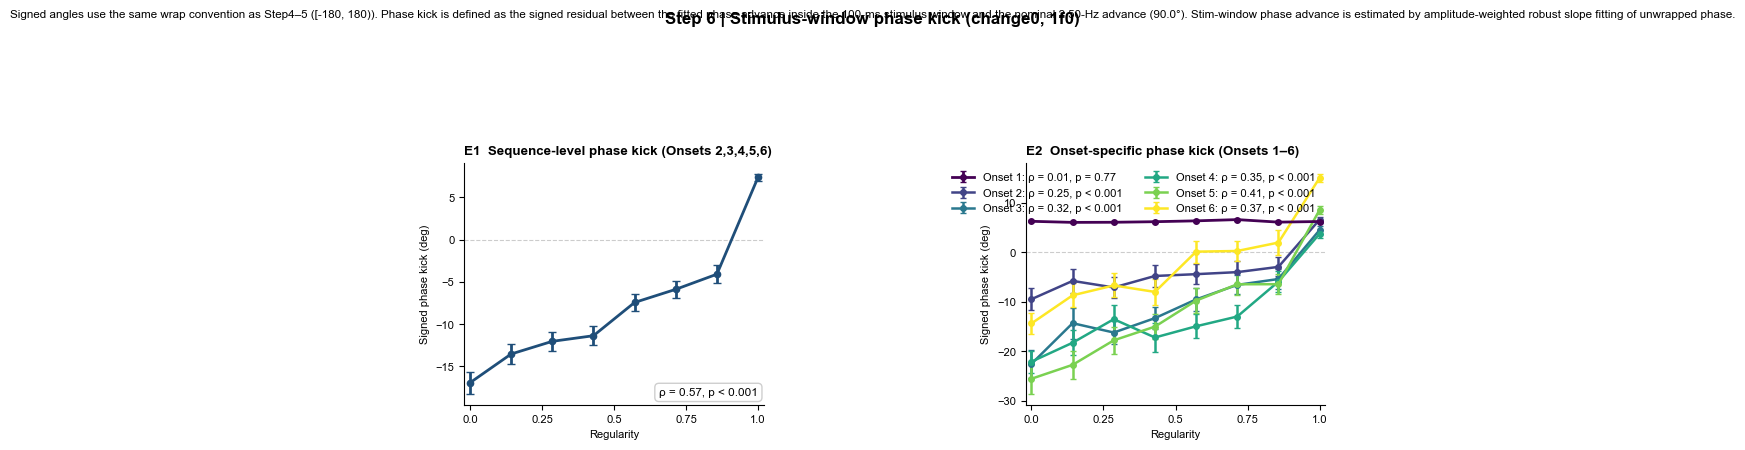

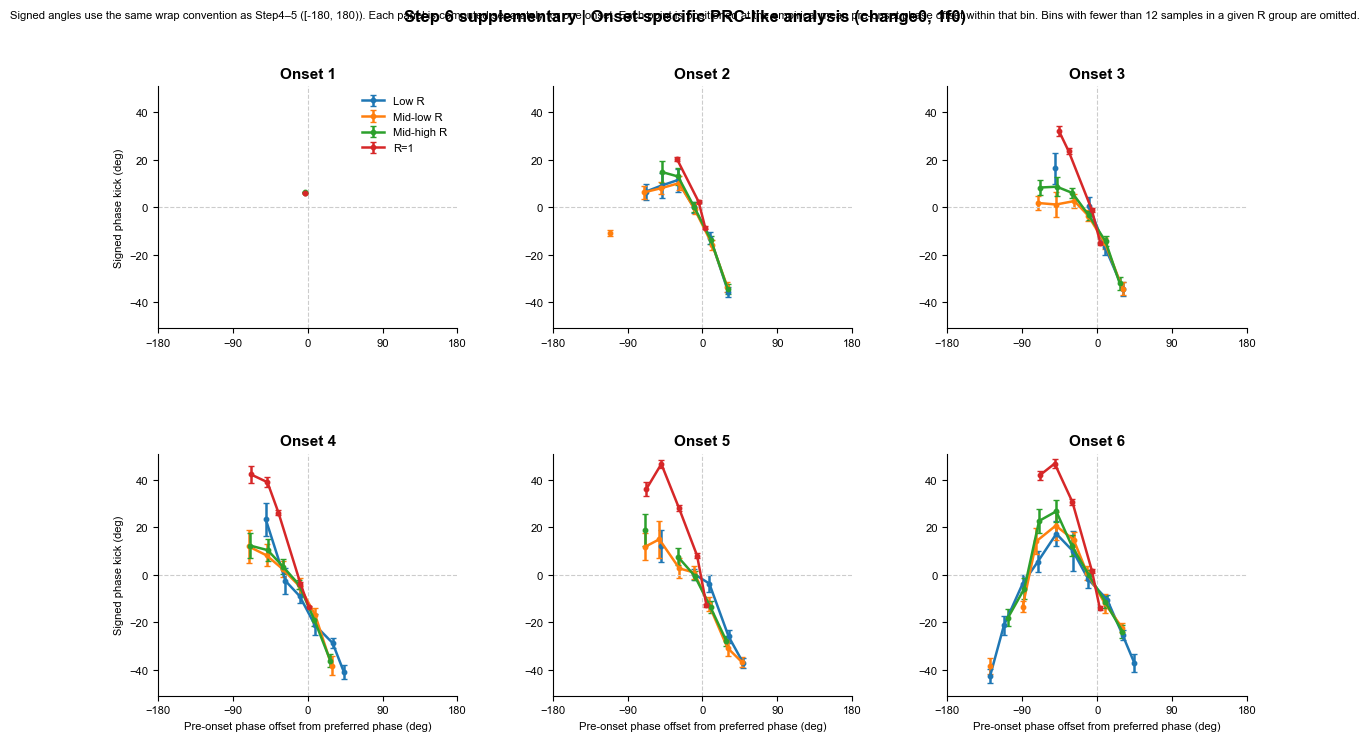

In [7]:
# ========================================================================
# Part 6: Step 6 | Stimulus-window phase kick
# ========================================================================
# =========================================================
# Step 6 | Stimulus-window phase kick
# Final integrated version with:
#   - exact same signed-angle convention as Step4–5: [-180, 180)
#   - robust amplitude-weighted phase-slope fitting inside Stim
#   - main figure: E1/E2 only
#   - supplementary: onset-specific PRC-like analysis (O1–O6 separately)
#   - diagnostics: raw phase-offset coverage checks per onset
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================================
# 0) Style helper
# =========================================================
def _step6_set_style():
    fn = globals().get("set_nature_neuro_style", None)
    if callable(fn):
        fn()
    else:
        plt.rcParams.update({
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 1.0,
            "xtick.major.width": 1.0,
            "ytick.major.width": 1.0,
        })

# =========================================================
# 1) Generic helpers
# =========================================================
def _step6_wrap_deg(x):
    """
    EXACTLY the same half-open representation as Step4–5:
        ((x + 180) % 360) - 180
    i.e. [-180, 180)
    """
    x = np.asarray(x, dtype=float)
    return ((x + 180.0) % 360.0) - 180.0

def _step6_wrap_rad(x):
    x = np.asarray(x, dtype=float)
    return np.deg2rad(_step6_wrap_deg(np.rad2deg(x)))

def _step6_nansem(x, axis=0):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    out = sd / np.sqrt(np.maximum(n, 1))
    out = np.asarray(out)
    out[n <= 1] = np.nan
    return out

def _step6_safe_row_nanmean(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape[0], np.nan, dtype=float)
    valid_counts = np.sum(np.isfinite(x), axis=1)
    has_valid = valid_counts > 0
    if np.any(has_valid):
        out[has_valid] = np.nanmean(x[has_valid], axis=1)
    return out

def _step6_bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return out

    pv = pvals[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    qvals_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev

    qvals = np.empty(n, dtype=float)
    qvals[order] = np.clip(qvals_ranked, 0.0, 1.0)
    out[valid] = qvals
    return out

def _step6_build_r_groups_four(r_raw, perfect_value=1.0, atol=1e-12):
    """
    4 groups:
      0 = Low R
      1 = Mid-low R
      2 = Mid-high R
      3 = R=1
    """
    r_raw = np.asarray(r_raw, dtype=float)
    group_index = np.full(len(r_raw), -1, dtype=int)

    perfect = np.isclose(r_raw, perfect_value, atol=atol)
    nonperfect = ~perfect

    vals = r_raw[nonperfect]
    if len(vals) == 0:
        group_index[:] = 3
        return group_index, ["Low R", "Mid-low R", "Mid-high R", "R=1"]

    q1, q2 = np.quantile(vals, [1/3, 2/3])

    idx_non = np.where(nonperfect)[0]
    for ii in idx_non:
        if r_raw[ii] <= q1:
            group_index[ii] = 0
        elif r_raw[ii] <= q2:
            group_index[ii] = 1
        else:
            group_index[ii] = 2

    group_index[perfect] = 3
    return group_index, ["Low R", "Mid-low R", "Mid-high R", "R=1"]

# =========================================================
# 2) Phase sign / amplitude statistics
# =========================================================
def _step6_infer_phase_forward_sign(step45_results):
    """
    Choose sign so that larger signed phase corresponds to forward progression.
    """
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)
    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    phase_u = np.unwrap(phase_ts, axis=-1)

    perfect = np.isclose(r_raw, 1.0, atol=1e-12)
    idx_trials = np.where(perfect)[0]
    if len(idx_trials) == 0:
        idx_trials = np.arange(len(r_raw))

    slopes = []
    for tr in idx_trials:
        s = int(onsets_sel[tr, 0])
        e = int(onsets_sel[tr, -1] + stim_dur_steps)
        e = min(e, phase_u.shape[1] - 1)
        if e <= s:
            continue
        slopes.append(phase_u[tr, e] - phase_u[tr, s])

    if len(slopes) == 0:
        return 1.0

    med = np.nanmedian(slopes)
    return -1.0 if med < 0 else 1.0

def _step6_prepare_amp_reference(step45_results, amp_floor_quantile=0.20, amp_ref_quantile=0.90):
    """
    Estimate amplitude floor and reference scale from sample-stage amplitudes.
    """
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    n_trial, n_time = amp_ts.shape
    sample_vals = []

    for tr in range(n_trial):
        s = int(onsets_sel[tr, 0])
        e = int(onsets_sel[tr, -1] + stim_dur_steps)
        s = max(0, s)
        e = min(n_time, e)
        if e > s:
            vals = amp_ts[tr, s:e]
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                sample_vals.append(vals)

    if len(sample_vals) == 0:
        raise ValueError("Cannot build Step6 amplitude reference: no valid sample-stage amplitudes")

    sample_vals = np.concatenate(sample_vals)
    amp_floor = float(np.nanquantile(sample_vals, amp_floor_quantile))
    amp_ref = float(np.nanquantile(sample_vals, amp_ref_quantile))
    amp_ref = max(amp_ref, amp_floor + 1e-8)
    return amp_floor, amp_ref

# =========================================================
# 3) Robust weighted phase-slope fitting
# =========================================================
def _step6_weighted_linear_fit(x, y, w):
    """
    Weighted linear regression:
      y = slope * x + intercept
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if np.sum(valid) < 2:
        return None

    x = x[valid]
    y = y[valid]
    w = w[valid]

    sw = np.sum(w)
    if sw <= 0:
        return None

    xbar = np.sum(w * x) / sw
    ybar = np.sum(w * y) / sw

    xc = x - xbar
    yc = y - ybar

    denom = np.sum(w * xc * xc)
    if denom <= 0:
        return None

    slope = np.sum(w * xc * yc) / denom
    intercept = ybar - slope * xbar

    yhat = slope * x + intercept
    rss = np.sum(w * (y - yhat) ** 2)
    tss = np.sum(w * (y - ybar) ** 2)
    r2 = np.nan if tss <= 0 else (1.0 - rss / tss)

    return slope, intercept, r2

def _step6_fit_phase_slope_robust(
    phase_u_trial,
    amp_trial,
    start_step,
    end_step,
    amp_floor,
    amp_ref,
    min_valid_points=6,
    huber_c=1.5,
    max_iter=5,
):
    """
    Robust amplitude-weighted fit of unwrapped phase within [start_step, end_step).

    Returns:
      slope_rad_per_step, intercept, n_valid, r2, valid_frac, eff_weight_frac
    """
    start_step = int(start_step)
    end_step = int(end_step)
    if end_step <= start_step:
        return None

    y = np.asarray(phase_u_trial[start_step:end_step], dtype=float)
    a = np.asarray(amp_trial[start_step:end_step], dtype=float)
    L = len(y)

    # sample-center times
    x = np.arange(L, dtype=float) + 0.5

    finite = np.isfinite(y) & np.isfinite(a)
    if np.sum(finite) < min_valid_points:
        return None

    base_w = np.zeros(L, dtype=float)
    if np.any(finite):
        rel = (a[finite] - amp_floor) / (amp_ref - amp_floor + 1e-12)
        rel = np.clip(rel, 0.0, 1.0)
        base_w[finite] = np.sqrt(rel)

    valid_frac = np.mean(base_w > 0)
    if np.sum(base_w > 0) < min_valid_points:
        return None

    weights = base_w.copy()
    fit_last = None

    for _ in range(max_iter):
        fit = _step6_weighted_linear_fit(x, y, weights)
        if fit is None:
            return None

        slope, intercept, r2 = fit
        fit_last = (slope, intercept, r2)

        yhat = slope * x + intercept
        resid = y - yhat

        idx = np.isfinite(resid) & (weights > 0)
        r = resid[idx]
        if len(r) < min_valid_points:
            break

        med = np.median(r)
        mad = np.median(np.abs(r - med))
        scale = 1.4826 * mad
        if not np.isfinite(scale) or scale < 1e-8:
            break

        rr = np.abs(resid - med)
        cutoff = huber_c * scale

        huber_w = np.ones(L, dtype=float)
        mask = idx & (rr > cutoff)
        huber_w[mask] = cutoff / rr[mask]

        new_weights = base_w * huber_w

        if np.allclose(new_weights, weights, atol=1e-6, rtol=1e-4):
            weights = new_weights
            break
        weights = new_weights

    if fit_last is None:
        return None

    slope, intercept, r2 = fit_last
    eff_weight_frac = np.sum(weights) / max(L, 1)

    return slope, intercept, int(np.sum(base_w > 0)), r2, valid_frac, eff_weight_frac

# =========================================================
# 4) PRC plotting helper
# =========================================================
def _step6_plot_segmented_binned_curve(ax, x, y, yerr, valid_mask, color, label=None, lw=2.0, ms=3.6):
    """
    Plot binned PRC curve without connecting across missing bins.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    idx = np.where(valid_mask)[0]
    if len(idx) == 0:
        return

    runs = []
    s = idx[0]
    p = idx[0]
    for k in idx[1:]:
        if k == p + 1:
            p = k
        else:
            runs.append((s, p))
            s = k
            p = k
    runs.append((s, p))

    first = True
    for s, e in runs:
        ii = np.arange(s, e + 1)
        ax.errorbar(
            x[ii],
            y[ii],
            yerr=yerr[ii],
            color=color,
            lw=lw,
            marker="o",
            ms=ms,
            capsize=2.0,
            label=label if first else None,
        )
        first = False

# =========================================================
# 5) Coverage diagnostics
# =========================================================
def print_step6_phase_coverage_summary(step6_results):
    """
    Print raw coverage diagnostics for each onset:
      - quantiles of pre-onset phase offset
      - per-group bin counts
    """
    x_all = np.asarray(step6_results["pre_dev_signed_deg"], dtype=float)
    y_all = np.asarray(step6_results["kick_signed_deg"], dtype=float)
    r_group = np.asarray(step6_results["r_group_index"], dtype=int)
    r_group_names = step6_results["r_group_names"]
    edges = np.asarray(step6_results["prc_phase_bin_edges"], dtype=float)

    n_event = x_all.shape[1]
    print("\n[Step6 phase-offset coverage summary]")
    for j in range(n_event):
        valid = np.isfinite(x_all[:, j]) & np.isfinite(y_all[:, j])
        n_valid = int(np.sum(valid))
        print(f"\nOnset {j+1} | valid trial count = {n_valid}")
        if n_valid == 0:
            continue

        q = np.nanquantile(x_all[valid, j], [0.00, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00])
        print("  x quantiles =", np.round(q, 2))
        print("  x mean/std  =", round(float(np.nanmean(x_all[valid, j])), 2),
              "/", round(float(np.nanstd(x_all[valid, j])), 2))

        for g, name in enumerate(r_group_names):
            vals = x_all[(r_group == g) & np.isfinite(x_all[:, j]), j]
            idx = np.digitize(vals, edges[1:-1], right=False)
            counts = np.array([(idx == b).sum() for b in range(len(edges) - 1)], dtype=int)
            nonzero_bins = np.where(counts > 0)[0]
            print(f"  {name}: n={len(vals)}, nonzero bins={nonzero_bins.tolist()}, counts={counts[counts>0].tolist()}")

def plot_step6_phase_offset_coverage(
    step6_results,
    layer_name="layer",
    figsize=(12.0, 7.5),
    save_pdf_path=None,
):
    """
    Diagnostic plot: raw phase-offset distribution per onset, overlaid by R groups.
    Useful for checking cases like Onset 1 where the apparent PRC x-range looks suspicious.
    """
    _step6_set_style()

    x_all = np.asarray(step6_results["pre_dev_signed_deg"], dtype=float)
    r_group = np.asarray(step6_results["r_group_index"], dtype=int)
    r_group_names = step6_results["r_group_names"]
    band_info = step6_results["band_info"]

    n_event = x_all.shape[1]
    bins = np.arange(-180, 181, 10)

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    cmap = plt.get_cmap("tab10")
    for j in range(n_event):
        ax = axes[j]

        for g, name in enumerate(r_group_names):
            vals = x_all[(r_group == g) & np.isfinite(x_all[:, j]), j]
            if len(vals) == 0:
                continue
            ax.hist(
                vals,
                bins=bins,
                histtype="step",
                linewidth=1.6,
                color=cmap(g),
                label=name if j == 0 else None,
            )

        ax.axvline(0, color="0.7", lw=0.9, ls="--")
        ax.set_xlim(-180, 180)
        ax.set_xticks([-180, -90, 0, 90, 180])
        ax.set_title(f"Onset {j+1}", fontsize=11, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if j in [3, 4, 5]:
            ax.set_xlabel("Pre-onset phase offset from preferred phase (deg)")
        if j in [0, 3]:
            ax.set_ylabel("Count")

    handles, labels = axes[0].get_legend_handles_labels()
    if len(handles) > 0:
        axes[0].legend(handles, labels, fontsize=8, frameon=False, loc="upper right")

    fig.suptitle(
        f"Step 6 diagnostics | Raw phase-offset coverage ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.0, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        "These histograms show the raw pre-onset phase-offset distribution used for onset-specific PRC estimation.",
        ha="center", va="bottom", fontsize=8.2
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 6) Debug summary
# =========================================================
def print_step6_debug_summary(step6_results):
    print("\n[Step6 debug summary]")
    print(f"stim_dur_steps            = {step6_results['stim_dur_steps']}")
    print(f"f0_hz                     = {step6_results['f0_hz']:.3f}")
    print(f"nominal_advance_deg       = {step6_results['nominal_advance_deg']:.3f}")
    print(f"amp_floor_quantile        = {step6_results['amp_floor_quantile']}")
    print(f"amp_ref_quantile          = {step6_results['amp_ref_quantile']}")
    print(f"amp_floor                 = {step6_results['amp_floor']:.6f}")
    print(f"amp_ref                   = {step6_results['amp_ref']:.6f}")
    print(f"min_valid_stim_points     = {step6_results['min_valid_stim_points']}")
    print(f"min_fit_r2                = {step6_results['min_fit_r2']:.3f}")
    print(f"phase_forward_sign        = {step6_results['phase_forward_sign']:+.1f}")

    n_event = step6_results["kick_valid_frac"].shape[1]
    for j in range(n_event):
        vals_v = step6_results["kick_valid_frac"][:, j]
        vals_w = step6_results["kick_eff_weight_frac"][:, j]
        vals_r2 = step6_results["fit_r2"][:, j]
        print(
            f"Onset {j+1} valid frac    = {np.nanmean(vals_v):.3f} ± {np.nanstd(vals_v):.3f} | "
            f"eff weight frac = {np.nanmean(vals_w):.3f} ± {np.nanstd(vals_w):.3f} | "
            f"median fit R² = {np.nanmedian(vals_r2):.3f}"
        )

    print("PRC onset-specific: O1–O6 separately")
    print(f"PRC min bin n       = {step6_results['min_prc_bin_n']}")

# =========================================================
# 7) Main Step6 analysis
# =========================================================
def analyze_step6(
    step45_results,
    amp_floor_quantile=0.20,
    amp_ref_quantile=0.90,
    min_valid_stim_points=None,
    min_fit_r2=0.05,
    exclude_onset1_from_step6=True,
    prc_bin_width_deg=20.0,
    min_prc_bin_n=12,
    print_debug_summary=True,
):
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)

    fs = float(step45_results["fs"])
    stim_dur_steps = int(step45_results["stim_dur_steps"])

    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    r_bin_index = np.asarray(step45_results["r_bin_index"], dtype=int)
    bin_medians_raw = np.asarray(step45_results["bin_medians_raw"], dtype=float)
    band_info = step45_results["band_info"]

    # Step4–5 preferred-phase deviation at onset
    pre_dev_signed_rad_raw = np.asarray(step45_results["signed_dev_rad"], dtype=float)
    pre_dev_abs_deg = np.asarray(step45_results["abs_dev_deg"], dtype=float)

    n_trial, n_time = phase_ts.shape
    n_event = onsets_sel.shape[1]
    n_bins = len(bin_medians_raw)

    if min_valid_stim_points is None:
        min_valid_stim_points = max(4, int(np.ceil(stim_dur_steps * 0.60)))

    f0_hz = float(band_info["center_hz"])
    nominal_advance_rad = 2.0 * np.pi * f0_hz * (stim_dur_steps / fs)
    nominal_advance_deg = np.rad2deg(nominal_advance_rad)

    # choose phase sign so that forward progression is positive
    phase_forward_sign = _step6_infer_phase_forward_sign(step45_results)
    phase_u_signed = np.unwrap(phase_ts, axis=-1) * phase_forward_sign

    # align pre-onset signed phase offset to same sign convention
    pre_dev_signed_rad = _step6_wrap_rad(pre_dev_signed_rad_raw * phase_forward_sign)
    pre_dev_signed_deg = _step6_wrap_deg(np.rad2deg(pre_dev_signed_rad))

    # amplitude references
    amp_floor, amp_ref = _step6_prepare_amp_reference(
        step45_results=step45_results,
        amp_floor_quantile=amp_floor_quantile,
        amp_ref_quantile=amp_ref_quantile,
    )

    # outputs
    kick_signed_rad = np.full((n_trial, n_event), np.nan, dtype=float)
    kick_signed_deg = np.full((n_trial, n_event), np.nan, dtype=float)
    obs_advance_deg = np.full((n_trial, n_event), np.nan, dtype=float)
    obs_slope_hz = np.full((n_trial, n_event), np.nan, dtype=float)
    fit_r2 = np.full((n_trial, n_event), np.nan, dtype=float)

    kick_valid_frac = np.full((n_trial, n_event), np.nan, dtype=float)
    kick_eff_weight_frac = np.full((n_trial, n_event), np.nan, dtype=float)

    for tr in range(n_trial):
        for j in range(n_event):
            t_on = int(onsets_sel[tr, j])
            t_off = int(t_on + stim_dur_steps)   # exclusive end of Stim window

            if not (0 <= t_on < n_time and 0 < t_off <= n_time):
                continue

            fit = _step6_fit_phase_slope_robust(
                phase_u_trial=phase_u_signed[tr],
                amp_trial=amp_ts[tr],
                start_step=t_on,
                end_step=t_off,
                amp_floor=amp_floor,
                amp_ref=amp_ref,
                min_valid_points=min_valid_stim_points,
                huber_c=1.5,
                max_iter=5,
            )
            if fit is None:
                continue

            slope_rad_per_step, intercept, n_valid, r2, valid_frac, eff_weight_frac = fit
            fit_r2[tr, j] = r2
            kick_valid_frac[tr, j] = valid_frac
            kick_eff_weight_frac[tr, j] = eff_weight_frac

            if np.isfinite(r2) and r2 < min_fit_r2:
                continue

            delta_obs_rad = slope_rad_per_step * stim_dur_steps
            kick_rad = _step6_wrap_rad(delta_obs_rad - nominal_advance_rad)

            kick_signed_rad[tr, j] = kick_rad
            kick_signed_deg[tr, j] = _step6_wrap_deg(np.rad2deg(kick_rad))
            obs_advance_deg[tr, j] = np.rad2deg(delta_obs_rad)
            obs_slope_hz[tr, j] = (slope_rad_per_step * fs) / (2.0 * np.pi)

    # main onset set vs plot onset set
    if exclude_onset1_from_step6 and n_event > 1:
        e_onsets_main = np.arange(1, n_event)
    else:
        e_onsets_main = np.arange(n_event)

    e_onsets_plot = np.arange(n_event)

    # sequence-level summaries
    seq_kick_signed_mean_all = _step6_safe_row_nanmean(kick_signed_deg)
    seq_kick_signed_mean_main = _step6_safe_row_nanmean(kick_signed_deg[:, e_onsets_main])

    # bin summaries
    seq_kick_bin_mean = np.full(n_bins, np.nan, dtype=float)
    seq_kick_bin_sem = np.full(n_bins, np.nan, dtype=float)
    seq_kick_bin_n = np.zeros(n_bins, dtype=int)

    kick_bin_mean_all = np.full((n_bins, n_event), np.nan, dtype=float)
    kick_bin_sem_all = np.full((n_bins, n_event), np.nan, dtype=float)
    kick_bin_n_all = np.zeros((n_bins, n_event), dtype=int)

    for b in range(n_bins):
        idx_b = np.where(r_bin_index == b)[0]

        vals_seq = seq_kick_signed_mean_main[idx_b]
        vals_seq = vals_seq[np.isfinite(vals_seq)]
        seq_kick_bin_n[b] = len(vals_seq)
        if len(vals_seq) > 0:
            seq_kick_bin_mean[b] = np.mean(vals_seq)
            seq_kick_bin_sem[b] = stats.sem(vals_seq, nan_policy="omit") if len(vals_seq) > 1 else 0.0

        for j in range(n_event):
            vals_signed = kick_signed_deg[idx_b, j]
            vals_signed = vals_signed[np.isfinite(vals_signed)]
            kick_bin_n_all[b, j] = len(vals_signed)
            if len(vals_signed) > 0:
                kick_bin_mean_all[b, j] = np.mean(vals_signed)
                kick_bin_sem_all[b, j] = stats.sem(vals_signed, nan_policy="omit") if len(vals_signed) > 1 else 0.0

    # continuous-R statistics
    valid_seq = np.isfinite(r_raw) & np.isfinite(seq_kick_signed_mean_main)
    if np.sum(valid_seq) >= 5:
        rr_seq = stats.spearmanr(r_raw[valid_seq], seq_kick_signed_mean_main[valid_seq])
        seq_kick_rho = rr_seq.correlation
        seq_kick_p = rr_seq.pvalue
    else:
        seq_kick_rho, seq_kick_p = np.nan, np.nan

    onset_kick_rho = np.full(n_event, np.nan)
    onset_kick_p = np.full(n_event, np.nan)

    for j in range(n_event):
        valid = np.isfinite(r_raw) & np.isfinite(kick_signed_deg[:, j])
        if np.sum(valid) >= 5:
            rr = stats.spearmanr(r_raw[valid], kick_signed_deg[valid, j])
            onset_kick_rho[j] = rr.correlation
            onset_kick_p[j] = rr.pvalue

    onset_kick_q = _step6_bh_fdr(onset_kick_p)

    # -----------------------------------------------------
    # Onset-specific PRC-like supplementary analysis
    # x = pre-onset phase offset from preferred phase
    # y = signed phase kick
    # done separately for each onset
    # x-position uses empirical mean phase offset within each bin
    # -----------------------------------------------------
    r_group_index, r_group_names = _step6_build_r_groups_four(r_raw)

    prc_phase_bin_edges = np.arange(-180.0, 180.0 + prc_bin_width_deg, prc_bin_width_deg)
    prc_phase_bin_centers_nominal = prc_phase_bin_edges[:-1] + prc_bin_width_deg / 2.0
    prc_phase_bin_centers_nominal = _step6_wrap_deg(prc_phase_bin_centers_nominal)
    n_prc_bins = len(prc_phase_bin_centers_nominal)

    # shape: [onset, group, bin]
    prc_x_emp = np.full((n_event, 4, n_prc_bins), np.nan, dtype=float)
    prc_mean = np.full((n_event, 4, n_prc_bins), np.nan, dtype=float)
    prc_sem = np.full((n_event, 4, n_prc_bins), np.nan, dtype=float)
    prc_n = np.zeros((n_event, 4, n_prc_bins), dtype=int)

    for j in range(n_event):
        for g in range(4):
            idx_tr = np.where(r_group_index == g)[0]
            if len(idx_tr) == 0:
                continue

            x = pre_dev_signed_deg[idx_tr, j]
            y = kick_signed_deg[idx_tr, j]
            valid = np.isfinite(x) & np.isfinite(y)
            if not np.any(valid):
                continue

            x_pool = _step6_wrap_deg(x[valid])
            y_pool = _step6_wrap_deg(y[valid])

            bin_idx = np.digitize(x_pool, prc_phase_bin_edges[1:-1], right=False)
            for b in range(n_prc_bins):
                mask_b = (bin_idx == b)
                vals_x = x_pool[mask_b]
                vals_y = y_pool[mask_b]

                vals_x = vals_x[np.isfinite(vals_x)]
                vals_y = vals_y[np.isfinite(vals_y)]

                n_b = len(vals_y)
                prc_n[j, g, b] = n_b

                if n_b >= min_prc_bin_n:
                    prc_x_emp[j, g, b] = np.mean(vals_x)
                    prc_mean[j, g, b] = np.mean(vals_y)
                    prc_sem[j, g, b] = stats.sem(vals_y, nan_policy="omit") if len(vals_y) > 1 else 0.0

    results = {
        "fs": fs,
        "band_info": band_info,
        "f0_hz": f0_hz,
        "stim_dur_steps": stim_dur_steps,
        "nominal_advance_rad": nominal_advance_rad,
        "nominal_advance_deg": nominal_advance_deg,

        "amp_floor_quantile": amp_floor_quantile,
        "amp_ref_quantile": amp_ref_quantile,
        "amp_floor": amp_floor,
        "amp_ref": amp_ref,
        "min_valid_stim_points": min_valid_stim_points,
        "min_fit_r2": min_fit_r2,
        "phase_forward_sign": phase_forward_sign,

        "r_raw": r_raw,
        "r_bin_index": r_bin_index,
        "bin_medians_raw": bin_medians_raw,
        "onsets_sel": onsets_sel,

        "phase_u_signed": phase_u_signed,

        "pre_dev_signed_rad": pre_dev_signed_rad,
        "pre_dev_signed_deg": pre_dev_signed_deg,
        "pre_dev_abs_deg": pre_dev_abs_deg,

        "kick_signed_rad": kick_signed_rad,
        "kick_signed_deg": kick_signed_deg,
        "obs_advance_deg": obs_advance_deg,
        "obs_slope_hz": obs_slope_hz,
        "fit_r2": fit_r2,

        "kick_valid_frac": kick_valid_frac,
        "kick_eff_weight_frac": kick_eff_weight_frac,

        "seq_kick_signed_mean_all": seq_kick_signed_mean_all,
        "seq_kick_signed_mean_main": seq_kick_signed_mean_main,

        "step6_main_onset_indices": e_onsets_main,
        "step6_plot_onset_indices": e_onsets_plot,
        "exclude_onset1_from_step6": exclude_onset1_from_step6,

        "seq_kick_bin_mean": seq_kick_bin_mean,
        "seq_kick_bin_sem": seq_kick_bin_sem,
        "seq_kick_bin_n": seq_kick_bin_n,

        "kick_bin_mean_all": kick_bin_mean_all,
        "kick_bin_sem_all": kick_bin_sem_all,
        "kick_bin_n_all": kick_bin_n_all,

        "seq_kick_rho": seq_kick_rho,
        "seq_kick_p": seq_kick_p,
        "onset_kick_rho": onset_kick_rho,
        "onset_kick_p": onset_kick_p,
        "onset_kick_q": onset_kick_q,

        # onset-specific PRC-like supplementary
        "r_group_index": r_group_index,
        "r_group_names": r_group_names,
        "prc_bin_width_deg": prc_bin_width_deg,
        "min_prc_bin_n": min_prc_bin_n,
        "prc_phase_bin_edges": prc_phase_bin_edges,
        "prc_phase_bin_centers_nominal": prc_phase_bin_centers_nominal,
        "prc_x_emp": prc_x_emp,
        "prc_mean": prc_mean,
        "prc_sem": prc_sem,
        "prc_n": prc_n,
    }

    if print_debug_summary:
        print_step6_debug_summary(results)

    return results

# =========================================================
# 8) Plot Step6 main figure
# =========================================================
def plot_step6_phase_kick(
    step6_results,
    layer_name="layer",
    figsize=(11.2, 5.4),
    show_onset1_in_e2=True,
    onset1_color=POS_COLORS[0],
    save_pdf_path=None,
):
    _step6_set_style()

    n_bins = len(step6_results["bin_medians_raw"])
    x_pos = _normalized_regulariy_axis(n_bins)
    x_tick_pos = np.linspace(0.0, 1.0, 5)
    x_tick_labels = ["0.00", "0.25", "0.50", "0.75", "1.00"]

    seq_y = step6_results["seq_kick_bin_mean"]
    seq_yerr = step6_results["seq_kick_bin_sem"]
    seq_rho = step6_results["seq_kick_rho"]
    seq_p = step6_results["seq_kick_p"]

    kick_y_all = step6_results["kick_bin_mean_all"]
    kick_yerr_all = step6_results["kick_bin_sem_all"]
    onset_rho = step6_results["onset_kick_rho"]
    onset_p = step6_results["onset_kick_p"]
    onset_q = step6_results["onset_kick_q"]

    e_onsets_main = np.asarray(step6_results["step6_main_onset_indices"], dtype=int)
    e_onsets_plot = np.asarray(step6_results["step6_plot_onset_indices"], dtype=int)
    if not show_onset1_in_e2 and len(e_onsets_plot) > 1:
        e_onsets_plot = e_onsets_plot[1:]

    band_info = step6_results["band_info"]
    nominal_deg = step6_results["nominal_advance_deg"]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax1, ax2 = axes

    ax1.errorbar(
        x_pos, seq_y, yerr=seq_yerr,
        color="#1F4E79", lw=2.0, marker="o", ms=4.5, capsize=2.8
    )
    ax1.axhline(0, color="0.8", lw=0.8, ls="--")
    ax1.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_xlabel("Regularity")
    ax1.set_ylabel("Signed phase kick (deg)")
    main_onset_label = ",".join([f"{j+1}" for j in e_onsets_main])
    ax1.set_title(
        f"E1  Sequence-level phase kick (Onsets {main_onset_label})",
        loc="left", fontweight="bold"
    )
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    txt1 = f"ρ = {seq_rho:.2f}, {format_p(seq_p)}"
    ax1.text(
        0.98, 0.03, txt1,
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.95)
    )

    for j in e_onsets_plot:
        if j == 0 and show_onset1_in_e2:
            color = onset1_color
            lw = 2.0
            zorder = 4
        else:
            color = _pos_color(j)
            lw = 1.8
            zorder = 3

        ax2.errorbar(
            x_pos,
            kick_y_all[:, j],
            yerr=kick_yerr_all[:, j],
            color=color,
            lw=lw,
            marker="o",
            ms=4.0,
            capsize=2.2,
            label=f"Onset {j+1}: ρ = {onset_rho[j]:.2f}, {format_p(onset_p[j])}",
            zorder=zorder,
        )

    ax2.axhline(0, color="0.8", lw=0.8, ls="--")
    ax2.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_xlabel("Regularity")
    ax2.set_ylabel("Signed phase kick (deg)")
    if show_onset1_in_e2:
        ax2.set_title("E2  Onset-specific phase kick (Onsets 1–6)",
                      loc="left", fontweight="bold")
    else:
        ax2.set_title("E2  Onset-specific phase kick (Onsets 2–6)",
                      loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.legend(ncol=2, fontsize=8, frameon=False)

    fig.suptitle(
        f"Step 6 | Stimulus-window phase kick ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.2, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        f"Signed angles use the same wrap convention as Step4–5 ([-180, 180)). "
        f"Phase kick is defined as the signed residual between the fitted phase advance inside the 100-ms stimulus window "
        f"and the nominal {band_info['center_hz']:.2f}-Hz advance ({nominal_deg:.1f}°). "
        f"Stim-window phase advance is estimated by amplitude-weighted robust slope fitting of unwrapped phase.",
        ha="center", va="bottom", fontsize=8.4
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 9) Plot onset-specific PRC supplementary
# =========================================================
def plot_step6_prc_supplement(
    step6_results,
    layer_name="layer",
    figsize=(12.0, 7.5),
    save_pdf_path=None,
):
    _step6_set_style()

    prc_x_emp = np.asarray(step6_results["prc_x_emp"], dtype=float)   # [onset, group, bin]
    prc_mean = np.asarray(step6_results["prc_mean"], dtype=float)
    prc_sem = np.asarray(step6_results["prc_sem"], dtype=float)
    prc_n = np.asarray(step6_results["prc_n"], dtype=int)

    r_group_names = step6_results["r_group_names"]
    min_prc_bin_n = int(step6_results["min_prc_bin_n"])
    band_info = step6_results["band_info"]

    n_event = prc_x_emp.shape[0]

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    cmap = plt.get_cmap("tab10")

    # Use one shared y range across all onset panels, symmetric around 0.
    y_abs_max = 0.0
    for j in range(n_event):
        for g in range(prc_mean.shape[1]):
            valid = (
                np.isfinite(prc_mean[j, g]) &
                np.isfinite(prc_x_emp[j, g]) &
                (prc_n[j, g] >= min_prc_bin_n)
            )
            if not np.any(valid):
                continue

            yv = np.asarray(prc_mean[j, g][valid], dtype=float)
            ev = np.asarray(prc_sem[j, g][valid], dtype=float)
            ev = np.where(np.isfinite(ev), ev, 0.0)
            if yv.size == 0:
                continue

            local_max = float(np.nanmax(np.abs(yv) + ev))
            if np.isfinite(local_max):
                y_abs_max = max(y_abs_max, local_max)

    if not np.isfinite(y_abs_max) or y_abs_max <= 0:
        y_abs_max = 1.0
    else:
        y_abs_max *= 1.05

    for j in range(n_event):
        ax = axes[j]

        for g in range(prc_mean.shape[1]):
            valid = (
                np.isfinite(prc_mean[j, g]) &
                np.isfinite(prc_x_emp[j, g]) &
                (prc_n[j, g] >= min_prc_bin_n)
            )
            if not np.any(valid):
                continue

            _step6_plot_segmented_binned_curve(
                ax=ax,
                x=prc_x_emp[j, g],
                y=prc_mean[j, g],
                yerr=prc_sem[j, g],
                valid_mask=valid,
                color=cmap(g),
                label=r_group_names[g] if j == 0 else None,
                lw=1.8,
                ms=3.2,
            )

        ax.axhline(0, color="0.8", lw=0.8, ls="--")
        ax.axvline(0, color="0.8", lw=0.8, ls="--")
        ax.set_xlim(-180, 180)
        ax.set_ylim(-y_abs_max, y_abs_max)
        ax.set_xticks([-180, -90, 0, 90, 180])
        ax.set_title(f"Onset {j+1}", fontsize=11, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if j in [3, 4, 5]:
            ax.set_xlabel("Pre-onset phase offset from preferred phase (deg)")
        if j in [0, 3]:
            ax.set_ylabel("Signed phase kick (deg)")

    handles, labels = axes[0].get_legend_handles_labels()
    if len(handles) > 0:
        axes[0].legend(handles, labels, fontsize=8, frameon=False, loc="upper right")

    fig.suptitle(
        f"Step 6 supplementary | Onset-specific PRC-like analysis ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.0, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        f"Signed angles use the same wrap convention as Step4–5 ([-180, 180)). "
        f"Each panel is computed separately for one onset. "
        f"Each point is positioned at the empirical mean pre-onset phase offset within that bin. "
        f"Bins with fewer than {min_prc_bin_n} samples in a given R group are omitted.",
        ha="center", va="bottom", fontsize=8.1
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 10) Example run
# =========================================================
step6_change0 = analyze_step6(
    step45_results=step45_change0,
    amp_floor_quantile=0.20,
    amp_ref_quantile=0.90,
    min_valid_stim_points=None,   # auto from stim length
    min_fit_r2=0.05,
    exclude_onset1_from_step6=True,
    prc_bin_width_deg=20.0,
    min_prc_bin_n=12,
    print_debug_summary=True,
)
save_intermediate_pickle(step6_change0, "step6_change0_onset_specific_prc.pkl")

print_step6_phase_coverage_summary(step6_change0)

fig_f, axes_f = plot_step6_phase_kick(
    step6_change0,
    layer_name="change0",
    show_onset1_in_e2=True,
    save_pdf_path=os.path.join(out_dir, "Fig3F.pdf")
)

fig_prc, axes_prc = plot_step6_prc_supplement(
    step6_change0,
    layer_name="change0",
    save_pdf_path=os.path.join(out_dir, "Fig3F_supplement.pdf")
)
# Removed non-target Step6 supplementary figure by naming matrix.

# fig_cov, axes_cov = plot_step6_phase_offset_coverage(
#     step6_change0,
#     layer_name="change0",
#     save_pdf_path=os.path.join(out_dir, "Step6_change0_phase_offset_coverage_diagnostic.pdf")
# )


Fig3G



[Step7 debug summary | exact Step6-consistent]
Main transitions (0-based current onset) = [1 2 3 4]
Main transitions (labels) = ['O2->O3', 'O3->O4', 'O4->O5', 'O5->O6']
Baseline transition label = O1->O2
f0_hz = 2.500
stim_if_source           = step6_results['obs_slope_hz']
amp_floor                = 1.306785
amp_ref                  = 2.883140
min_valid_post_points    = 6
min_fit_r2               = 0.050
O1->O2: mean |IF_post-f0| = 0.291 Hz, mean IF_stim = 2.672 Hz, mean IF_post = 2.209 Hz, mean post length = 30.03 steps
    post valid frac = 1.000 ± 0.000 | eff weight frac = 0.919 ± 0.054 | median post-fit R² = 0.998
O2->O3: mean |IF_post-f0| = 0.429 Hz, mean IF_stim = 2.558 Hz, mean IF_post = 2.299 Hz, mean post length = 30.49 steps
    post valid frac = 0.804 ± 0.218 | eff weight frac = 0.526 ± 0.263 | median post-fit R² = 0.994
O3->O4: mean |IF_post-f0| = 0.481 Hz, mean IF_stim = 2.444 Hz, mean IF_post = 2.257 Hz, mean post length = 30.77 steps
    post valid frac = 0.808 ± 0.214

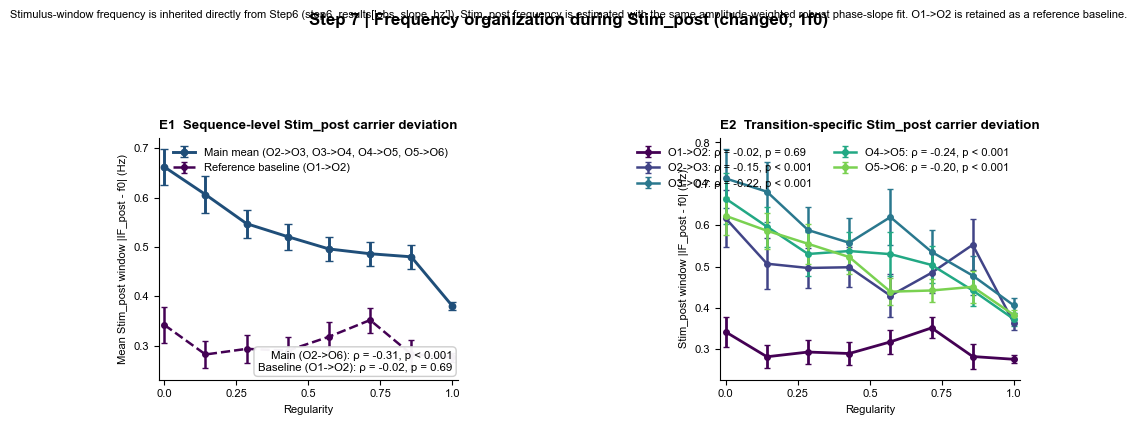

In [8]:
# ========================================================================
# Part 7: Step 7 | Frequency organization during Stim_post
# ========================================================================
# =========================================================
# Step 7 | Frequency organization during Stim_post
# Final version:
#   - delete supplementary S1 / S2
#   - keep O1->O2 as a reference baseline in the main figure
#   - exact consistency with the provided Step6 code
#
# Main figures:
#   E1 : sequence-level mean Stim_post |IF_post - f0| over O2->O6,
#        with O1->O2 shown as a reference baseline
#   E2 : transition-specific Stim_post |IF_post - f0|, including O1->O2
#
# Core alignment with Step6:
#   1) IF_stim is inherited directly from step6_results["obs_slope_hz"]
#   2) IF_post is estimated with the SAME robust amplitude-weighted slope fit
#      used in Step6
#   3) phase_u_signed / amp_floor / amp_ref / min_valid_points / min_fit_r2
#      all inherit Step6 definitions
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================================
# 0) Style helper
# =========================================================
def _step7_set_style():
    fn = globals().get("set_nature_neuro_style", None)
    if callable(fn):
        fn()
    else:
        plt.rcParams.update({
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 1.0,
            "xtick.major.width": 1.0,
            "ytick.major.width": 1.0,
        })

# =========================================================
# 1) Generic helpers
# =========================================================
def _step7_nansem(x, axis=0):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    out = sd / np.sqrt(np.maximum(n, 1))
    out = np.asarray(out)
    out[n <= 1] = np.nan
    return out

def _step7_safe_row_nanmean(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape[0], np.nan, dtype=float)
    valid_counts = np.sum(np.isfinite(x), axis=1)
    has_valid = valid_counts > 0
    if np.any(has_valid):
        out[has_valid] = np.nanmean(x[has_valid], axis=1)
    return out

def _step7_bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return out

    pv = pvals[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    qvals_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev

    qvals = np.empty(n, dtype=float)
    qvals[order] = np.clip(qvals_ranked, 0.0, 1.0)
    out[valid] = qvals
    return out

# =========================================================
# 2) EXACT robust fit logic copied from Step6
# =========================================================
def _step7_weighted_linear_fit(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if np.sum(valid) < 2:
        return None

    x = x[valid]
    y = y[valid]
    w = w[valid]

    sw = np.sum(w)
    if sw <= 0:
        return None

    xbar = np.sum(w * x) / sw
    ybar = np.sum(w * y) / sw

    xc = x - xbar
    yc = y - ybar

    denom = np.sum(w * xc * xc)
    if denom <= 0:
        return None

    slope = np.sum(w * xc * yc) / denom
    intercept = ybar - slope * xbar

    yhat = slope * x + intercept
    rss = np.sum(w * (y - yhat) ** 2)
    tss = np.sum(w * (y - ybar) ** 2)
    r2 = np.nan if tss <= 0 else (1.0 - rss / tss)

    return slope, intercept, r2

def _step7_fit_phase_slope_robust(
    phase_u_trial,
    amp_trial,
    start_step,
    end_step,
    amp_floor,
    amp_ref,
    min_valid_points=6,
    huber_c=1.5,
    max_iter=5,
):
    """
    EXACTLY the same robust amplitude-weighted fit as Step6.
    """
    start_step = int(start_step)
    end_step = int(end_step)
    if end_step <= start_step:
        return None

    y = np.asarray(phase_u_trial[start_step:end_step], dtype=float)
    a = np.asarray(amp_trial[start_step:end_step], dtype=float)
    L = len(y)

    x = np.arange(L, dtype=float) + 0.5

    finite = np.isfinite(y) & np.isfinite(a)
    if np.sum(finite) < min_valid_points:
        return None

    base_w = np.zeros(L, dtype=float)
    if np.any(finite):
        rel = (a[finite] - amp_floor) / (amp_ref - amp_floor + 1e-12)
        rel = np.clip(rel, 0.0, 1.0)
        base_w[finite] = np.sqrt(rel)

    valid_frac = np.mean(base_w > 0)
    if np.sum(base_w > 0) < min_valid_points:
        return None

    weights = base_w.copy()
    fit_last = None

    for _ in range(max_iter):
        fit = _step7_weighted_linear_fit(x, y, weights)
        if fit is None:
            return None

        slope, intercept, r2 = fit
        fit_last = (slope, intercept, r2)

        yhat = slope * x + intercept
        resid = y - yhat

        idx = np.isfinite(resid) & (weights > 0)
        r = resid[idx]
        if len(r) < min_valid_points:
            break

        med = np.median(r)
        mad = np.median(np.abs(r - med))
        scale = 1.4826 * mad
        if not np.isfinite(scale) or scale < 1e-8:
            break

        rr = np.abs(resid - med)
        cutoff = huber_c * scale

        huber_w = np.ones(L, dtype=float)
        mask = idx & (rr > cutoff)
        huber_w[mask] = cutoff / rr[mask]

        new_weights = base_w * huber_w

        if np.allclose(new_weights, weights, atol=1e-6, rtol=1e-4):
            weights = new_weights
            break
        weights = new_weights

    if fit_last is None:
        return None

    slope, intercept, r2 = fit_last
    eff_weight_frac = np.sum(weights) / max(L, 1)

    return slope, intercept, int(np.sum(base_w > 0)), r2, valid_frac, eff_weight_frac

# =========================================================
# 3) Debug summary
# =========================================================
def print_step7_debug_summary(step7_results):
    print("\n[Step7 debug summary | exact Step6-consistent]")
    print(f"Main transitions (0-based current onset) = {step7_results['main_transition_current_indices']}")
    print(f"Main transitions (labels) = {step7_results['main_transition_labels']}")
    print(f"Baseline transition label = {step7_results['baseline_transition_label']}")
    print(f"f0_hz = {step7_results['f0_hz']:.3f}")
    print(f"stim_if_source           = {step7_results['stim_if_source']}")
    print(f"amp_floor                = {step7_results['amp_floor']:.6f}")
    print(f"amp_ref                  = {step7_results['amp_ref']:.6f}")
    print(f"min_valid_post_points    = {step7_results['min_valid_post_points']}")
    print(f"min_fit_r2               = {step7_results['min_fit_r2']:.3f}")

    n_event = len(step7_results["transition_labels"])
    for t in range(n_event):
        lab = step7_results["transition_labels"][t]

        vals_abs = step7_results["mean_abs_if_dev_hz"][:, t]
        vals_stim = step7_results["stim_if_hz"][:, t]
        vals_post = step7_results["post_if_hz"][:, t]
        lens = step7_results["post_len_steps"][:, t]
        vals_r2 = step7_results["post_fit_r2"][:, t]
        vals_v = step7_results["post_valid_frac"][:, t]
        vals_w = step7_results["post_eff_weight_frac"][:, t]

        print(
            f"{lab}: "
            f"mean |IF_post-f0| = {np.nanmean(vals_abs):.3f} Hz, "
            f"mean IF_stim = {np.nanmean(vals_stim):.3f} Hz, "
            f"mean IF_post = {np.nanmean(vals_post):.3f} Hz, "
            f"mean post length = {np.nanmean(lens):.2f} steps"
        )
        print(
            f"    post valid frac = {np.nanmean(vals_v):.3f} ± {np.nanstd(vals_v):.3f} | "
            f"eff weight frac = {np.nanmean(vals_w):.3f} ± {np.nanstd(vals_w):.3f} | "
            f"median post-fit R² = {np.nanmedian(vals_r2):.3f}"
        )

    seq_abs_main = step7_results["seq_mean_abs_if_dev_hz_main"]
    seq_abs_base = step7_results["seq_mean_abs_if_dev_hz_baseline"]

    print(
        f"Sequence-level main (O2->O6) mean |IF_post-f0|: "
        f"valid n = {np.sum(np.isfinite(seq_abs_main))}, "
        f"mean = {np.nanmean(seq_abs_main):.3f} Hz, median = {np.nanmedian(seq_abs_main):.3f} Hz"
    )
    print(
        f"Reference baseline O1->O2 mean |IF_post-f0|: "
        f"valid n = {np.sum(np.isfinite(seq_abs_base))}, "
        f"mean = {np.nanmean(seq_abs_base):.3f} Hz, median = {np.nanmedian(seq_abs_base):.3f} Hz"
    )

# =========================================================
# 4) Main Step7 analysis
# =========================================================
def analyze_step7(
    step45_results,
    step6_results,
    exclude_transition1_from_main=True,
    min_post_steps=1,
    min_valid_post_points=None,
    min_fit_r2=None,
    print_debug_summary=True,
):
    """
    Step 7:
    Stim_post frequency organization using the exact Step6 stimulus definition.

    Main metric
    -----------
    mean_abs_if_dev_hz:
        |IF_post - f0|, where IF_post is estimated with the same robust,
        amplitude-weighted slope fitting used in Step6.

    Baseline handling
    -----------------
    O1->O2 is retained as a reference baseline in E1 and E2, but the
    sequence-level main summary is still pooled over O2->O6.
    """
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)

    fs = float(step45_results["fs"])
    stim_dur_steps = int(step45_results["stim_dur_steps"])
    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    r_bin_index = np.asarray(step45_results["r_bin_index"], dtype=int)
    bin_medians_raw = np.asarray(step45_results["bin_medians_raw"], dtype=float)
    band_info = step45_results["band_info"]

    n_trial, n_time = phase_ts.shape
    n_onset = onsets_sel.shape[1]
    n_trans = n_onset - 1
    n_bins = len(bin_medians_raw)

    if "obs_slope_hz" not in step6_results:
        raise KeyError("step6_results must contain 'obs_slope_hz'.")

    stim_if_full_hz = np.asarray(step6_results["obs_slope_hz"], dtype=float)
    if stim_if_full_hz.shape != (n_trial, n_onset):
        raise ValueError(
            f"step6_results['obs_slope_hz'] has shape {stim_if_full_hz.shape}, "
            f"expected {(n_trial, n_onset)}."
        )

    stim_if_source = "step6_results['obs_slope_hz']"

    if "phase_u_signed" in step6_results:
        phase_u_signed = np.asarray(step6_results["phase_u_signed"], dtype=float)
    else:
        phase_forward_sign = float(step6_results.get("phase_forward_sign", 1.0))
        phase_u_signed = np.unwrap(phase_ts, axis=-1) * phase_forward_sign

    f0_hz = float(step6_results.get("f0_hz", band_info["center_hz"]))
    amp_floor = float(step6_results["amp_floor"])
    amp_ref = float(step6_results["amp_ref"])

    if min_valid_post_points is None:
        min_valid_post_points = int(step6_results["min_valid_stim_points"])
    if min_fit_r2 is None:
        min_fit_r2 = float(step6_results["min_fit_r2"])

    # -----------------------------------------------------
    # Per-trial per-transition metrics
    # -----------------------------------------------------
    post_len_steps = np.full((n_trial, n_trans), np.nan, dtype=float)
    stim_if_hz = np.full((n_trial, n_trans), np.nan, dtype=float)
    post_if_hz = np.full((n_trial, n_trans), np.nan, dtype=float)
    mean_abs_if_dev_hz = np.full((n_trial, n_trans), np.nan, dtype=float)

    post_fit_r2 = np.full((n_trial, n_trans), np.nan, dtype=float)
    post_valid_frac = np.full((n_trial, n_trans), np.nan, dtype=float)
    post_eff_weight_frac = np.full((n_trial, n_trans), np.nan, dtype=float)

    for tr in range(n_trial):
        for t in range(n_trans):
            t_on_curr = int(onsets_sel[tr, t])
            t_off_curr = int(t_on_curr + stim_dur_steps)
            t_on_next = int(onsets_sel[tr, t + 1])

            L_post = t_on_next - t_off_curr
            if L_post < min_post_steps:
                continue
            if not (0 <= t_on_curr < n_time and 0 < t_off_curr <= n_time and 0 < t_on_next <= n_time and t_on_next > t_off_curr):
                continue

            if_stim = stim_if_full_hz[tr, t]
            if not np.isfinite(if_stim):
                continue

            fit = _step7_fit_phase_slope_robust(
                phase_u_trial=phase_u_signed[tr],
                amp_trial=amp_ts[tr],
                start_step=t_off_curr,
                end_step=t_on_next,
                amp_floor=amp_floor,
                amp_ref=amp_ref,
                min_valid_points=min_valid_post_points,
                huber_c=1.5,
                max_iter=5,
            )
            if fit is None:
                continue

            slope_rad_per_step, intercept, n_valid, r2, valid_frac, eff_weight_frac = fit
            post_fit_r2[tr, t] = r2
            post_valid_frac[tr, t] = valid_frac
            post_eff_weight_frac[tr, t] = eff_weight_frac

            if np.isfinite(r2) and r2 < min_fit_r2:
                continue

            if_post = (slope_rad_per_step * fs) / (2.0 * np.pi)

            post_len_steps[tr, t] = L_post
            stim_if_hz[tr, t] = if_stim
            post_if_hz[tr, t] = if_post
            mean_abs_if_dev_hz[tr, t] = np.abs(if_post - f0_hz)

    transition_labels = [f"O{j+1}->O{j+2}" for j in range(n_trans)]

    baseline_transition_index = 0
    baseline_transition_label = transition_labels[baseline_transition_index]

    if exclude_transition1_from_main and n_trans > 1:
        main_transition_current_indices = np.arange(1, n_trans)   # O2->O3 ... O5->O6
    else:
        main_transition_current_indices = np.arange(n_trans)

    main_transition_labels = [transition_labels[j] for j in main_transition_current_indices]

    # -----------------------------------------------------
    # Sequence-level summaries
    # -----------------------------------------------------
    seq_mean_abs_if_dev_hz_main = _step7_safe_row_nanmean(
        mean_abs_if_dev_hz[:, main_transition_current_indices]
    )
    seq_mean_abs_if_dev_hz_baseline = mean_abs_if_dev_hz[:, baseline_transition_index].copy()

    # -----------------------------------------------------
    # Bin summaries for E1 / E2
    # -----------------------------------------------------
    seq_abs_bin_mean_main = np.full(n_bins, np.nan, dtype=float)
    seq_abs_bin_sem_main = np.full(n_bins, np.nan, dtype=float)
    seq_abs_bin_n_main = np.zeros(n_bins, dtype=int)

    seq_abs_bin_mean_baseline = np.full(n_bins, np.nan, dtype=float)
    seq_abs_bin_sem_baseline = np.full(n_bins, np.nan, dtype=float)
    seq_abs_bin_n_baseline = np.zeros(n_bins, dtype=int)

    trans_abs_bin_mean = np.full((n_bins, n_trans), np.nan, dtype=float)
    trans_abs_bin_sem = np.full((n_bins, n_trans), np.nan, dtype=float)
    trans_abs_bin_n = np.zeros((n_bins, n_trans), dtype=int)

    for b in range(n_bins):
        idx_b = np.where(r_bin_index == b)[0]

        vals_main = seq_mean_abs_if_dev_hz_main[idx_b]
        vals_main = vals_main[np.isfinite(vals_main)]
        seq_abs_bin_n_main[b] = len(vals_main)
        if len(vals_main) > 0:
            seq_abs_bin_mean_main[b] = np.mean(vals_main)
            seq_abs_bin_sem_main[b] = stats.sem(vals_main, nan_policy="omit") if len(vals_main) > 1 else 0.0

        vals_base = seq_mean_abs_if_dev_hz_baseline[idx_b]
        vals_base = vals_base[np.isfinite(vals_base)]
        seq_abs_bin_n_baseline[b] = len(vals_base)
        if len(vals_base) > 0:
            seq_abs_bin_mean_baseline[b] = np.mean(vals_base)
            seq_abs_bin_sem_baseline[b] = stats.sem(vals_base, nan_policy="omit") if len(vals_base) > 1 else 0.0

        for t in range(n_trans):
            vals_t = mean_abs_if_dev_hz[idx_b, t]
            vals_t = vals_t[np.isfinite(vals_t)]
            trans_abs_bin_n[b, t] = len(vals_t)
            if len(vals_t) > 0:
                trans_abs_bin_mean[b, t] = np.mean(vals_t)
                trans_abs_bin_sem[b, t] = stats.sem(vals_t, nan_policy="omit") if len(vals_t) > 1 else 0.0

    # -----------------------------------------------------
    # Correlations
    # -----------------------------------------------------
    valid_seq_main = np.isfinite(r_raw) & np.isfinite(seq_mean_abs_if_dev_hz_main)
    if np.sum(valid_seq_main) >= 5:
        rr = stats.spearmanr(r_raw[valid_seq_main], seq_mean_abs_if_dev_hz_main[valid_seq_main])
        seq_abs_rho_main = rr.correlation
        seq_abs_p_main = rr.pvalue
    else:
        seq_abs_rho_main, seq_abs_p_main = np.nan, np.nan

    valid_seq_base = np.isfinite(r_raw) & np.isfinite(seq_mean_abs_if_dev_hz_baseline)
    if np.sum(valid_seq_base) >= 5:
        rr = stats.spearmanr(r_raw[valid_seq_base], seq_mean_abs_if_dev_hz_baseline[valid_seq_base])
        seq_abs_rho_baseline = rr.correlation
        seq_abs_p_baseline = rr.pvalue
    else:
        seq_abs_rho_baseline, seq_abs_p_baseline = np.nan, np.nan

    trans_abs_rho = np.full(n_trans, np.nan)
    trans_abs_p = np.full(n_trans, np.nan)
    for t in range(n_trans):
        valid = np.isfinite(r_raw) & np.isfinite(mean_abs_if_dev_hz[:, t])
        if np.sum(valid) >= 5:
            rr = stats.spearmanr(r_raw[valid], mean_abs_if_dev_hz[valid, t])
            trans_abs_rho[t] = rr.correlation
            trans_abs_p[t] = rr.pvalue
    trans_abs_q = _step7_bh_fdr(trans_abs_p)

    results = {
        "band_info": band_info,
        "f0_hz": f0_hz,
        "r_raw": r_raw,
        "r_bin_index": r_bin_index,
        "bin_medians_raw": bin_medians_raw,

        "stim_if_source": stim_if_source,
        "amp_floor": amp_floor,
        "amp_ref": amp_ref,
        "min_valid_post_points": min_valid_post_points,
        "min_fit_r2": min_fit_r2,

        "post_len_steps": post_len_steps,
        "stim_if_hz": stim_if_hz,
        "post_if_hz": post_if_hz,
        "mean_abs_if_dev_hz": mean_abs_if_dev_hz,
        "post_fit_r2": post_fit_r2,
        "post_valid_frac": post_valid_frac,
        "post_eff_weight_frac": post_eff_weight_frac,

        "transition_labels": transition_labels,
        "baseline_transition_index": baseline_transition_index,
        "baseline_transition_label": baseline_transition_label,
        "main_transition_current_indices": main_transition_current_indices,
        "main_transition_labels": main_transition_labels,

        "seq_mean_abs_if_dev_hz_main": seq_mean_abs_if_dev_hz_main,
        "seq_mean_abs_if_dev_hz_baseline": seq_mean_abs_if_dev_hz_baseline,

        "seq_abs_bin_mean_main": seq_abs_bin_mean_main,
        "seq_abs_bin_sem_main": seq_abs_bin_sem_main,
        "seq_abs_bin_n_main": seq_abs_bin_n_main,

        "seq_abs_bin_mean_baseline": seq_abs_bin_mean_baseline,
        "seq_abs_bin_sem_baseline": seq_abs_bin_sem_baseline,
        "seq_abs_bin_n_baseline": seq_abs_bin_n_baseline,

        "trans_abs_bin_mean": trans_abs_bin_mean,
        "trans_abs_bin_sem": trans_abs_bin_sem,
        "trans_abs_bin_n": trans_abs_bin_n,

        "seq_abs_rho_main": seq_abs_rho_main,
        "seq_abs_p_main": seq_abs_p_main,
        "seq_abs_rho_baseline": seq_abs_rho_baseline,
        "seq_abs_p_baseline": seq_abs_p_baseline,
        "trans_abs_rho": trans_abs_rho,
        "trans_abs_p": trans_abs_p,
        "trans_abs_q": trans_abs_q,
    }

    if print_debug_summary:
        print_step7_debug_summary(results)

    return results

# =========================================================
# 5) Plot Step7 main figure only
# =========================================================
def plot_step7_main(
    step7_results,
    layer_name="layer",
    figsize=(11.2, 4.9),
    baseline_color=POS_COLORS[0],
    main_color="#1F4E79",
    save_pdf_path=None,
):
    _step7_set_style()

    band_info = step7_results["band_info"]
    x_labels = step7_results["bin_medians_raw"]
    n_bins = len(step7_results["bin_medians_raw"])
    x_pos = _normalized_regulariy_axis(n_bins)
    x_tick_pos = np.linspace(0.0, 1.0, 5)
    x_tick_labels = ["0.00", "0.25", "0.50", "0.75", "1.00"]

    seq_y_main = step7_results["seq_abs_bin_mean_main"]
    seq_err_main = step7_results["seq_abs_bin_sem_main"]
    seq_rho_main = step7_results["seq_abs_rho_main"]
    seq_p_main = step7_results["seq_abs_p_main"]

    seq_y_base = step7_results["seq_abs_bin_mean_baseline"]
    seq_err_base = step7_results["seq_abs_bin_sem_baseline"]
    seq_rho_base = step7_results["seq_abs_rho_baseline"]
    seq_p_base = step7_results["seq_abs_p_baseline"]

    trans_y = step7_results["trans_abs_bin_mean"]
    trans_err = step7_results["trans_abs_bin_sem"]
    trans_rho = step7_results["trans_abs_rho"]
    trans_p = step7_results["trans_abs_p"]
    trans_q = step7_results["trans_abs_q"]
    transition_labels = step7_results["transition_labels"]
    baseline_transition_index = step7_results["baseline_transition_index"]
    baseline_transition_label = step7_results["baseline_transition_label"]
    main_transition_labels = step7_results["main_transition_labels"]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    ax1, ax2 = axes

    # E1: main pooled O2->O6 plus O1->O2 baseline
    ax1.errorbar(
        x_pos, seq_y_main, yerr=seq_err_main,
        color=main_color, lw=2.1, marker="o", ms=4.6, capsize=2.8,
        label=f"Main mean ({', '.join(main_transition_labels)})"
    )
    ax1.errorbar(
        x_pos, seq_y_base, yerr=seq_err_base,
        color=baseline_color, lw=1.8, marker="o", ms=4.0, capsize=2.4,
        ls="--", label=f"Reference baseline ({baseline_transition_label})"
    )

    ax1.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_xlabel("Regularity")
    ax1.set_ylabel("Mean Stim_post window |IF_post - f0| (Hz)")
    ax1.set_title("E1  Sequence-level Stim_post carrier deviation", loc="left", fontweight="bold")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.legend(fontsize=8, frameon=False, loc="upper right")

    txt1 = (
        f"Main (O2->O6): ρ = {seq_rho_main:.2f}, {format_p(seq_p_main)}\n"
        f"Baseline (O1->O2): ρ = {seq_rho_base:.2f}, {format_p(seq_p_base)}"
    )
    ax1.text(
        0.98, 0.03, txt1,
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=8.2,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.95)
    )

    # E2: all transitions, O1->O2 baseline uses the onset-1 color
    for t, lab in enumerate(transition_labels):
        if t == baseline_transition_index:
            color = baseline_color
            lw = 2.0
            zorder = 4
        else:
            color = _pos_color(t, offset=0)
            lw = 1.8
            zorder = 3

        ax2.errorbar(
            x_pos,
            trans_y[:, t],
            yerr=trans_err[:, t],
            color=color,
            lw=lw,
            marker="o",
            ms=4.0,
            capsize=2.2,
            label=f"{lab}: ρ = {trans_rho[t]:.2f}, {format_p(trans_p[t])}",
            zorder=zorder,
        )

    ax2.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_xlabel("Regularity")
    ax2.set_ylabel("Stim_post window |IF_post - f0| (Hz)")
    ax2.set_title("E2  Transition-specific Stim_post carrier deviation", loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.legend(ncol=2, fontsize=8, frameon=False)

    fig.suptitle(
        f"Step 7 | Frequency organization during Stim_post ({layer_name}, {band_info['band_label']})",
        y=1.02, fontsize=12.2, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        f"Stimulus-window frequency is inherited directly from Step6 ({step7_results['stim_if_source']}). "
        f"Stim_post frequency is estimated with the same amplitude-weighted robust phase-slope fit. "
        f"O1->O2 is retained as a reference baseline.",
        ha="center", va="bottom", fontsize=8.0
    )

    _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)

    return fig, axes

# =========================================================
# 6) Example run
# =========================================================
# Removed Step7 run block (not in Fig3 AB/C/DE/FG naming matrix).

# =========================================================
# 6) Example run
# =========================================================
step7_change0 = analyze_step7(
    step45_results=step45_change0,
    step6_results=step6_change0,
    exclude_transition1_from_main=True,
    min_post_steps=1,
    min_valid_post_points=None,   # inherit Step6 min_valid_stim_points
    min_fit_r2=None,              # inherit Step6 min_fit_r2
    print_debug_summary=True,
)
save_intermediate_pickle(step7_change0, "step7_change0.pkl")

fig7_main, axes7_main = plot_step7_main(
    step7_change0,
    layer_name="change0",
    save_pdf_path=os.path.join(out_dir, "Fig3G.pdf")
)